# DocTalk Chat Corpus: Analyses of group messages
Autorin: Sabine Sayegh-Jodehl <br>

Version 3.0

Python 3.11.10 Mac OS
____________________________________________________________

# Notbook set up

In [ ]:
# Determine which environment is being used in the notebook
import sys
print(sys.executable)

In [ ]:
#check if all requirements are present
import sys
print(sys.executable)

!{sys.executable} -m pip list

In [3]:
# write requirements to file
import sys

!{sys.executable} -m pip freeze > requirements.txt

In [ ]:
# Überprüfen, ob alle requirements da sind
import sys
print(sys.executable)

!{sys.executable} -m pip list
!{sys.executable} -m pip freeze | wc -l

## Working directory

In [ ]:
# Checking the current working directory

import os
os.getcwd()

## Loading modules <br>
List of modules: convokit, nltk, pandas, spacy, os, datetime, gensim

For working with ConvoKit necessary:
- Download the toolkit: pip3 install convokit
- Download Spacy's English model: python3 -m spacy download en (convert for German [spacy_model = "de_core_news_sm"]) <br>
- Download NLTK's 'punkt' model: import nltk; nltk.download('punkt') (in Python interpreter)

In [ ]:
%pip install --upgrade pip;
%pip install notebook --upgrade;
%pip install nbconvert --upgrade;
%pip install pandas --upgrade;

In [ ]:
%pip install torch --extra-index-url https://download.pytorch.org/whl/cpu

In [ ]:
import sys
print(sys.executable)

In [ ]:
%pip install matplotlib

In [10]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as mpl

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
print(matplotlib.__version__)

In [12]:
# adapt picture resolution

%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
%pip install wordcloud
%pip install nltk

In [14]:
import wordcloud as wc
import os
import nltk

In [ ]:
%pip install spacy --upgrade

In [ ]:
!python3 -m spacy download en_core_web_sm

In [ ]:
import nltk
nltk.download('punkt')

### Notwendige Modelle für Spacy und nltk

In [ ]:
import os
import importlib
import nltk
import subprocess

# Liste der Module, die überprüft und gegebenenfalls installiert werden sollen
spacy_model = "de_core_news_sm"
nltk_data = "punkt"

# Überprüfe und installiere das spaCy-Modell
try:
    importlib.import_module(spacy_model)
    print(f"{spacy_model} ist bereits installiert.")
except ImportError:
    print(f"{spacy_model} ist nicht installiert. Installiere es jetzt.")

    # Modell mit spaCy herunterladen
    subprocess.call(["python", "-m", "spacy", "download", spacy_model])

# Überprüft und installiert die NLTK-Daten
if nltk.download(nltk_data):
    print(f"NLTK-Daten ({nltk_data}) wurden heruntergeladen.")
else:
    print(f"NLTK-Daten ({nltk_data}) sind bereits vorhanden.")

In [ ]:
%pip install --upgrade convokit 

In [20]:
import convokit

In [ ]:
# dealing with excel files
%pip install pandas openpyxl

In [22]:
import openpyxl

## Setup: paths

In [ ]:
from pathlib import Path
import pandas as pd
import os

# =========================
# Notebook setup: paths
# =========================

# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Project root directory
PROJECT_DIR = NOTEBOOK_DIR.parent

# Input directories
DIRECT_DATA_DIR = PROJECT_DIR / "data" / "direct"
GROUP_DATA_DIR = PROJECT_DIR / "data" / "group"

# Active input directory for this notebook
ACTIVE_DATA_DIR = GROUP_DATA_DIR

# Output base directory for this notebook
OUTPUT_DIR = NOTEBOOK_DIR / "output"

# Separate output directories for this notebook
DF_OUTPUT_DIR = OUTPUT_DIR / "DF"
CORPUS_OUTPUT_DIR = OUTPUT_DIR / "corpus_objects"

# Create notebook-specific output directories if they do not exist
DF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CORPUS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared output directories for comparative result tables and figures
RESULTS_OUTPUT_DIR = PROJECT_DIR / "output" / "results"

RESULT_TABLE_DIR = RESULTS_OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = RESULTS_OUTPUT_DIR / "figures"

# Create shared result output directories if they do not exist
RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check paths
print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)

print("\nInput directories:")
print("Direct data:", DIRECT_DATA_DIR, "| exists:", DIRECT_DATA_DIR.exists())
print("Group data:", GROUP_DATA_DIR, "| exists:", GROUP_DATA_DIR.exists())
print("Active data directory:", ACTIVE_DATA_DIR, "| exists:", ACTIVE_DATA_DIR.exists())

print("\nNotebook-specific output directories:")
print("DataFrames:", DF_OUTPUT_DIR)
print("Corpus objects:", CORPUS_OUTPUT_DIR)

print("\nShared result output directories:")
print("Result table directory:", RESULT_TABLE_DIR)
print("Figure output directory:", FIGURE_OUTPUT_DIR)

---

# Creating a corpus object: preparation and data cleaning

Folder with chat logs: "data/group" <br>

Creating a DataFrame for Conversation ID with metadata <br>
Reading chat logs into a DataFrame <br>
Adjusting the DataFrame for the Corpus object for ConvoKit

## create pandas DF for Conversation-ID and add metadata for Conversation ID

1. Specify the path to the directory
2. Create an empty DataFrame for the results with defined columns
3. Search through the CSV files, first 6 rows
4. Define columns and data
5. Combine the individual DataFrames into the final result

Team Name                 = ursprüngliche Metadaten
team_name_manual_validation = Deine händische Nachcodierung
team_name_final             = finale Teamzuordnung für Analysen
team_name_source            = Herkunft der finalen Zuordnung

In [44]:
# Create empty result DataFrame
G_Meta_result_df = pd.DataFrame(columns=[
    "conversation_id",
    "Channel Name",
    "Channel Type",
    "Team Name",
    "Anonymized",
    "Format"
])

print("Input directory:", GROUP_DATA_DIR)
print("Input directory exists:", GROUP_DATA_DIR.exists())
print("Output directory:", DF_OUTPUT_DIR)

for file_path in GROUP_DATA_DIR.glob("*.csv"):

    conversation_id = file_path.stem

    G_metadata_df = pd.read_csv(
        file_path,
        nrows=6,
        header=None,
        sep=";",
        encoding="ISO-8859-1"
    )

    G_metadata_df = G_metadata_df.T
    G_metadata_df.columns = G_metadata_df.iloc[0]
    G_metadata_df = G_metadata_df.iloc[1:2].copy()
    G_metadata_df.columns = G_metadata_df.columns.astype(str).str.strip()

    if "Team Name" not in G_metadata_df.columns:
        G_metadata_df["Team Name"] = "none"

    # Identify format or encoding column before adding artificial columns
    format_column = next(
        (
            col for col in G_metadata_df.columns
            if "Format" in col or "Encoding" in col
        ),
        None
    )

    metadata_dict = {
        "conversation_id": conversation_id,
        "Channel Name": G_metadata_df["Channel Name"].iloc[0] if "Channel Name" in G_metadata_df.columns else None,
        "Channel Type": G_metadata_df["Channel Type"].iloc[0] if "Channel Type" in G_metadata_df.columns else None,
        "Team Name": G_metadata_df["Team Name"].iloc[0] if "Team Name" in G_metadata_df.columns else None,
        "Anonymized": G_metadata_df["Anonymized"].iloc[0] if "Anonymized" in G_metadata_df.columns else None,
        "Format": G_metadata_df[format_column].iloc[0] if format_column else None
    }

    G_Meta_result_df = pd.concat(
        [G_Meta_result_df, pd.DataFrame(metadata_dict, index=[0])],
        ignore_index=True
    )

display(G_Meta_result_df)

G_Meta_result_df.to_excel(
    DF_OUTPUT_DIR / "G_Meta_result_df.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "G_Meta_result_df.xlsx")

Input directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/group
Input directory exists: True
Output directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/DF


,conversation_id,Channel Name,Channel Type,Team Name,Anonymized,Format
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none,True,CSV
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,<Klinikstandort> Station,Open Channel,PSOM,True,CSV
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,CCM Ambulanz,Open Channel,PSOM,True,CSV
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none,True,CSV
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none,True,CSV
...,...,...,...,...,...,...
90,G_mMD_aaout7icwby7pnmtf918wn8jmw,redacted,Group Message Channel,none,True,CSV
91,PC_oMD_jeo1578e8jg15mc5xyqays79ow,<Stationsteam> Team,Private Channel,PSOM,True,CSV
92,G_mMD_mpbrqnzzr3g3mj8bhtwuzqos6o,redacted,Group Message Channel,none,True,CSV
93,G_mMD_7s8o5uiw8pymij9zfkhy1zhj3a,redacted,Group Message Channel,none,True,CSV


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/DF/G_Meta_result_df.xlsx


---

---

## Distribution of group-message threads by team name

### 1. Load group metadata from CSV files
Output: G_Meta_result_df 


In [45]:
G_Meta_result_df = pd.DataFrame(columns=[
    "conversation_id",
    "Channel Name",
    "Channel Type",
    "Team Name"
])

print("Input directory:", GROUP_DATA_DIR)
print("Input directory exists:", GROUP_DATA_DIR.exists())
print("Output directory:", DF_OUTPUT_DIR)

for file_path in GROUP_DATA_DIR.glob("*.csv"):

    conversation_id = file_path.stem

    G_metadata_df = pd.read_csv(
        file_path,
        nrows=6,
        header=None,
        sep=";",
        encoding="ISO-8859-1"
    )

    G_metadata_df = G_metadata_df.T
    G_metadata_df.columns = G_metadata_df.iloc[0]
    G_metadata_df = G_metadata_df.iloc[1:2].copy()

    G_metadata_df.columns = (
        G_metadata_df.columns
        .astype(str)
        .str.strip()
    )

    if "Team Name" not in G_metadata_df.columns:
        G_metadata_df["Team Name"] = "none"

    metadata_dict = {
        "conversation_id": conversation_id,
        "Channel Name": G_metadata_df["Channel Name"].iloc[0] if "Channel Name" in G_metadata_df.columns else None,
        "Channel Type": G_metadata_df["Channel Type"].iloc[0] if "Channel Type" in G_metadata_df.columns else None,
        "Team Name": G_metadata_df["Team Name"].iloc[0] if "Team Name" in G_metadata_df.columns else None
    }

    G_Meta_result_df = pd.concat(
        [G_Meta_result_df, pd.DataFrame(metadata_dict, index=[0])],
        ignore_index=True
    )

display(G_Meta_result_df)

G_Meta_result_df.to_excel(
    DF_OUTPUT_DIR / "G_Meta_result_df_raw.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved raw group metadata to:")
print(DF_OUTPUT_DIR / "G_Meta_result_df_raw.xlsx")

Input directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/group
Input directory exists: True
Output directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/DF


,conversation_id,Channel Name,Channel Type,Team Name
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,<Klinikstandort> Station,Open Channel,PSOM
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,CCM Ambulanz,Open Channel,PSOM
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none
...,...,...,...,...
90,G_mMD_aaout7icwby7pnmtf918wn8jmw,redacted,Group Message Channel,none
91,PC_oMD_jeo1578e8jg15mc5xyqays79ow,<Stationsteam> Team,Private Channel,PSOM
92,G_mMD_mpbrqnzzr3g3mj8bhtwuzqos6o,redacted,Group Message Channel,none
93,G_mMD_7s8o5uiw8pymij9zfkhy1zhj3a,redacted,Group Message Channel,none


Saved raw group metadata to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/DF/G_Meta_result_df_raw.xlsx



### 2. Create cleaned working copy
Output: G_Meta_result_stat


In [46]:


# Create a working copy of the raw group metadata
# The original DataFrame G_Meta_result_df remains unchanged
G_Meta_result_stat = G_Meta_result_df.copy()

# Clean column names
G_Meta_result_stat.columns = (
    G_Meta_result_stat.columns
    .astype(str)
    .str.strip()
)

# Clean conversation_id for later matching
G_Meta_result_stat["conversation_id"] = (
    G_Meta_result_stat["conversation_id"]
    .astype(str)
    .str.strip()
)

# Display result
display(G_Meta_result_stat.head())

# Check structure
print("Shape of G_Meta_result_stat:", G_Meta_result_stat.shape)
print("Columns:")
print(G_Meta_result_stat.columns.tolist())

,conversation_id,Channel Name,Channel Type,Team Name
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,<Klinikstandort> Station,Open Channel,PSOM
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,CCM Ambulanz,Open Channel,PSOM
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none


Shape of G_Meta_result_stat: (95, 4)
Columns:
['conversation_id', 'Channel Name', 'Channel Type', 'Team Name']



### 3. Normalize team names
Output column: team_name_normalized

" PSOM " → "psom"
NaN → "none"
"" → "none"


In [47]:
# =========================
# 3. Normalize team names
# =========================

def normalize_team_name(name):
    """
    Normalize team names by handling missing values,
    removing leading/trailing whitespace,
    and converting names to lowercase.
    """
    if pd.isna(name):
        return "none"
    
    name = str(name).strip().lower()
    
    if name == "":
        return "none"
    
    return name


# Apply normalization function
G_Meta_result_stat["team_name_normalized"] = (
    G_Meta_result_stat["Team Name"]
    .apply(normalize_team_name)
)

# Count group-message threads per normalized team name
G_team_distribution_normalized_df = (
    G_Meta_result_stat["team_name_normalized"]
    .value_counts(dropna=False)
    .reset_index()
)

G_team_distribution_normalized_df.columns = [
    "team_name_normalized",
    "number_of_group_threads"
]

# Add percentage column
G_team_distribution_normalized_df["percentage_of_group_threads"] = (
    G_team_distribution_normalized_df["number_of_group_threads"]
    / G_team_distribution_normalized_df["number_of_group_threads"].sum()
    * 100
)

# Display result
display(G_team_distribution_normalized_df)

print(f"Total number of group-message threads: {G_Meta_result_stat.shape[0]}")

,team_name_normalized,number_of_group_threads,percentage_of_group_threads
0,none,41,43.157895
1,psom,25,26.315789
2,na ccm/cvk,7,7.368421
3,endoskopie-<klinikstandort>,6,6.315789
4,achi-cbf,4,4.210526
5,doctalk-projekt,3,3.157895
6,gastro-<klinikstandort>,2,2.105263
7,endoskopie-cbf,2,2.105263
8,privatpatienten,1,1.052632
9,psom-gastro,1,1.052632


Total number of group-message threads: 95



### 4. Harmonize team names
Output column: team_name_harmonized

endoskopie-cbf → endoskopie
gastro-cvk → gastro
na xyz → zna
achi-cbf → achi
inter-... → inter


In [48]:
# =========================
# 4. Harmonize team names
# =========================

def harmonize_team_name(name):
    """
    Harmonize channel-specific team name variants into broader team categories.
    This function uses the already normalized team name.
    """
    if name.startswith("endoskopie-"):
        return "endoskopie"
    elif name.startswith("gastro-"):
        return "gastro"
    elif name.startswith("na "):
        return "zna"
    elif name.startswith("achi-"):
        return "achi"
    elif name.startswith("inter-"):
        return "inter"
    return name


# Apply harmonization function
G_Meta_result_stat["team_name_harmonized"] = (
    G_Meta_result_stat["team_name_normalized"]
    .apply(harmonize_team_name)
)

# Count group-message threads per harmonized team name
G_team_distribution_harmonized_df = (
    G_Meta_result_stat["team_name_harmonized"]
    .value_counts(dropna=False)
    .reset_index()
)

G_team_distribution_harmonized_df.columns = [
    "team_name_harmonized",
    "number_of_group_threads"
]

# Add percentage column
G_team_distribution_harmonized_df["percentage_of_group_threads"] = (
    G_team_distribution_harmonized_df["number_of_group_threads"]
    / G_team_distribution_harmonized_df["number_of_group_threads"].sum()
    * 100
)

# Display result
display(G_team_distribution_harmonized_df)

print(f"Total number of group-message threads after harmonization: {G_Meta_result_stat.shape[0]}")

,team_name_harmonized,number_of_group_threads,percentage_of_group_threads
0,none,41,43.157895
1,psom,25,26.315789
2,endoskopie,8,8.421053
3,zna,7,7.368421
4,achi,4,4.210526
5,doctalk-projekt,3,3.157895
6,gastro,2,2.105263
7,privatpatienten,1,1.052632
8,psom-gastro,1,1.052632
9,chatbotanfrage,1,1.052632


Total number of group-message threads after harmonization: 95



### 5. Exclude non-analytical project-related channels
Output: filtered G_Meta_result_stat


In [49]:
# =========================
# 5. Exclude non-analytical project-related channels
# =========================

# Define team names to exclude from the group-message analysis
teams_to_exclude = [
    "doctalk-projekt",
    "chatbotanfrage"
]

# Store number of rows before exclusion
rows_before_exclusion = G_Meta_result_stat.shape[0]

# Exclude non-analytical channels based on harmonized team name
G_Meta_result_stat = G_Meta_result_stat[
    ~G_Meta_result_stat["team_name_harmonized"].isin(teams_to_exclude)
].copy()

# Store number of rows after exclusion
rows_after_exclusion = G_Meta_result_stat.shape[0]

# Print exclusion summary
print("Rows before exclusion:", rows_before_exclusion)
print("Rows after exclusion:", rows_after_exclusion)
print("Rows excluded:", rows_before_exclusion - rows_after_exclusion)

Rows before exclusion: 95
Rows after exclusion: 91
Rows excluded: 4



### 6. Export threads with missing team metadata for manual validation
Output: G_none_group_threads_for_manual_validation_template.xlsx

### 6a. Load group-message texts from CSV files
### 6b. Export threads with missing team metadata including full message texts


In [52]:
# =========================
# 6a. Load group-message texts from CSV files
# =========================

import pandas as pd
from pathlib import Path

def find_header_start(file_path):
    """
    Find the row index where the message table starts.
    The function searches for a line containing 'date' in the first 10 lines.
    If no such line is found, it returns 7 as fallback, as in the original script.
    """
    with open(file_path, "r", encoding="ISO-8859-1") as f:
        lines = f.readlines()

        for i, line in enumerate(lines[:10]):
            if "date" in line.lower():
                return i

    return 7


# Dictionary for individual group-message DataFrames
G_chat_dataframes = {}

# Read all group CSV files
for file_path in GROUP_DATA_DIR.glob("*.csv"):

    conversation_id = file_path.stem

    header_start = find_header_start(file_path)

    try:
        df = pd.read_csv(
            file_path,
            header=header_start,
            skipfooter=5,
            engine="python",
            encoding="ISO-8859-1",
            sep=";",
            usecols=range(4)
        )

        # Clean column names
        df.columns = df.columns.astype(str).str.strip()

        # Add conversation_id based on file name
        df["conversation_id"] = conversation_id

        # Store DataFrame in dictionary
        G_chat_dataframes[conversation_id] = df

    except Exception as e:
        print(f"Error reading file {file_path.name}: {e}")


# Combine all group-message DataFrames into one DataFrame
G_Chat_df = pd.concat(
    G_chat_dataframes.values(),
    ignore_index=True
)

# Display result
display(G_Chat_df.head())

print("Number of loaded group-message threads:", len(G_chat_dataframes))
print("Total number of loaded group-message rows:", G_Chat_df.shape[0])
print("Columns:")
print(G_Chat_df.columns.tolist())

,date,sender position,sender name,message,conversation_id
0,Thursday 16:00,redacted,Person1,"Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",G_oMD_y5pruzkqxb8zfjag8gkx8uddrh
1,Thursday 11:52,redacted,Person2,"@<Benutzer:innname> <enter>Liebe <Vorname>, ich hätte eine Pat. zur Verlegung für Euch für heute oder morgen, näheres im Screenshot, <Vorname> hat schon sein OK gegeben.<enter>Wäre das möglich? Pat aktuell auf der Station <Station>",OC_mMD_f479nmyk1jgn8r737zitpzs15c
2,Thursday 14:43,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c
3,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c
4,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station **<Station>** ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c


Number of loaded group-message threads: 95
Total number of loaded group-message rows: 2678
Columns:
['date', 'sender position', 'sender name', 'message', 'conversation_id']


In [53]:
# =========================
# 6b. Export threads with missing team metadata including full message texts
# =========================

# Select group-message threads without specified / harmonized team name
G_none_threads_for_validation_df = G_Meta_result_stat[
    G_Meta_result_stat["team_name_harmonized"] == "none"
].copy()

print(
    "Number of group-message threads with missing team metadata:",
    G_none_threads_for_validation_df.shape[0]
)


# Helper function to find relevant columns
def find_column(df, possible_names):
    """
    Find a column in a DataFrame based on a list of possible names.
    Matching is case-insensitive and ignores leading/trailing whitespace.
    """
    normalized_columns = {
        str(col).strip().lower(): col
        for col in df.columns
    }

    for name in possible_names:
        key = str(name).strip().lower()
        if key in normalized_columns:
            return normalized_columns[key]

    return None


# Detect relevant columns in G_Chat_df
message_col = find_column(
    G_Chat_df,
    ["message", "Message", "text", "Text", "Textnachricht", "Nachricht"]
)

date_col = find_column(
    G_Chat_df,
    ["date", "Date", "Datum", "datetime", "timestamp", "Timestamp"]
)

sender_col = find_column(
    G_Chat_df,
    [
        "sender name",
        "Sender Name",
        "sender_name",
        "sender",
        "Sender",
        "speaker",
        "Speaker",
        "sender position",
        "Sender Position"
    ]
)

print("Detected message column:", message_col)
print("Detected date column:", date_col)
print("Detected sender column:", sender_col)

if message_col is None:
    raise ValueError(
        f"No message/text column found. Available columns: {G_Chat_df.columns.tolist()}"
    )


# Clean message texts
G_Chat_text_df = G_Chat_df.copy()

G_Chat_text_df[message_col] = (
    G_Chat_text_df[message_col]
    .astype(str)
    .str.strip()
)

# Remove empty messages
G_Chat_text_df = G_Chat_text_df[
    G_Chat_text_df[message_col].notna()
    & (G_Chat_text_df[message_col] != "")
    & (G_Chat_text_df[message_col].str.lower() != "nan")
].copy()


# Build readable line for each utterance
def build_thread_line(row):
    line_parts = []

    if date_col is not None and pd.notna(row[date_col]):
        line_parts.append(f"[{row[date_col]}]")

    if sender_col is not None and pd.notna(row[sender_col]):
        line_parts.append(f"{row[sender_col]}:")

    line_parts.append(str(row[message_col]))

    return " ".join(line_parts)


G_Chat_text_df["thread_line"] = G_Chat_text_df.apply(
    build_thread_line,
    axis=1
)


# Aggregate full thread text per conversation_id
G_thread_texts_df = (
    G_Chat_text_df
    .groupby("conversation_id")
    .agg(
        number_of_utterances_loaded=("thread_line", "count"),
        full_thread_text=("thread_line", lambda x: "\n".join(x))
    )
    .reset_index()
)

display(G_thread_texts_df.head())


# Merge metadata and full thread texts
G_none_threads_for_validation_with_text_df = (
    G_none_threads_for_validation_df
    .merge(
        G_thread_texts_df,
        on="conversation_id",
        how="left"
    )
)

# Add empty columns for manual validation
G_none_threads_for_validation_with_text_df["team_name_manual_validation"] = pd.NA
G_none_threads_for_validation_with_text_df["manual_validation_notes"] = pd.NA

# Keep relevant columns for manual validation
G_none_threads_for_validation_with_text_df = G_none_threads_for_validation_with_text_df[
    [
        "conversation_id",
        "Channel Name",
        "Channel Type",
        "Team Name",
        "team_name_normalized",
        "team_name_harmonized",
        "number_of_utterances_loaded",
        "full_thread_text",
        "team_name_manual_validation",
        "manual_validation_notes"
    ]
].copy()

# Display table
pd.set_option("display.max_colwidth", None)

display(G_none_threads_for_validation_with_text_df)


# Save Excel file for manual validation
manual_validation_template_file = (
    RESULT_TABLE_DIR
    / "G_none_group_threads_for_manual_validation_with_full_texts_template.xlsx"
)

G_none_threads_for_validation_with_text_df.to_excel(
    manual_validation_template_file,
    index=False,
    engine="openpyxl"
)

print("Saved manual validation template with full message texts to:")
print(manual_validation_template_file)

Number of group-message threads with missing team metadata: 41
Detected message column: message
Detected date column: date
Detected sender column: sender name


conversation_id  number_of_utterances_loaded  \
0  G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe                            3   
1  G_mMD_7s8o5uiw8pymij9zfkhy1zhj3a                            3   
2  G_mMD_898udbnbjfnwmeqxkmn7hgy5io                            3   
3  G_mMD_9iggmdeirfd6pdtp5fwxizi1uh                            4   
4  G_mMD_aaout7icwby7pnmtf918wn8jmw                           28   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

,conversation_id,Channel Name,Channel Type,Team Name,team_name_normalized,team_name_harmonized,number_of_utterances_loaded,full_thread_text,team_name_manual_validation,manual_validation_notes
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none,none,none,1,"[Thursday 16:00] Person1: Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",<NA>,<NA>
1,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none,none,none,17,"[Tuesday 08:07] Person3: Moin! Da ich ja ab <Monat> <Vorname> ablöse, wollte ich mal nachfragen, wie wir die PatientInnen aufteilen. Am einfachsten wäre es, wenn ich einfach <Vorname> PatientInnen übernehme, oder?\n[Tuesday 12:20] Person1: Hey <Vorname>. Da wir <Vorname> PatientInnen schon die letzten zwei Wochen vertreten hatten, als er krank war, würden wir seine PatientInnen übernehmen. Also wäre gut, wenn du einfach ab <Monat> die Neuaufnahmen nehmen könntest :)\n[Tuesday 13:30] Person3: So können wir es natürlich auch machen :-)\n[Monday 17:20] Person3: Wer von euch hat denn die biographische Anamnese von Frau <Nachname>?\n[Tuesday 06:52] Person2: Guten Morgen, uns wurde nichts übergeben. Hat sie die denn jemals ausgefüllt? <Vorname> ist ja jetzt noch bis zum <Datum> im Urlaub :/\n[Tuesday 06:53] Person2: Also du übernimmst jetzt <Nachname> und ich <Nachname> und <Nachname>, richtig?\n[Tuesday 06:53] Person2: Ich bin übrigens wieder da, kann heute aber denke ich noch keine vernünftigen Einzelgespräche führen.\n[Tuesday 07:09] Person1: Ich habe leider auch keine Unterlagen zu <Nachname> :)\n[Tuesday 07:14] Person2: Wie wäre es heute mit einer Besprechung zwischen 12:00-12:45? :)\n[Tuesday 09:21] Person3: Da bin ich leider im Team.. Wie wäre es mit morgen nach eurer Oberarztvisite?\n[Tuesday 09:33] Person1: würde bei mir passen :)\n[Tuesday 10:04] Person1: dann einfach direkt um 11 Uhr? nach unserer Visite? könnten dann beim Arztzimmer vorbeikommen\n[Wednesday 06:18] Person3: ja, genre!\n[Thursday 10:36] Person2: Sorry <Vorname>, ich glaube ich habe den gesamten Vormittag deinen favourite Therapieraum besetzt? Meine erste Pat. meinte heute, dass sie noch nie in den anderen (ersten) Räumen gewesen sei und dann dachte ich, machen wir mal einen Tapeten-/Perspektivwechsel und bin dann einfach dort geblieben. Ich wollte dich also nicht absichtlich irritieren, falls ich deinen üblichen Raum genutzt haben sollte. :D\n[Thursday 11:18] Person3: Hast du glaube ich gar nicht ;-)\n[Thursday 11:18] Person3: Also um 11 war ich dort und habe <Vorname> noch kurz gesehen\n[Thursday 12:09] Person2: okay gut!",<NA>,<NA>
2,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none,none,none,3,"[Monday 10:31] Person1: Liebe beide,<enter>nur zur Info: ich würde mich jetzt gleich an die Briefe für Frau <Nachname> und <Vorname> <Vorname> v. A. setzen. Bei <Name_Abkürzung> würde ich bezüglich der biographischen Anamnese einiges aus dem Aufenthalt von <Monat> übernehmen.\n[Monday 12:12] Person2: Super danke\n[Thursday 15:09] Person1: Liebe beide @<Person2> , @<Benutzer:inname> ,<enter>ich frage mich gerade noch (etwas verspätet), ob wir Frau <Nachname> eine PTBS-Diagnose geben sollten. <enter>Es treten sich aufdrängende Bilder nachts auf und sowie unangenehme Gefühle, wenn sie beispielsweise einen Grill rieche. Ich bin jetzt leider nicht mehr dazu gekommen, die kompletten Kriterien mit ihr durchzugehen (nächstes Mal mache ich das wie gestern besprochen früher). <enter>Ich würde das jetzt erstmal beschreibend dazunehmen und vielleicht schreiben, dass das auch ein Thema für eine ambulante PT sein könnte (habe ihr Infos heute mitgegeben, wie sie an ambulante PT kommen kann). <enter>Ich hoffe, das passt so.",<NA>,<NA>
3,G_oMD_y

Saved manual validation template with full message texts to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_none_group_threads_for_manual_validation_with_full_texts_template.xlsx



### 7. Load manually validated team labels
Input: G_none_group_threads_for_manual_validation_SJ.xlsx
Output: G_manual_validation_df


In [54]:
# =========================
# 7. Load manually validated team labels
# =========================

manual_validation_file = (
    RESULT_TABLE_DIR
    / "G_none_group_threads_for_manual_validation_SJ.xlsx"
)

print("Manual validation file:")
print(manual_validation_file)
print("File exists:", manual_validation_file.exists())

# Load manually validated Excel file
G_manual_validation_df = pd.read_excel(
    manual_validation_file,
    engine="openpyxl"
)

# Clean column names
G_manual_validation_df.columns = (
    G_manual_validation_df.columns
    .astype(str)
    .str.strip()
)

# Clean conversation_id
G_manual_validation_df["conversation_id"] = (
    G_manual_validation_df["conversation_id"]
    .astype(str)
    .str.strip()
)

display(G_manual_validation_df.head())

print("Shape:", G_manual_validation_df.shape)
print("Columns:")
print(G_manual_validation_df.columns.tolist())

Manual validation file:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_none_group_threads_for_manual_validation_SJ.xlsx
File exists: True


,conversation_id,Channel Name,Channel Type,Team Name,team_name_normalized,team_name_harmonized,number_of_utterances_loaded,full_thread_text,team_name_manual_validation,manual_validation_notes
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none,none,none,1,"[Thursday 16:00] Person1: Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",psom,mehrere Menschen für Visite verantwortlich
1,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none,none,none,17,"[Tuesday 08:07] Person3: Moin! Da ich ja ab <Monat> <Vorname> ablöse, wollte ich mal nachfragen, wie wir die PatientInnen aufteilen. Am einfachsten wäre es, wenn ich einfach <Vorname> PatientInnen übernehme, oder?\n[Tuesday 12:20] Person1: Hey <Vorname>. Da wir <Vorname> PatientInnen schon die letzten zwei Wochen vertreten hatten, als er krank war, würden wir seine PatientInnen übernehmen. Also wäre gut, wenn du einfach ab <Monat> die Neuaufnahmen nehmen könntest :)\n[Tuesday 13:30] Person3: So können wir es natürlich auch machen :-)\n[Monday 17:20] Person3: Wer von euch hat denn die biographische Anamnese von Frau <Nachname>?\n[Tuesday 06:52] Person2: Guten Morgen, uns wurde nichts übergeben. Hat sie die denn jemals ausgefüllt? <Vorname> ist ja jetzt noch bis zum <Datum> im Urlaub :/\n[Tuesday 06:53] Person2: Also du übernimmst jetzt <Nachname> und ich <Nachname> und <Nachname>, richtig?\n[Tuesday 06:53] Person2: Ich bin übrigens wieder da, kann heute aber denke ich noch keine vernünftigen Einzelgespräche führen.\n[Tuesday 07:09] Person1: Ich habe leider auch keine Unterlagen zu <Nachname> :)\n[Tuesday 07:14] Person2: Wie wäre es heute mit einer Besprechung zwischen 12:00-12:45? :)\n[Tuesday 09:21] Person3: Da bin ich leider im Team.. Wie wäre es mit morgen nach eurer Oberarztvisite?\n[Tuesday 09:33] Person1: würde bei mir passen :)\n[Tuesday 10:04] Person1: dann einfach direkt um 11 Uhr? nach unserer Visite? könnten dann beim Arztzimmer vorbeikommen\n[Wednesday 06:18] Person3: ja, genre!\n[Thursday 10:36] Person2: Sorry <Vorname>, ich glaube ich habe den gesamten Vormittag deinen favourite Therapieraum besetzt? Meine erste Pat. meinte heute, dass sie noch nie in den anderen (ersten) Räumen gewesen sei und dann dachte ich, machen wir mal einen Tapeten-/Perspektivwechsel und bin dann einfach dort geblieben. Ich wollte dich also nicht absichtlich irritieren, falls ich deinen üblichen Raum genutzt haben sollte. :D\n[Thursday 11:18] Person3: Hast du glaube ich gar nicht ;-)\n[Thursday 11:18] Person3: Also um 11 war ich dort und habe <Vorname> noch kurz gesehen\n[Thursday 12:09] Person2: okay gut!",psom,biographische Anamnese
2,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none,none,none,3,"[Monday 10:31] Person1: Liebe beide,<enter>nur zur Info: ich würde mich jetzt gleich an die Briefe für Frau <Nachname> und <Vorname> <Vorname> v. A. setzen. Bei <Name_Abkürzung> würde ich bezüglich der biographischen Anamnese einiges aus dem Aufenthalt von <Monat> übernehmen.\n[Monday 12:12] Person2: Super danke\n[Thursday 15:09] Person1: Liebe beide @<Person2> , @<Benutzer:inname> ,<enter>ich frage mich gerade noch (etwas verspätet), ob wir Frau <Nachname> eine PTBS-Diagnose geben sollten. <enter>Es treten sich aufdrängende Bilder nachts auf und sowie unangenehme Gefühle, wenn sie beispielsweise einen Grill rieche. Ich bin jetzt leider nicht mehr dazu gekommen, die kompletten Kriterien mit ihr durchzugehen (nächstes Mal mache ich das wie gestern besprochen früher). <enter>Ich würde das jetzt erstmal beschreibend dazunehmen und vielleicht schreiben, dass das auch ein Thema für eine ambulante PT sein könnte (habe ihr Infos heute mitgegeben, wie sie an ambulante PT kommen kan

Shape: (41, 10)
Columns:
['conversation_id', 'Channel Name', 'Channel Type', 'Team Name', 'team_name_normalized', 'team_name_harmonized', 'number_of_utterances_loaded', 'full_thread_text', 'team_name_manual_validation', 'manual_validation_notes']


In [55]:
# =========================
# Check manual validation column
# =========================

manual_team_column = "team_name_manual_validation"

if manual_team_column not in G_manual_validation_df.columns:
    raise ValueError(
        f"Column '{manual_team_column}' not found. "
        f"Available columns are: {G_manual_validation_df.columns.tolist()}"
    )

print(f"Manual validation column found: {manual_team_column}")

Manual validation column found: team_name_manual_validation


In [56]:
# =========================
# Prepare manual validation table
# =========================

# Keep only relevant columns
G_manual_team_df = G_manual_validation_df[
    [
        "conversation_id",
        manual_team_column
    ]
].copy()

# Rename manual column to standard name
G_manual_team_df = G_manual_team_df.rename(
    columns={manual_team_column: "team_name_manual_validation"}
)

# Clean manual team labels
G_manual_team_df["team_name_manual_validation"] = (
    G_manual_team_df["team_name_manual_validation"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert empty strings to missing values
G_manual_team_df.loc[
    G_manual_team_df["team_name_manual_validation"] == "",
    "team_name_manual_validation"
] = pd.NA

# Remove duplicate conversation_ids, if any
G_manual_team_df = G_manual_team_df.drop_duplicates(
    subset=["conversation_id"],
    keep="first"
)

display(G_manual_team_df.head())

print("Number of manually validated rows:", G_manual_team_df.shape[0])
print("Number of non-empty manual team labels:")
print(G_manual_team_df["team_name_manual_validation"].notna().sum())

,conversation_id,team_name_manual_validation
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,psom
1,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,psom
2,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,psom
3,G_oMD_yi3bt1nuxffndchp17qbgsg4aw,psom
4,G_oMD_ne3bft8n7png7d7hzm53wsjx5o,psom


Number of manually validated rows: 41
Number of non-empty manual team labels:
41


In [57]:
# =========================
# Check whether manual labels use the harmonized spelling
# =========================

allowed_team_names = [
    "psom",
    "endoskopie",
    "gastro",
    "zna",
    "achi",
    "inter",
    "plc",
    "privatpatienten",
    "psom-gastro",
    "unknown"
]

G_invalid_manual_labels_df = G_manual_team_df[
    G_manual_team_df["team_name_manual_validation"].notna()
    & ~G_manual_team_df["team_name_manual_validation"].isin(allowed_team_names)
].copy()

if G_invalid_manual_labels_df.empty:
    print("All manual team labels use the allowed harmonized spelling.")
else:
    print("Warning: Some manual team labels are not in the allowed list.")
    display(G_invalid_manual_labels_df)

All manual team labels use the allowed harmonized spelling.



### 8. Prepare IDs for matching
Key variable: conversation_id


In [58]:
# =========================
# 8. Merge manual validation back to group metadata
# =========================

# Make sure conversation_id is clean in both DataFrames
G_Meta_result_stat["conversation_id"] = (
    G_Meta_result_stat["conversation_id"]
    .astype(str)
    .str.strip()
)

G_manual_team_df["conversation_id"] = (
    G_manual_team_df["conversation_id"]
    .astype(str)
    .str.strip()
)

# Merge manual validation labels back to group metadata
G_Meta_result_validated = G_Meta_result_stat.merge(
    G_manual_team_df,
    on="conversation_id",
    how="left"
)

# Display selected columns for inspection
display(
    G_Meta_result_validated[
        [
            "conversation_id",
            "Channel Name",
            "Channel Type",
            "Team Name",
            "team_name_normalized",
            "team_name_harmonized",
            "team_name_manual_validation"
        ]
    ].head(20)
)

print("Rows in G_Meta_result_stat:", G_Meta_result_stat.shape[0])
print("Rows after merge:", G_Meta_result_validated.shape[0])
print(
    "Rows with manual validation label:",
    G_Meta_result_validated["team_name_manual_validation"].notna().sum()
)

,conversation_id,Channel Name,Channel Type,Team Name,team_name_normalized,team_name_harmonized,team_name_manual_validation
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,Group Message Channel,none,none,none,psom
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,<Klinikstandort> Station,Open Channel,PSOM,psom,psom,NaN
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,CCM Ambulanz,Open Channel,PSOM,psom,psom,NaN
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,Group Message Channel,none,none,none,psom
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,Group Message Channel,none,none,none,psom
5,OC_oMD_3est9nzfuir5xjf3uxrfrsybxr,Allgemeines,Open Channel,Gastro-<Klinikstandort>,gastro-<klinikstandort>,gastro,NaN
6,PC_oMD_9k7d4jnqnfb77k3wejnq9pb79y,Patient*innen fÃ¼r Kurse,Private Channel,PSOM,psom,psom,NaN
7,OC_mMD_wb8h1kusm3fsmjhs48th716oqh,ERCP,Open Channel,Endoskopie-<Klinikstandort>,endoskopie-<klinikstandort>,endoskopie,NaN
8,OC_mMD_oahc6yd6rjro7jb6ozst4ghfuc,<Klinikstandort> Konsile,Open Channel,PSOM,psom,psom,NaN
9,G_oMD_yi3bt1nuxffndchp17qbgsg4aw,redacted,Group Message Channel,none,none,none,psom


Rows in G_Meta_result_stat: 91
Rows after merge: 91
Rows with manual validation label: 41


In [59]:
# =========================
# Check where manual validation labels were merged
# =========================

G_manual_merge_check_df = G_Meta_result_validated[
    G_Meta_result_validated["team_name_manual_validation"].notna()
][
    [
        "conversation_id",
        "Channel Name",
        "Team Name",
        "team_name_harmonized",
        "team_name_manual_validation"
    ]
].copy()

display(G_manual_merge_check_df)

print(
    "Number of merged manual labels:",
    G_manual_merge_check_df.shape[0]
)

,conversation_id,Channel Name,Team Name,team_name_harmonized,team_name_manual_validation
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,none,none,psom
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,none,none,psom
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,none,none,psom
9,G_oMD_yi3bt1nuxffndchp17qbgsg4aw,redacted,none,none,psom
12,G_oMD_ne3bft8n7png7d7hzm53wsjx5o,redacted,none,none,psom
15,G_mMD_xwy49t6km7r1bk6oiaw5yqfdwa,redacted,none,none,psom
20,G_oMD_aaout7icwby7pnmtf918wn8jmw,redacted,none,none,psom
23,G_oMD_87hf8cn79p8ddyyem9togx79zw,redacted,none,none,unknown
25,G_oMD_6o88fqzh93fkfcktbbiusujihw,redacted,none,none,psom
27,G_mMD_e6e5tfwr6pfydq1rzxww8fbmxh,redacted,none,none,psom


Number of merged manual labels: 41


In [60]:
# =========================
# Check for duplicate conversation_ids after merge
# =========================

duplicate_ids_after_merge = (
    G_Meta_result_validated["conversation_id"]
    .duplicated()
    .sum()
)

print("Duplicate conversation_ids after merge:", duplicate_ids_after_merge)

if duplicate_ids_after_merge == 0:
    print("Merge looks good: no duplicate conversation_ids.")
else:
    print("Warning: duplicate conversation_ids detected after merge.")

Duplicate conversation_ids after merge: 0
Merge looks good: no duplicate conversation_ids.


### 9. Merge manual validation back to group metadata
Output: G_Meta_result_validated

If team_name_harmonized is not "none":
    use team_name_harmonized

If team_name_harmonized == "none" and manual validation is available:
    use team_name_manual_validation

If no manual validation is available:
    keep "none"


In [62]:
# =========================
# 9. Create final validated team variable
# =========================

# Start with the harmonized metadata-based team name
G_Meta_result_validated["team_name_final"] = (
    G_Meta_result_validated["team_name_harmonized"]
)

# Identify cases where metadata was missing and manual validation is available
mask_manual_update = (
    (G_Meta_result_validated["team_name_harmonized"] == "none")
    & (G_Meta_result_validated["team_name_manual_validation"].notna())
)

# Replace "none" with manually validated team names where available
G_Meta_result_validated.loc[
    mask_manual_update,
    "team_name_final"
] = G_Meta_result_validated.loc[
    mask_manual_update,
    "team_name_manual_validation"
]

# Document the source of the final team assignment
G_Meta_result_validated["team_name_source"] = "metadata"

G_Meta_result_validated.loc[
    mask_manual_update,
    "team_name_source"
] = "manual_validation"

# Optional: mark remaining missing cases explicitly
mask_remaining_none = (
    G_Meta_result_validated["team_name_final"] == "none"
)

G_Meta_result_validated.loc[
    mask_remaining_none,
    "team_name_source"
] = "missing_metadata"

In [63]:
# =========================
# Inspect final team assignment
# =========================

display(
    G_Meta_result_validated[
        [
            "conversation_id",
            "Channel Name",
            "Team Name",
            "team_name_harmonized",
            "team_name_manual_validation",
            "team_name_final",
            "team_name_source"
        ]
    ].head(30)
)

print("Number of manually updated team names:", mask_manual_update.sum())
print("Number of remaining 'none' team names:", mask_remaining_none.sum())

,conversation_id,Channel Name,Team Name,team_name_harmonized,team_name_manual_validation,team_name_final,team_name_source
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,redacted,none,none,psom,psom,manual_validation
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,<Klinikstandort> Station,PSOM,psom,NaN,psom,metadata
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,CCM Ambulanz,PSOM,psom,NaN,psom,metadata
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,redacted,none,none,psom,psom,manual_validation
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,redacted,none,none,psom,psom,manual_validation
5,OC_oMD_3est9nzfuir5xjf3uxrfrsybxr,Allgemeines,Gastro-<Klinikstandort>,gastro,NaN,gastro,metadata
6,PC_oMD_9k7d4jnqnfb77k3wejnq9pb79y,Patient*innen fÃ¼r Kurse,PSOM,psom,NaN,psom,metadata
7,OC_mMD_wb8h1kusm3fsmjhs48th716oqh,ERCP,Endoskopie-<Klinikstandort>,endoskopie,NaN,endoskopie,metadata
8,OC_mMD_oahc6yd6rjro7jb6ozst4ghfuc,<Klinikstandort> Konsile,PSOM,psom,NaN,psom,metadata
9,G_oMD_yi3bt1nuxffndchp17qbgsg4aw,redacted,none,none,psom,psom,manual_validation


Number of manually updated team names: 41
Number of remaining 'none' team names: 0


In [64]:
# =========================
# Check final team-name distribution
# =========================

G_team_name_source_distribution_df = (
    G_Meta_result_validated["team_name_source"]
    .value_counts(dropna=False)
    .reset_index()
)

G_team_name_source_distribution_df.columns = [
    "team_name_source",
    "number_of_group_threads"
]

display(G_team_name_source_distribution_df)

,team_name_source,number_of_group_threads
0,metadata,50
1,manual_validation,41


### 10. Create final validated team variable
Output columns: team_name_final, team_name_source


In [65]:
# =========================
# 10. Create final team distribution table
# =========================

G_threads_per_team_final_df = (
    G_Meta_result_validated["team_name_final"]
    .value_counts(dropna=False)
    .reset_index()
)

G_threads_per_team_final_df.columns = [
    "team_name_final",
    "number_of_group_threads"
]

G_threads_per_team_final_df["percentage_of_group_threads"] = (
    G_threads_per_team_final_df["number_of_group_threads"]
    / G_threads_per_team_final_df["number_of_group_threads"].sum()
    * 100
)

# Optional: round percentages for reporting
G_threads_per_team_final_df["percentage_of_group_threads"] = (
    G_threads_per_team_final_df["percentage_of_group_threads"]
    .round(2)
)

display(G_threads_per_team_final_df)

print(
    "Total number of group-message threads:",
    G_threads_per_team_final_df["number_of_group_threads"].sum()
)

,team_name_final,number_of_group_threads,percentage_of_group_threads
0,psom,60,65.93
1,endoskopie,8,8.79
2,zna,7,7.69
3,unknown,5,5.49
4,achi,4,4.40
5,gastro,3,3.30
6,privatpatienten,1,1.10
7,psom-gastro,1,1.10
8,plc,1,1.10
9,inter,1,1.10


Total number of group-message threads: 91



### 11. Create final team distribution table
Output: G_threads_per_team_final_df

### 12. Save final outputs

In [66]:
# =========================
# 11. Save final outputs
# =========================

# Make sure output directories exist
RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Define output files
validated_metadata_file = (
    RESULT_TABLE_DIR
    / "G_Meta_result_validated_team_names.xlsx"
)

final_team_distribution_file = (
    RESULT_TABLE_DIR
    / "G_group_message_threads_per_team_final_validated.xlsx"
)

team_assignment_source_file = (
    RESULT_TABLE_DIR
    / "G_group_message_team_assignment_source_distribution.xlsx"
)

# Save validated metadata table
G_Meta_result_validated.to_excel(
    validated_metadata_file,
    index=False,
    engine="openpyxl"
)

# Save final team distribution table
G_threads_per_team_final_df.to_excel(
    final_team_distribution_file,
    index=False,
    engine="openpyxl"
)

# Save team assignment source distribution, if available
if "G_team_assignment_source_df" in globals():
    G_team_assignment_source_df.to_excel(
        team_assignment_source_file,
        index=False,
        engine="openpyxl"
    )

print("Saved validated metadata table to:")
print(validated_metadata_file)

print("\nSaved final team distribution table to:")
print(final_team_distribution_file)

if "G_team_assignment_source_df" in globals():
    print("\nSaved team assignment source distribution table to:")
    print(team_assignment_source_file)

Saved validated metadata table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_Meta_result_validated_team_names.xlsx

Saved final team distribution table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_group_message_threads_per_team_final_validated.xlsx


Team names in the group-message metadata were first normalized by removing leading and trailing whitespace, converting all labels to lowercase, and replacing missing values with `none`. Subsequently, channel-specific team name variants were harmonized into broader team categories. Project-related or non-analytical channels, including `doctalk-projekt` and `chatbotanfrage`, were excluded from the subsequent group-message corpus analysis.

For group-message threads with missing team metadata, a manual validation step was performed based on the corresponding message texts. The original metadata-derived label was retained in `team_name_harmonized`, while manually inferred labels were stored separately in `team_name_manual_validation`. A final analysis variable, `team_name_final`, was then created. Manual labels were only applied when the harmonized team name was `none` and a manual validation label was available. This approach preserves the original metadata while enabling a transparent and reproducible team assignment.

After exclusion and manual validation, the final dataset comprised 91 group-message threads. Most threads were assigned to `psom` (n = 60; 65.93%), followed by `endoskopie` (n = 8; 8.79%), `zna` (n = 7; 7.69%), `unknown` (n = 5; 5.49%), `achi` (n = 4; 4.40%), and `gastro` (n = 3; 3.30%). The remaining categories, `privatpatienten`, `psom-gastro`, `plc`, and `inter`, each contained one thread (1.10%).


---

## 2.2 Convert group chat logs from CSV files into pandas DataFrames

In this step, the message tables from all group-message CSV files are loaded into pandas DataFrames. Since the exported CSV files contain metadata rows before the actual message table, the start of the message header is detected dynamically. Each individual chat log is stored in the dictionary G_chat_dataframes. Subsequently, all individual DataFrames are concatenated into one combined DataFrame, G_Chat_df.

In [68]:
# =========================
# 2.2 Convert group chat logs from CSV files into pandas DataFrames
# =========================

import pandas as pd
from pathlib import Path


def find_header_start(file_path):
    """
    Identify the row index at which the actual message table starts.
    The function searches for a line containing 'date' within the first 10 lines.
    If no matching line is found, row 7 is used as a fallback.
    """
    with open(file_path, "r", encoding="ISO-8859-1") as f:
        lines = f.readlines()

        for i, line in enumerate(lines[:10]):
            if "date" in line.lower():
                return i

    return 7


# Dictionary to store one DataFrame per group-message CSV file
G_chat_dataframes = {}

# Load all group-message CSV files
for file_path in GROUP_DATA_DIR.glob("*.csv"):

    conversation_id = file_path.stem
    header_start = find_header_start(file_path)

    df = pd.read_csv(
        file_path,
        header=header_start,
        skipfooter=5,
        engine="python",
        encoding="ISO-8859-1",
        sep=";",
        usecols=range(4)
    )

    # Clean column names
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    # Add conversation_id based on the file name
    df["conversation_id"] = conversation_id

    # Store DataFrame in dictionary
    G_chat_dataframes[conversation_id] = df


print("Number of loaded group-message DataFrames:", len(G_chat_dataframes))


Number of loaded group-message DataFrames: 95


#### Inspect column names of the imported group-message DataFrames

In [69]:
# =========================
# Inspect column names
# =========================

for G_df_name, df in G_chat_dataframes.items():
    print(f"Column names for DataFrame '{G_df_name}':")
    for column in df.columns:
        print(column)
    print("-" * 80)


Column names for DataFrame 'G_oMD_y5pruzkqxb8zfjag8gkx8uddrh':
date
sender position
sender name
message
conversation_id
--------------------------------------------------------------------------------
Column names for DataFrame 'OC_mMD_f479nmyk1jgn8r737zitpzs15c':
date
sender position
sender name
message
conversation_id
--------------------------------------------------------------------------------
Column names for DataFrame 'OC_oMD_sotii46g1iffzeyrwhambgkc9w':
date
sender position
sender name
message
conversation_id
--------------------------------------------------------------------------------
Column names for DataFrame 'G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw':
date
sender position
sender name
message
conversation_id
--------------------------------------------------------------------------------
Column names for DataFrame 'G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe':
date
sender position
sender name
message
conversation_id
--------------------------------------------------------------------------

#### Validate whether the `date` column was imported correctly

In [70]:
# =========================
# Validate date column
# =========================

for G_df_name, df in G_chat_dataframes.items():
    print(f"Checking 'date' column in DataFrame '{G_df_name}':")

    if "date" not in df.columns:
        print("Warning: No 'date' column found.")
        print("Available columns:", df.columns.tolist())
        print("-" * 80)
        continue

    print("First entries of the 'date' column:")
    print(df["date"].head())

    print("\nLast entries of the 'date' column:")
    print(df["date"].tail())

    if df["date"].isnull().any():
        print("Warning: Missing values were found in the 'date' column.")
    else:
        print("No missing values found in the 'date' column.")

    print("-" * 80)


Checking 'date' column in DataFrame 'G_oMD_y5pruzkqxb8zfjag8gkx8uddrh':
First entries of the 'date' column:
0    Thursday 16:00
Name: date, dtype: str

Last entries of the 'date' column:
0    Thursday 16:00
Name: date, dtype: str
No missing values found in the 'date' column.
--------------------------------------------------------------------------------
Checking 'date' column in DataFrame 'OC_mMD_f479nmyk1jgn8r737zitpzs15c':
First entries of the 'date' column:
0    Thursday 11:52
1    Thursday 14:43
2    Thursday 14:44
3    Thursday 14:44
4      Friday 10:33
Name: date, dtype: str

Last entries of the 'date' column:
54      Friday 14:51
55      Friday 15:01
56    Saturday 10:07
57    Saturday 10:07
58    Saturday 10:09
Name: date, dtype: str
No missing values found in the 'date' column.
--------------------------------------------------------------------------------
Checking 'date' column in DataFrame 'OC_oMD_sotii46g1iffzeyrwhambgkc9w':
First entries of the 'date' column:
0    Thursd

#### Combine all individual group-message DataFrames into one DataFrame

In [71]:
# =========================
# Combine all group-message DataFrames
# =========================

G_Chat_df = pd.concat(
    G_chat_dataframes.values(),
    ignore_index=True
)

display(G_Chat_df.head())

print(f"Total number of rows in G_Chat_df: {G_Chat_df.shape[0]}")

print("Data types:")
print(G_Chat_df.dtypes)



,date,sender position,sender name,message,conversation_id
0,Thursday 16:00,redacted,Person1,"Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",G_oMD_y5pruzkqxb8zfjag8gkx8uddrh
1,Thursday 11:52,redacted,Person2,"@<Benutzer:innname> <enter>Liebe <Vorname>, ich hätte eine Pat. zur Verlegung für Euch für heute oder morgen, näheres im Screenshot, <Vorname> hat schon sein OK gegeben.<enter>Wäre das möglich? Pat aktuell auf der Station <Station>",OC_mMD_f479nmyk1jgn8r737zitpzs15c
2,Thursday 14:43,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c
3,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c
4,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station **<Station>** ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c


Total number of rows in G_Chat_df: 2678
Data types:
date               object
sender position    object
sender name        object
message            object
conversation_id       str
dtype: object


### 2.3 Adjust column formats and create timestamps

The original `date` column contains weekday-time strings such as `Monday 12:00`. For subsequent temporal analyses and for compatibility with corpus-processing tools, these values are converted into a standardized datetime representation and an integer timestamp.

Since the original export does not contain real calendar dates, a fixed reference week is used. Monday is mapped to `2022-01-03`, Tuesday to `2022-01-04`, and so forth until Sunday `2022-01-09`. This preserves the weekday and time information while creating a reproducible datetime format.

The conversion is performed in three steps:

1. Validate whether all values in the original `date` column follow the expected format: `Weekday HH:MM`.
2. Convert weekday-time strings into a `datetime64` column using a fixed reference week.
3. Convert the resulting datetime values into integer Unix timestamps.

In [72]:
# =========================
# 2.3 Adjust column formats and create timestamps
# =========================

import re
import pandas as pd


# Make sure the original date column is stored as string
G_Chat_df["date"] = (
    G_Chat_df["date"]
    .astype(str)
    .str.strip()
)


def is_valid_date_format(date_str):
    """
    Check whether a date string follows the expected format:
    Weekday HH:MM, for example 'Monday 12:00'.
    """
    pattern = re.compile(
        r"^(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday) \d{2}:\d{2}$"
    )
    return pattern.match(str(date_str)) is not None


# Validate all values before conversion
invalid_dates = G_Chat_df["date"].apply(
    lambda x: not is_valid_date_format(x)
)

if invalid_dates.any():
    print("Some date values are not correctly formatted:")
    display(G_Chat_df.loc[invalid_dates, ["conversation_id", "date"]])
else:
    print("All date values follow the expected string format.")


All date values follow the expected string format.


#### Map weekdays to a fixed reference week

In [74]:
# =========================
# Map weekdays to fixed reference dates
# =========================

date_mapping = {
    "Monday": "2022-01-03",
    "Tuesday": "2022-01-04",
    "Wednesday": "2022-01-05",
    "Thursday": "2022-01-06",
    "Friday": "2022-01-07",
    "Saturday": "2022-01-08",
    "Sunday": "2022-01-09"
}

# Extract weekday and time from the original date column
G_Chat_df["weekday"] = G_Chat_df["date"].apply(
    lambda x: x.split()[0]
)

G_Chat_df["time"] = G_Chat_df["date"].apply(
    lambda x: x.split()[1]
)

# Assign fixed reference date based on weekday
G_Chat_df["reference_date"] = G_Chat_df["weekday"].map(date_mapping)

# Combine reference date and time into a datetime64 column
G_Chat_df["datetime"] = pd.to_datetime(
    G_Chat_df["reference_date"] + " " + G_Chat_df["time"],
    format="%Y-%m-%d %H:%M"
)

display(
    G_Chat_df[
        [
            "conversation_id",
            "date",
            "weekday",
            "time",
            "reference_date",
            "datetime"
        ]
    ].head()
)


,conversation_id,date,weekday,time,reference_date,datetime
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,Thursday 16:00,Thursday,16:00,2022-01-06,2022-01-06 16:00:00
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 11:52,Thursday,11:52,2022-01-06,2022-01-06 11:52:00
2,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:43,Thursday,14:43,2022-01-06,2022-01-06 14:43:00
3,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:44,Thursday,14:44,2022-01-06,2022-01-06 14:44:00
4,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:44,Thursday,14:44,2022-01-06,2022-01-06 14:44:00


#### Convert datetime values into integer timestamps

#### Validate timestamp conversion

In [77]:
# =========================
# Convert datetime values into integer Unix timestamps
# robust version
# =========================

# Make sure datetime column is in pandas datetime format
G_Chat_df["datetime"] = pd.to_datetime(G_Chat_df["datetime"])

# Convert datetime to Unix timestamp in seconds
# This avoids problems with different internal datetime resolutions
G_Chat_df["timestamp"] = (
    (G_Chat_df["datetime"] - pd.Timestamp("1970-01-01"))
    // pd.Timedelta(seconds=1)
).astype("int64")

# Create readable date column for validation
G_Chat_df["readable_date"] = pd.to_datetime(
    G_Chat_df["timestamp"],
    unit="s"
)

display(
    G_Chat_df[
        [
            "conversation_id",
            "date",
            "datetime",
            "timestamp",
            "readable_date"
        ]
    ].head()
)

,conversation_id,date,datetime,timestamp,readable_date
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,Thursday 16:00,2022-01-06 16:00:00,1641484800,2022-01-06 16:00:00
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 11:52,2022-01-06 11:52:00,1641469920,2022-01-06 11:52:00
2,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:43,2022-01-06 14:43:00,1641480180,2022-01-06 14:43:00
3,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:44,2022-01-06 14:44:00,1641480240,2022-01-06 14:44:00
4,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday 14:44,2022-01-06 14:44:00,1641480240,2022-01-06 14:44:00


In [78]:
# =========================
# Validate timestamp conversion
# =========================

# Check whether datetime and readable_date are identical
timestamp_validation = (
    G_Chat_df["datetime"]
    == G_Chat_df["readable_date"]
)

if timestamp_validation.all():
    print("Timestamp conversion successfully validated.")
else:
    print("Warning: Some timestamp conversions do not match the original datetime values.")
    display(
        G_Chat_df.loc[
            ~timestamp_validation,
            [
                "conversation_id",
                "date",
                "datetime",
                "timestamp",
                "readable_date"
            ]
        ]
    )

# Display final data types
print("Data types:")
print(G_Chat_df.dtypes)


Timestamp conversion successfully validated.
Data types:
date                          str
sender position            object
sender name                object
message                    object
conversation_id               str
weekday                       str
time                          str
reference_date                str
datetime           datetime64[us]
timestamp                   int64
readable_date       datetime64[s]
dtype: object




At this stage, the original weekday-time information is preserved in `date`, while the standardized datetime representation is available in `datetime` and the integer timestamp is available in `timestamp`.


---

### 2.4 Rename columns and prepare the group-message DataFrame for corpus construction

In this step, the combined group-message DataFrame is prepared for subsequent corpus construction. Column names are standardized, a unique utterance-level `id` is created, and unnecessary helper columns from the timestamp conversion are removed. In addition, the validated group-level metadata are merged into the message-level DataFrame using `conversation_id`.

In [79]:
# =========================
# 2.4 Rename columns and prepare the group-message DataFrame for corpus construction
# =========================

# Work on a copy to preserve the previous processing step
G_Chat_corpus_df = G_Chat_df.copy()

# Clean column names
G_Chat_corpus_df.columns = (
    G_Chat_corpus_df.columns
    .astype(str)
    .str.strip()
)


#### Standardize column names

In [80]:
# =========================
# Standardize column names
# =========================

rename_columns = {}

# Rename sender column to speaker
if "sender name" in G_Chat_corpus_df.columns:
    rename_columns["sender name"] = "speaker"

# Rename message column to text
if "message" in G_Chat_corpus_df.columns:
    rename_columns["message"] = "text"

# Rename sender position column to snake_case
if "sender position" in G_Chat_corpus_df.columns:
    rename_columns["sender position"] = "sender_position"

# Rename old conversation column if present
# In the current workflow, conversation_id should already exist.
if "Unterhaltung" in G_Chat_corpus_df.columns and "conversation_id" not in G_Chat_corpus_df.columns:
    rename_columns["Unterhaltung"] = "conversation_id"

G_Chat_corpus_df = G_Chat_corpus_df.rename(columns=rename_columns)

print("Columns after renaming:")
print(G_Chat_corpus_df.columns.tolist())


Columns after renaming:
['date', 'sender_position', 'speaker', 'text', 'conversation_id', 'weekday', 'time', 'reference_date', 'datetime', 'timestamp', 'readable_date']


#### Check required columns

In [81]:
# =========================
# Check required columns for corpus construction
# =========================

required_columns = [
    "conversation_id",
    "speaker",
    "text",
    "timestamp"
]

missing_columns = [
    column for column in required_columns
    if column not in G_Chat_corpus_df.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}. "
        f"Available columns are: {G_Chat_corpus_df.columns.tolist()}"
    )

print("All required columns are available.")


All required columns are available.


#### Add `reply_to` and create a unique utterance ID

In [82]:
# =========================
# Add reply_to and create utterance IDs
# =========================

# The group-message exports do not contain explicit reply-to information
G_Chat_corpus_df["reply_to"] = None

# Remove empty text messages before creating utterance IDs
G_Chat_corpus_df["text"] = (
    G_Chat_corpus_df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

G_Chat_corpus_df = G_Chat_corpus_df[
    G_Chat_corpus_df["text"] != ""
].copy()

# Reset row index and create a stable utterance-level id
G_Chat_corpus_df = G_Chat_corpus_df.reset_index(drop=True)
G_Chat_corpus_df["id"] = "G_" + G_Chat_corpus_df.index.astype(str)

display(G_Chat_corpus_df.head())


,date,sender_position,speaker,text,conversation_id,weekday,time,reference_date,datetime,timestamp,readable_date,reply_to,id
0,Thursday 16:00,redacted,Person1,"Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,Thursday,16:00,2022-01-06,2022-01-06 16:00:00,1641484800,2022-01-06 16:00:00,None,G_0
1,Thursday 11:52,redacted,Person2,"@<Benutzer:innname> <enter>Liebe <Vorname>, ich hätte eine Pat. zur Verlegung für Euch für heute oder morgen, näheres im Screenshot, <Vorname> hat schon sein OK gegeben.<enter>Wäre das möglich? Pat aktuell auf der Station <Station>",OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday,11:52,2022-01-06,2022-01-06 11:52:00,1641469920,2022-01-06 11:52:00,None,G_1
2,Thursday 14:43,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday,14:43,2022-01-06,2022-01-06 14:43:00,1641480180,2022-01-06 14:43:00,None,G_2
3,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday,14:44,2022-01-06,2022-01-06 14:44:00,1641480240,2022-01-06 14:44:00,None,G_3
4,Thursday 14:44,redacted,Person2,Pat kommt morgen zur Übernahme von Station **<Station>** ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,Thursday,14:44,2022-01-06,2022-01-06 14:44:00,1641480240,2022-01-06 14:44:00,None,G_4


#### Remove helper columns not required for corpus construction

In [83]:
# =========================
# Remove helper columns
# =========================

columns_to_drop = [
    "date",
    "Datum",
    "Zeit",
    "weekday",
    "time",
    "reference_date",
    "datetime",
    "readable_date"
]

G_Chat_corpus_df = G_Chat_corpus_df.drop(
    columns=[column for column in columns_to_drop if column in G_Chat_corpus_df.columns]
)

print("Columns after removing helper columns:")
print(G_Chat_corpus_df.columns.tolist())


Columns after removing helper columns:
['sender_position', 'speaker', 'text', 'conversation_id', 'timestamp', 'reply_to', 'id']


#### Format columns for corpus construction

In [84]:
# =========================
# Format columns
# =========================

# Convert corpus-relevant string columns
string_columns = [
    "id",
    "sender_position",
    "speaker",
    "text",
    "conversation_id"
]

for column in string_columns:
    if column in G_Chat_corpus_df.columns:
        G_Chat_corpus_df[column] = G_Chat_corpus_df[column].astype(str)

# Ensure timestamp is stored as integer
G_Chat_corpus_df["timestamp"] = G_Chat_corpus_df["timestamp"].astype("int64")

# Keep reply_to as None/object, not as the string "None"
G_Chat_corpus_df["reply_to"] = None

print("Data types:")
print(G_Chat_corpus_df.dtypes)

display(G_Chat_corpus_df.head())



Data types:
sender_position       str
speaker               str
text                  str
conversation_id       str
timestamp           int64
reply_to           object
id                    str
dtype: object


,sender_position,speaker,text,conversation_id,timestamp,reply_to,id
0,redacted,Person1,"Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,1641484800,None,G_0
1,redacted,Person2,"@<Benutzer:innname> <enter>Liebe <Vorname>, ich hätte eine Pat. zur Verlegung für Euch für heute oder morgen, näheres im Screenshot, <Vorname> hat schon sein OK gegeben.<enter>Wäre das möglich? Pat aktuell auf der Station <Station>",OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641469920,None,G_1
2,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480180,None,G_2
3,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480240,None,G_3
4,redacted,Person2,Pat kommt morgen zur Übernahme von Station **<Station>** ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480240,None,G_4


#### Merge validated metadata into the message-level DataFrame

In [89]:
# =========================
# Filter message-level DataFrame to included group-message threads only
# =========================

included_conversation_ids = set(
    G_Meta_result_validated["conversation_id"]
    .astype(str)
    .str.strip()
)

rows_before_filtering = G_Chat_corpus_df.shape[0]

# Optional: document excluded message rows
G_excluded_message_rows_df = G_Chat_corpus_df[
    ~G_Chat_corpus_df["conversation_id"].isin(included_conversation_ids)
].copy()

# Keep only messages from included group-message threads
G_Chat_corpus_df = G_Chat_corpus_df[
    G_Chat_corpus_df["conversation_id"].isin(included_conversation_ids)
].copy()

rows_after_filtering = G_Chat_corpus_df.shape[0]

print("Rows before filtering:", rows_before_filtering)
print("Rows after filtering:", rows_after_filtering)
print("Rows removed:", rows_before_filtering - rows_after_filtering)

print("\nExcluded conversation_ids:")
print(G_excluded_message_rows_df["conversation_id"].unique())

print("\nRemaining unique conversation_ids:")
print(G_Chat_corpus_df["conversation_id"].nunique())

Rows before filtering: 2638
Rows after filtering: 2547
Rows removed: 91

Excluded conversation_ids:
<ArrowStringArray>
['OC_oMD_rcyotj1potrt8bcgxxu9de8bjr', 'PC_oMD_swar9qgmdbfeufm4smupqftd6o',
 'OC_mMD_7cxrwrc6ijyc5bytitproft7mo', 'OC_oMD_g7iphdwjwib47jydurk46q5b8e']
Length: 4, dtype: str

Remaining unique conversation_ids:
86


In [90]:
# =========================
# Merge validated metadata into message-level DataFrame
# =========================

# Select validated metadata for merging
metadata_columns_to_keep = [
    "conversation_id",
    "Channel Name",
    "Channel Type",
    "Team Name",
    "team_name_normalized",
    "team_name_harmonized",
    "team_name_manual_validation",
    "team_name_final",
    "team_name_source"
]

metadata_columns_to_keep = [
    column for column in metadata_columns_to_keep
    if column in G_Meta_result_validated.columns
]

G_metadata_for_merge_df = G_Meta_result_validated[
    metadata_columns_to_keep
].copy()

# Clean conversation_id before merge
G_metadata_for_merge_df["conversation_id"] = (
    G_metadata_for_merge_df["conversation_id"]
    .astype(str)
    .str.strip()
)

G_Chat_corpus_df["conversation_id"] = (
    G_Chat_corpus_df["conversation_id"]
    .astype(str)
    .str.strip()
)

# Make sure metadata contains only one row per conversation_id
G_metadata_for_merge_df = G_metadata_for_merge_df.drop_duplicates(
    subset=["conversation_id"],
    keep="first"
)

# Merge metadata into message-level DataFrame
G_Conver_result_df = G_Chat_corpus_df.merge(
    G_metadata_for_merge_df,
    on="conversation_id",
    how="left"
)

display(G_Conver_result_df.head())

print("Rows before metadata merge:", G_Chat_corpus_df.shape[0])
print("Rows after metadata merge:", G_Conver_result_df.shape[0])

print("Data types:")
print(G_Conver_result_df.dtypes)


,sender_position,speaker,text,conversation_id,timestamp,reply_to,id,Channel Name,Channel Type,Team Name,team_name_normalized,team_name_harmonized,team_name_manual_validation,team_name_final,team_name_source
0,redacted,Person1,"Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>",G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,1641484800,None,G_0,redacted,Group Message Channel,none,none,none,psom,psom,manual_validation
1,redacted,Person2,"@<Benutzer:innname> <enter>Liebe <Vorname>, ich hätte eine Pat. zur Verlegung für Euch für heute oder morgen, näheres im Screenshot, <Vorname> hat schon sein OK gegeben.<enter>Wäre das möglich? Pat aktuell auf der Station <Station>",OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641469920,None,G_1,<Klinikstandort> Station,Open Channel,PSOM,psom,psom,NaN,psom,metadata
2,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480180,None,G_2,<Klinikstandort> Station,Open Channel,PSOM,psom,psom,NaN,psom,metadata
3,redacted,Person2,Pat kommt morgen zur Übernahme von Station <Station> ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480240,None,G_3,<Klinikstandort> Station,Open Channel,PSOM,psom,psom,NaN,psom,metadata
4,redacted,Person2,Pat kommt morgen zur Übernahme von Station **<Station>** ; Danke für die gemeinsame Abwicklung,OC_mMD_f479nmyk1jgn8r737zitpzs15c,1641480240,None,G_4,<Klinikstandort> Station,Open Channel,PSOM,psom,psom,NaN,psom,metadata


Rows before metadata merge: 2547
Rows after metadata merge: 2547
Data types:
sender_position                   str
speaker                           str
text                              str
conversation_id                   str
timestamp                       int64
reply_to                       object
id                                str
Channel Name                   object
Channel Type                   object
Team Name                      object
team_name_normalized              str
team_name_harmonized              str
team_name_manual_validation       str
team_name_final                   str
team_name_source                  str
dtype: object


#### Validate metadata merge

In [91]:
# =========================
# Validate metadata merge
# =========================

missing_metadata_rows = G_Conver_result_df[
    G_Conver_result_df["team_name_final"].isna()
].copy()

if missing_metadata_rows.empty:
    print("Metadata merge successfully validated. No missing team assignments found.")
else:
    print("Warning: Some message rows have no matched team metadata.")
    display(
        missing_metadata_rows[
            [
                "id",
                "conversation_id",
                "speaker",
                "text"
            ]
        ].head(20)
    )

print("Number of unique group-message threads in G_Conver_result_df:")
print(G_Conver_result_df["conversation_id"].nunique())

print("Total number of utterances in G_Conver_result_df:")
print(G_Conver_result_df.shape[0])


Metadata merge successfully validated. No missing team assignments found.
Number of unique group-message threads in G_Conver_result_df:
86
Total number of utterances in G_Conver_result_df:
2547


In [92]:
# =========================
# Check included metadata threads without message rows
# =========================

metadata_thread_ids = set(
    G_Meta_result_validated["conversation_id"]
    .astype(str)
    .str.strip()
)

message_thread_ids = set(
    G_Conver_result_df["conversation_id"]
    .astype(str)
    .str.strip()
)

metadata_without_messages_ids = metadata_thread_ids - message_thread_ids

print("Number of included metadata threads:")
print(len(metadata_thread_ids))

print("\nNumber of message-level threads:")
print(len(message_thread_ids))

print("\nNumber of included metadata threads without message rows:")
print(len(metadata_without_messages_ids))

print("\nAffected conversation_ids:")
print(metadata_without_messages_ids)

Number of included metadata threads:
91

Number of message-level threads:
86

Number of included metadata threads without message rows:
5

Affected conversation_ids:
{'OC_oMD_i9kjqdbg5trmmrfspfiehjywer', 'PC_oMD_9acggfj8gpdtxpaiqhaq7ckq1a', 'OC_oMD_9cc4jbt4df8f9c1hxka6upm38h', 'PC_oMD_9k7d4jnqnfb77k3wejnq9pb79y', 'PC_oMD_jz1h14t4t3gmmkwsy5kyf31akr'}


In [93]:
# =========================
# Inspect metadata threads without message rows
# =========================

G_metadata_without_messages_df = G_Meta_result_validated[
    G_Meta_result_validated["conversation_id"].isin(metadata_without_messages_ids)
].copy()

display(
    G_metadata_without_messages_df[
        [
            "conversation_id",
            "Channel Name",
            "Channel Type",
            "Team Name",
            "team_name_harmonized",
            "team_name_manual_validation",
            "team_name_final",
            "team_name_source"
        ]
    ]
)

,conversation_id,Channel Name,Channel Type,Team Name,team_name_harmonized,team_name_manual_validation,team_name_final,team_name_source
6,PC_oMD_9k7d4jnqnfb77k3wejnq9pb79y,Patient*innen fÃ¼r Kurse,Private Channel,PSOM,psom,NaN,psom,metadata
60,OC_oMD_i9kjqdbg5trmmrfspfiehjywer,Literatur,Open Channel,NA CCM/CVK,zna,NaN,zna,metadata
72,PC_oMD_9acggfj8gpdtxpaiqhaq7ckq1a,OberÃ¤rzte,Private Channel,ACHI-CBF,achi,NaN,achi,metadata
81,PC_oMD_jz1h14t4t3gmmkwsy5kyf31akr,INTERN,Private Channel,Endoskopie-CBF,endoskopie,NaN,endoskopie,metadata
90,OC_oMD_9cc4jbt4df8f9c1hxka6upm38h,40a,Open Channel,ACHI-CBF,achi,NaN,achi,metadata


In [94]:
# =========================
# Check raw CSV files for metadata threads without message rows
# =========================

raw_file_check_records = []

for conversation_id in metadata_without_messages_ids:
    file_path = GROUP_DATA_DIR / f"{conversation_id}.csv"
    
    record = {
        "conversation_id": conversation_id,
        "file_exists": file_path.exists(),
        "raw_number_of_lines": None,
        "header_start": None,
        "loaded_rows_raw_message_table": None,
        "loading_note": None
    }
    
    if file_path.exists():
        try:
            with open(file_path, "r", encoding="ISO-8859-1") as f:
                lines = f.readlines()
            
            record["raw_number_of_lines"] = len(lines)
            record["header_start"] = find_header_start(file_path)
            
            test_df = pd.read_csv(
                file_path,
                header=record["header_start"],
                skipfooter=5,
                engine="python",
                encoding="ISO-8859-1",
                sep=";",
                usecols=range(4)
            )
            
            record["loaded_rows_raw_message_table"] = test_df.shape[0]
            record["loading_note"] = "loaded"
            
        except Exception as e:
            record["loading_note"] = str(e)
    else:
        record["loading_note"] = "CSV file not found"
    
    raw_file_check_records.append(record)

G_metadata_without_messages_file_check_df = pd.DataFrame(raw_file_check_records)

display(G_metadata_without_messages_file_check_df)

,conversation_id,file_exists,raw_number_of_lines,header_start,loaded_rows_raw_message_table,loading_note
0,OC_oMD_i9kjqdbg5trmmrfspfiehjywer,True,14,7,1,loaded
1,PC_oMD_9acggfj8gpdtxpaiqhaq7ckq1a,True,10,7,0,loaded
2,OC_oMD_9cc4jbt4df8f9c1hxka6upm38h,True,14,7,1,loaded
3,PC_oMD_9k7d4jnqnfb77k3wejnq9pb79y,True,10,7,0,loaded
4,PC_oMD_jz1h14t4t3gmmkwsy5kyf31akr,True,9,7,0,loaded


After exclusion of non-analytical channels and manual validation of missing team metadata, 91 group-message threads remained at the metadata level. During message-level corpus preparation, five of these threads did not contain any analyzable message rows after import and text cleaning. These threads were therefore retained in the metadata-level documentation but were not included in the message-level corpus.

The final message-level group corpus comprised 86 group-message threads and 2,547 utterances. The merge between message-level data and validated group-level metadata was successfully validated, with no remaining message rows lacking matched team metadata.

Metadata-level group threads: 91 <br>
Message-level group threads: 86 <br>
Utterances in final group-message corpus: 2,: 91 <br>
Message-level group threads: 86 <br>
Utterances in final group-message corpus: 2,547 <br>
Metadata merge: successfully validated <br>

---

## 2.5 Create ConvoKit corpus object from group-message data

This section creates a ConvoKit corpus object from the prepared message-level DataFrame `G_Conver_result_df`. The corpus is constructed using the `Corpus`, `Speaker`, and `Utterance` classes from ConvoKit.

The expected ConvoKit corpus directory contains the following files:

```text
corpus_directory
|-- utterances.jsonl
|-- speakers.json
|-- conversations.json
|-- corpus.json
|-- index.json
```

In ConvoKit, the primary data fields for an `Utterance` object are:

* `id`: a unique identifier for the utterance
* `speaker`: the speaker object associated with the utterance
* `conversation_id`: the ID of the conversation to which the utterance belongs
* `reply_to`: the ID of the utterance to which this utterance is a reply, if available
* `timestamp`: the timestamp of the utterance
* `text`: the text of the utterance

In [96]:
# =========================
# 2.5 Create ConvoKit corpus object from group-message data
# =========================

from convokit import Corpus, Speaker, Utterance
from pathlib import Path
import pandas as pd


# Work on a copy of the prepared message-level DataFrame
G_corpus_input_df = G_Conver_result_df.copy()

# Clean column names
G_corpus_input_df.columns = (
    G_corpus_input_df.columns
    .astype(str)
    .str.strip()
)


### Prepare helper functions

In [97]:
# =========================
# Helper functions
# =========================

def clean_meta_value(value):
    """
    Convert missing pandas values to None so that metadata can be serialized safely.
    """
    if pd.isna(value):
        return None
    return value


def get_row_value(row, column_name, default=None):
    """
    Safely retrieve a value from a pandas row.
    """
    if column_name in row.index:
        return clean_meta_value(row[column_name])
    return default


### Validate required columns

In [98]:
# =========================
# Validate required columns
# =========================

required_columns = [
    "id",
    "speaker",
    "conversation_id",
    "reply_to",
    "timestamp",
    "text"
]

missing_columns = [
    column for column in required_columns
    if column not in G_corpus_input_df.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}. "
        f"Available columns are: {G_corpus_input_df.columns.tolist()}"
    )

print("All required columns are available.")


All required columns are available.


### Create speaker objects
Because speaker labels in the exported data are anonymized and numbered locally within each conversation, the ConvoKit speaker ID is created by combining `conversation_id` and the local speaker label. This prevents speakers with the same local label in different conversations from being incorrectly treated as the same speaker.


In [99]:
# =========================
# Create Speaker objects
# =========================

speakers = {}

for _, row in G_corpus_input_df.iterrows():
    
    conversation_id = str(row["conversation_id"])
    local_speaker_label = str(row["speaker"])
    
    # Create a conversation-specific speaker ID
    speaker_id = f"{conversation_id}__{local_speaker_label}"
    
    if speaker_id not in speakers:
        speakers[speaker_id] = Speaker(
            id=speaker_id,
            meta={
                "local_speaker_label": local_speaker_label,
                "sender_position": get_row_value(row, "sender_position")
            }
        )

print("Number of conversation-specific speaker objects:")
print(len(speakers))


Number of conversation-specific speaker objects:
297


### Create utterance objects

In [100]:
# =========================
# Create Utterance objects
# =========================

utterances = []

for _, row in G_corpus_input_df.iterrows():
    
    conversation_id = str(row["conversation_id"])
    local_speaker_label = str(row["speaker"])
    speaker_id = f"{conversation_id}__{local_speaker_label}"
    
    reply_to = get_row_value(row, "reply_to")
    
    # Keep missing reply_to values as None
    if pd.isna(reply_to):
        reply_to = None
    
    utterance_metadata = {
        "channel_name": get_row_value(row, "Channel Name"),
        "channel_type": get_row_value(row, "Channel Type"),
        "team_name_original": get_row_value(row, "Team Name"),
        "team_name_normalized": get_row_value(row, "team_name_normalized"),
        "team_name_harmonized": get_row_value(row, "team_name_harmonized"),
        "team_name_manual_validation": get_row_value(row, "team_name_manual_validation"),
        "team_name_final": get_row_value(row, "team_name_final"),
        "team_name_source": get_row_value(row, "team_name_source")
    }
    
    utterance = Utterance(
        id=str(row["id"]),
        speaker=speakers[speaker_id],
        conversation_id=conversation_id,
        reply_to=reply_to,
        timestamp=int(row["timestamp"]),
        text=str(row["text"]),
        meta=utterance_metadata
    )
    
    utterances.append(utterance)

print("Number of utterance objects:")
print(len(utterances))


Number of utterance objects:
2547


### Create and inspect the ConvoKit corpus

In [101]:
# =========================
# Create ConvoKit corpus
# =========================

G_corpus = Corpus(utterances=utterances)

# Print one example utterance for inspection
for utterance_id, utterance in G_corpus.utterances.items():
    print(f"Utterance ID: {utterance_id}")
    print(f"Speaker ID: {utterance.speaker.id}")
    print(f"Conversation ID: {utterance.conversation_id}")
    print(f"Text: {utterance.text}")
    print(f"Metadata: {utterance.meta}")
    break


Utterance ID: G_0
Speaker ID: G_oMD_y5pruzkqxb8zfjag8gkx8uddrh__Person1
Conversation ID: G_oMD_y5pruzkqxb8zfjag8gkx8uddrh
Text: Hallo ihr beiden! Ich habe leider heute Herrn <Nachname> nicht antreffen können. Wärt ihr so nett, ihm morgen in der Visite den UAK-Kurs am Montag anzukündigen (ihn zu bitten, teilzunehmen)? Ich würde dann Montag Vormittag auf ihn zukommen und den Ablauf besprechen. Er müsste sich nur 14:30-15:30 freihalten. Lieben Gruß <Vorname>
Metadata: ConvoKitMeta({'channel_name': 'redacted', 'channel_type': 'Group Message Channel', 'team_name_original': 'none', 'team_name_normalized': 'none', 'team_name_harmonized': 'none', 'team_name_manual_validation': 'psom', 'team_name_final': 'psom', 'team_name_source': 'manual_validation'})


### Save the ConvoKit corpus

In [102]:
# =========================
# Save ConvoKit corpus
# =========================

corpus_path = CORPUS_OUTPUT_DIR / "G_corpus"

G_corpus.dump(str(corpus_path))

print("Group-message ConvoKit corpus saved to:")
print(corpus_path)


Group-message ConvoKit corpus saved to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/corpus_objects/G_corpus


## 2.6 Result

The group-message corpus was successfully created as `G_corpus` and saved to disk.

In [103]:
# =========================
# Print corpus summary statistics
# =========================

G_corpus.print_summary_stats()


Number of Speakers: 297
Number of Utterances: 2547
Number of Conversations: 86


**Note:** In the present dataset, speaker labels are anonymized and numbered locally within each conversation. The original relationship between exported speaker numbers and real user identities is not available. Therefore, the number of speakers reported by ConvoKit should not be interpreted as the number of unique individuals in the entire corpus. Instead, it reflects conversation-specific speaker objects based on local speaker labels.


## 3 Initial overview of the group-message corpus

### Total number of utterances

In [104]:
# =========================
# Total number of utterances
# =========================

total_utterances = len(G_corpus.utterances)

print("Total number of utterances:", total_utterances)


Total number of utterances: 2547


### Frequency DataFrame per conversation

This step creates a conversation-level frequency table. The table includes the number of speakers, utterances, words, and spaCy tokens for each group-message thread.


In [105]:
# =========================
# Create frequency DataFrame per conversation
# =========================

import pandas as pd
import spacy

# Load German spaCy model
nlp = spacy.load("de_core_news_sm")

# Initialize list for frequency records
frequency_records = []

# Iterate over all conversations in the corpus
for conversation in G_corpus.iter_conversations():
    
    conversation_id = conversation.id
    utterance_ids = conversation.get_utterance_ids()
    
    speaker_ids = set()
    number_of_utterances = len(utterance_ids)
    number_of_words = 0
    number_of_tokens = 0
    
    team_name_final = None
    
    # Iterate over all utterances in the conversation
    for utterance_id in utterance_ids:
        
        utterance = G_corpus.get_utterance(utterance_id)
        
        speaker_ids.add(utterance.speaker.id)
        
        # Use the first available team assignment as conversation-level metadata
        if team_name_final is None:
            team_name_final = utterance.meta.get("team_name_final")
        
        doc = nlp(utterance.text)
        
        # Count words excluding punctuation and whitespace
        number_of_words += sum(
            1 for token in doc
            if not token.is_punct and not token.is_space
        )
        
        # Count all tokens excluding whitespace
        number_of_tokens += sum(
            1 for token in doc
            if not token.is_space
        )
    
    number_of_speakers = len(speaker_ids)
    
    frequency_records.append({
        "conversation_id": conversation_id,
        "team_name_final": team_name_final,
        "number_of_speakers": number_of_speakers,
        "number_of_utterances": number_of_utterances,
        "number_of_words": number_of_words,
        "number_of_tokens_spacy_sm": number_of_tokens
    })


# Create frequency DataFrame
G_df_frequencies = pd.DataFrame(frequency_records)

display(G_df_frequencies.head())

print("Number of conversations in frequency table:")
print(G_df_frequencies.shape[0])


,conversation_id,team_name_final,number_of_speakers,number_of_utterances,number_of_words,number_of_tokens_spacy_sm
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,psom,1,1,56,66
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,psom,6,59,4177,5199
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,psom,1,1,9,11
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,psom,3,17,290,336
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,psom,2,3,164,187


Number of conversations in frequency table:
86


### Save frequency DataFrame

In [106]:
# =========================
# Save frequency DataFrame
# =========================

G_df_frequencies_file = (
    RESULT_TABLE_DIR
    / "G_df_frequencies.xlsx"
)

G_df_frequencies.to_excel(
    G_df_frequencies_file,
    index=False,
    engine="openpyxl"
)

print("Frequency DataFrame saved to:")
print(G_df_frequencies_file)

Frequency DataFrame saved to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_df_frequencies.xlsx


In [109]:
# =========================
# Create frequency DataFrame for group-message corpus
# =========================

import pandas as pd
import spacy
from convokit import Corpus

# Load the spaCy German language model
nlp = spacy.load("de_core_news_sm")

# Load the saved ConvoKit corpus
G_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "G_corpus")

# Initialize a list to collect the results
data = []

# Iterate over all conversations in the corpus
for conversation in G_corpus.iter_conversations():

    conversation_id = conversation.id
    num_utterances = len(conversation.get_utterance_ids())
    speaker_ids = set()
    num_words = 0
    num_tokens = 0
    team_name_final = None

    # Iterate over all utterances in the conversation
    for utterance_id in conversation.get_utterance_ids():

        utterance = G_corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)

        # Use first available team assignment as conversation-level metadata
        if team_name_final is None:
            team_name_final = utterance.meta.get("team_name_final")

        doc = nlp(utterance.text)

        # Count words excluding punctuation and whitespace
        num_words += sum(
            1 for token in doc
            if not token.is_punct and not token.is_space
        )

        # Count all tokens excluding whitespace
        num_tokens += sum(
            1 for token in doc
            if not token.is_space
        )

    num_speakers = len(speaker_ids)

    # Add collected values to the result list
    data.append([
        conversation_id,
        team_name_final,
        num_speakers,
        num_utterances,
        num_words,
        num_tokens
    ])

# Create a DataFrame from the collected results
G_frequency_df = pd.DataFrame(
    data,
    columns=[
        "conversation_id",
        "team_name_final",
        "number_of_speakers",
        "number_of_utterances",
        "number_of_words",
        "number_of_tokens_spacy_sm"
    ]
)

# Display the DataFrame
display(G_frequency_df)

# Save the DataFrame as an Excel file
G_frequency_df.to_excel(
    DF_OUTPUT_DIR / "G_frequency_df.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "G_frequency_df.xlsx")

,conversation_id,team_name_final,number_of_speakers,number_of_utterances,number_of_words,number_of_tokens_spacy_sm
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,psom,1,1,56,66
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,psom,6,59,4177,5199
2,OC_oMD_sotii46g1iffzeyrwhambgkc9w,psom,1,1,9,11
3,G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw,psom,3,17,290,336
4,G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe,psom,2,3,164,187
...,...,...,...,...,...,...
81,PC_mMD_mqa95bjwpfds8np7nchzwtjdhw,gastro,3,31,235,275
82,G_mMD_aaout7icwby7pnmtf918wn8jmw,psom,3,28,970,1135
83,PC_oMD_jeo1578e8jg15mc5xyqays79ow,psom,1,2,6,8
84,G_mMD_mpbrqnzzr3g3mj8bhtwuzqos6o,psom,3,6,48,52


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/02_group_messages_analysis/output/DF/G_frequency_df.xlsx


In [112]:
# =========================
# Add group-message corpus results to corpus composition summary
# =========================

import pandas as pd

# Calculate summary values from G_frequency_df
total_group_conversations = G_frequency_df["conversation_id"].nunique()

total_group_utterances = int(
    G_frequency_df["number_of_utterances"].sum()
)

total_group_words = int(
    G_frequency_df["number_of_words"].sum()
)

total_group_tokens = int(
    G_frequency_df["number_of_tokens_spacy_sm"].sum()
)

print("Group-message corpus summary values:")
print("Number of conversations:", total_group_conversations)
print("Number of utterances:", total_group_utterances)
print("Number of words:", total_group_words)
print("Number of spaCy tokens:", total_group_tokens)

Group-message corpus summary values:
Number of conversations: 86
Number of utterances: 2547
Number of words: 107533
Number of spaCy tokens: 127954


In [113]:
# =========================
# Create summary row for the group-message corpus
# =========================

G_corpus_summary_row = pd.DataFrame([
    {
        "corpus_id": "G_corpus",
        "message_type": "group",
        "number_of_conversations": total_group_conversations,
        "number_of_utterances": total_group_utterances,
        "number_of_words_including_stopwords": total_group_words,
        "number_of_tokens_spacy_sm": total_group_tokens,
        "language": "German",
        "spacy_model": "de_core_news_sm",
        "cleaning_status": (
            "empty_text_messages_removed; "
            "non_analytical_channels_excluded; "
            "team_names_manually_validated"
        )
    }
])

### Update corpus composition summary with group-message corpus row before removal of stopwords

In [114]:
# =========================
# Update corpus composition summary with group-message corpus row befor removal of stopwords
# =========================

# Define output file
corpus_summary_file = RESULT_TABLE_DIR / "corpus_composition_summary.xlsx"

# If a summary file already exists, load it and update the group-message row
if corpus_summary_file.exists():
    corpus_composition_summary_df = pd.read_excel(
        corpus_summary_file,
        engine="openpyxl"
    )

    # Remove older group-message row if it already exists
    corpus_composition_summary_df = corpus_composition_summary_df[
        corpus_composition_summary_df["message_type"] != "group"
    ].copy()

    # Add updated group-message row
    corpus_composition_summary_df = pd.concat(
        [corpus_composition_summary_df, G_corpus_summary_row],
        ignore_index=True
    )

else:
    corpus_composition_summary_df = G_corpus_summary_row.copy()

# Optional: sort by message type / corpus_id
corpus_composition_summary_df = (
    corpus_composition_summary_df
    .sort_values(by="corpus_id")
    .reset_index(drop=True)
)

# Display summary table
display(corpus_composition_summary_df)

# Save summary table
corpus_composition_summary_df.to_excel(
    corpus_summary_file,
    index=False,
    engine="openpyxl"
)

print("Saved corpus composition summary to:")
print(corpus_summary_file)

,corpus_id,message_type,number_of_conversations,number_of_utterances,number_of_words_including_stopwords,number_of_tokens_spacy_sm,language,spacy_model,cleaning_status,number_of_words,number_of_tokens
0,D_corpus,direct,293,4915,97292.0,112939.0,German,de_core_news_sm,empty_text_messages_removed,NaN,NaN
1,G_corpus,group,86,2547,107533.0,127954.0,German,de_core_news_sm,empty_text_messages_removed; non_analytical_channels_excluded; team_names_manually_validated,NaN,NaN


Saved corpus composition summary to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/corpus_composition_summary.xlsx


---

ggf löschen

---

---

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# Daten vorbereiten (Beispieldaten verwenden)
unique_counts, counts = np.unique(num_speakers_list, return_counts=True)

# Figur erstellen
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Anzahl der Sprecher pro Gruppenkonversation (n=88)',
             fontsize=16, y=1, x=0.5)  # x=0.5 zentriert den Titel

# Balkendiagramm erstellen
ax.bar(unique_counts, counts, color='#83d4c4', edgecolor='#6cada0', alpha=0.7)

# x-Achse und y-Achse formatieren
ax.set_xlabel('Anzahl der Sprecher pro Konversation')
ax.set_ylabel('Anzahl der Konversationen')
ax.set_xticks(unique_counts)  # Zeigt nur die vorhandenen Werte als Ticks an

# Layout optimieren
plt.tight_layout()

# Speichert das Bild in hoher Auflösung
plt.savefig("Abb/Gr_SprecherKonv.png", dpi=300)

# Plot anzeigen
plt.show()

NameError: name 'num_speakers_list' is not defined

In [ ]:
!pip install matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                dir_vec = self.com - self.bubbles[i, :2]
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        new_point1 = self.bubbles[i,
                                                  :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i,
                                                  :2] - orth * self.step_dist
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')


# Beispiel: frequency_table als DataFrame
# Importieren, falls frequency_table bereits existiert
frequency_table = pd.DataFrame(frequency_table)

# Filtere Anzahl der Sprecher > 2
filtered_table = frequency_table[frequency_table['Anzahl der Sprecher'] > 2]

# Erstellen der Bubble-Daten
filtered_bubble_data = []
filtered_labels = []
for _, row in filtered_table.iterrows():
    filtered_bubble_data.extend(
        [row['Anzahl der Sprecher']] * row['Häufigkeit'])
    filtered_labels.extend(
        [f"{int(row['Anzahl der Sprecher'])} \nSprecher"] * row['Häufigkeit'])

# Farbskala mit bone erstellen
num_colors = len(set(filtered_bubble_data))
cmap = plt.cm.bone  # Farbskala "bone"
colors = [cmap(i / num_colors) for i in range(num_colors)]

# Weise jeder Größe eine Farbe zu
unique_sizes = sorted(set(filtered_bubble_data), reverse=True)
color_mapping = {size: colors[i] for i, size in enumerate(unique_sizes)}
filtered_colors = [color_mapping[size] for size in filtered_bubble_data]

# Funktion zur Bestimmung der Textfarbe basierend auf der Blasenfarbe


def get_text_color(rgb_color):
    luminance = 0.299 * rgb_color[0] + 0.587 * \
        rgb_color[1] + 0.114 * rgb_color[2]
    return "white" if luminance < 0.5 else "black"


# Erstellen und Plotten des aktualisierten Diagramms
bubble_chart = BubbleChart(area=filtered_bubble_data, bubble_spacing=0.1)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(12, 12))
for i, bubble in enumerate(bubble_chart.bubbles):
    # Blase zeichnen
    circ = plt.Circle(bubble[:2], bubble[2],
                      color=filtered_colors[i], ec="black", lw=0.5)
    ax.add_patch(circ)
    # Label hinzufügen mit der richtigen Textfarbe
    text_color = get_text_color(filtered_colors[i])
    ax.text(*bubble[:2], filtered_labels[i], ha='center',
            va='center', fontsize=8, color=text_color)

ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title(
    'Gesprächshäufigkeit pro Anzahl der Sprecher (ab 3 Sprechern), Farbskala "bone"')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming frequency_table has 'Anzahl der Sprecher' and row colors from the data
def get_row_colors(speaker_count):
    if speaker_count >= 16:
        return '#FF9999'  # Red
    elif speaker_count >= 6:
        return '#FFC299'  # Orange
    else:
        return '#99CC99'  # Green


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                dir_vec = self.com - self.bubbles[i, :2]
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        new_point1 = self.bubbles[i,
                                                  :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i,
                                                  :2] - orth * self.step_dist
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')


# Create the frequency table with proper data structure
data_list = [
    # Rote Gruppe
    {'Anzahl der Sprecher': 30, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 19, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 17, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 16, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'red'},

    # Orange Gruppe
    {'Anzahl der Sprecher': 12, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},

    # Grüne Gruppe
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'}
]

frequency_table = pd.DataFrame(data_list)

# Definiere die tatsächlichen Farben für jede Gruppe
color_mapping = {
    'red': '#FF9999',     # Hellrot
    'orange': '#FFC299',  # Hellorange
    'green': '#99CC99'    # Hellgrün
}

# Filter speakers > 2
filtered_table = frequency_table[frequency_table['Anzahl der Sprecher'] > 2]

# Create bubble data
filtered_bubble_data = []
filtered_labels = []
filtered_colors = []

for _, row in filtered_table.iterrows():
    count = row['Anzahl der Sprecher']
    freq = row['Häufigkeit']
    color_group = row['Farbgruppe']

    filtered_bubble_data.extend([count] * freq)
    filtered_labels.extend([f"{int(count)} \nSprecher"] * freq)
    filtered_colors.extend([color_mapping[color_group]] * freq)

# Create and plot the bubble chart
bubble_chart = BubbleChart(area=filtered_bubble_data, bubble_spacing=0.1)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(12, 12))
for i, bubble in enumerate(bubble_chart.bubbles):
    circ = plt.Circle(bubble[:2], bubble[2],
                      color=filtered_colors[i], ec="black", lw=0.5)
    ax.add_patch(circ)
    ax.text(*bubble[:2], filtered_labels[i], ha='center',
            va='center', fontsize=8, color='black')

ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title('Gesprächshäufigkeit pro Anzahl der Sprecher (ab 3 Sprechern)')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # Sortiere Bubbles nach Größe (absteigend)
        sort_indices = np.argsort(-self.bubbles[:, 3])
        self.bubbles = self.bubbles[sort_indices]

        # Platziere größte Bubble in der Mitte
        self.bubbles[0, :2] = [0, 0]

        # Verteile andere Bubbles im Kreis
        golden_ratio = (1 + 5 ** 0.5) / 2
        for i in range(1, len(self.bubbles)):
            radius = self.maxstep * (i ** 0.5)
            theta = i * 2 * np.pi / golden_ratio
            self.bubbles[i, 0] = radius * np.cos(theta)
            self.bubbles[i, 1] = radius * np.sin(theta)

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3])

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0], bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        idx = np.argmin(distance)
        if distance[idx] < 0:
            return [idx]
        return []

    def collapse(self, n_iterations=50):
        for _i in range(n_iterations):
            moves = 0
            # Start von 1, um größte Bubble in der Mitte zu halten
            for i in range(1, len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                dir_vec = self.com - self.bubbles[i, :2]
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    colliding = self.collides_with(new_bubble, rest_bub)
                    if colliding:
                        dir_vec = rest_bub[colliding[0],
                                           :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        new_point1 = self.bubbles[i,
                                                  :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i,
                                                  :2] - orth * self.step_dist
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2


# Erstelle die Datenliste
data_list = [
    # Rote Gruppe
    {'Anzahl der Sprecher': 30, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 19, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 17, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 16, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'red'},

    # Orange Gruppe
    {'Anzahl der Sprecher': 12, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'orange'},

    # Grüne Gruppe
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 6, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 4, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Häufigkeit': 1, 'Farbgruppe': 'green'}
]

frequency_table = pd.DataFrame(data_list)

# Definiere die Farben
color_mapping = {
    'red': '#FF9999',     # Hellrot
    'orange': '#FFC299',  # Hellorange
    'green': '#99CC99'    # Hellgrün
}

# Erstelle die Bubble-Daten
filtered_table = frequency_table[frequency_table['Anzahl der Sprecher'] > 2]
filtered_bubble_data = []
filtered_labels = []
filtered_colors = []

for _, row in filtered_table.iterrows():
    count = row['Anzahl der Sprecher']
    freq = row['Häufigkeit']
    color_group = row['Farbgruppe']

    filtered_bubble_data.extend([count] * freq)
    filtered_labels.extend([f"{int(count)} \nSprecher"] * freq)
    filtered_colors.extend([color_mapping[color_group]] * freq)

# Erstelle und plotte das Bubble-Chart
bubble_chart = BubbleChart(area=filtered_bubble_data, bubble_spacing=0.1)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(12, 12))
for i, bubble in enumerate(bubble_chart.bubbles):
    circ = plt.Circle(bubble[:2], bubble[2],
                      color=filtered_colors[i], ec="black", lw=0.5)
    ax.add_patch(circ)
    ax.text(*bubble[:2], filtered_labels[i], ha='center',
            va='center', fontsize=8, color='black')

ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title('Gesprächskategorie mit Anzahl der Sprecher (ab 3 Sprechern)')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # Sortiere Bubbles nach Größe (absteigend)
        sort_indices = np.argsort(-self.bubbles[:, 3])
        self.bubbles = self.bubbles[sort_indices]

        # Platziere größte Bubble in der Mitte
        self.bubbles[0, :2] = [0, 0]

        # Verteile andere Bubbles im Kreis
        golden_ratio = (1 + 5 ** 0.5) / 2
        for i in range(1, len(self.bubbles)):
            radius = self.maxstep * (i ** 0.5)
            theta = i * 2 * np.pi / golden_ratio
            self.bubbles[i, 0] = radius * np.cos(theta)
            self.bubbles[i, 1] = radius * np.sin(theta)

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3])

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0], bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        idx = np.argmin(distance)
        if distance[idx] < 0:
            return [idx]
        return []

    def collapse(self, n_iterations=50):
        for _i in range(n_iterations):
            moves = 0
            # Start von 1, um größte Bubble in der Mitte zu halten
            for i in range(1, len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                dir_vec = self.com - self.bubbles[i, :2]
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    colliding = self.collides_with(new_bubble, rest_bub)
                    if colliding:
                        dir_vec = rest_bub[colliding[0],
                                           :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        new_point1 = self.bubbles[i,
                                                  :2] + orth * self.step_dist
                        new_point2 = self.bubbles[i,
                                                  :2] - orth * self.step_dist
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2


# Erstelle die Datenliste mit allen Gruppen
data_list = [
    # Rote Gruppe
    {'Anzahl der Sprecher': 30, 'Äußerungen': 509, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 19, 'Äußerungen': 535, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 17, 'Äußerungen': 156, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 16, 'Äußerungen': 438, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 4, 'Äußerungen': 10, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 36, 'Farbgruppe': 'red'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 28, 'Farbgruppe': 'red'},

    # Orange Gruppe
    {'Anzahl der Sprecher': 12, 'Äußerungen': 76, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 6, 'Äußerungen': 78, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 4, 'Äußerungen': 7, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 20, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 9, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 8, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 6, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 6, 'Farbgruppe': 'orange'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 3, 'Farbgruppe': 'orange'},

    # Grüne Gruppe
    {'Anzahl der Sprecher': 6, 'Äußerungen': 59, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 6, 'Äußerungen': 17, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Äußerungen': 12, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 5, 'Äußerungen': 8, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 4, 'Äußerungen': 12, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 17, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 13, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 8, 'Farbgruppe': 'green'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 6, 'Farbgruppe': 'green'},

    # Graue Gruppe
    {'Anzahl der Sprecher': 7, 'Äußerungen': 35, 'Farbgruppe': 'gray'},
    {'Anzahl der Sprecher': 5, 'Äußerungen': 9, 'Farbgruppe': 'gray'},
    {'Anzahl der Sprecher': 3, 'Äußerungen': 17, 'Farbgruppe': 'gray'}
]

frequency_table = pd.DataFrame(data_list)

# Definiere die Farben
color_mapping = {
    'red': '#FF9999',     # Hellrot
    'orange': '#FFC299',  # Hellorange
    'green': '#99CC99',   # Hellgrün
    'gray': '#CCCCCC'     # Hellgrau
}

# Erstelle die Bubble-Daten
filtered_table = frequency_table[frequency_table['Anzahl der Sprecher'] > 2]
filtered_bubble_data = []
filtered_labels = []
filtered_colors = []

for _, row in filtered_table.iterrows():
    count = row['Anzahl der Sprecher']
    utterances = row['Äußerungen']
    color_group = row['Farbgruppe']

    # Kompaktere Label-Formatierung
    filtered_bubble_data.extend([utterances] * 1)
    # Neue Label-Formatierung: "30 S. (509 Ä.)" statt "30 Sprecher (509 Äußerungen)"
    filtered_labels.extend([f"{int(count)} S.\n({utterances} Ä.)"] * 1)
    filtered_colors.extend([color_mapping[color_group]] * 1)

# Erstelle und plotte das Bubble-Chart
bubble_chart = BubbleChart(area=filtered_bubble_data, bubble_spacing=0.1)
bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(12, 12))
for i, bubble in enumerate(bubble_chart.bubbles):
    circ = plt.Circle(bubble[:2], bubble[2],
                      color=filtered_colors[i], ec="black", lw=0.5)
    ax.add_patch(circ)
    # Anpassung der Schriftgröße basierend auf der Bubble-Größe
    fontsize = min(max(8, bubble[2] * 3), 12)  # Mindestens 8, maximal 12
    ax.text(*bubble[:2], filtered_labels[i], ha='center', va='center',
            fontsize=fontsize, color='black')

ax.axis("off")
ax.relim()
ax.autoscale_view()
ax.set_title(
    'Gesprächshäufigkeit pro Anzahl der Sprecher (ab 3 Sprechern)\nBubble-Größe basiert auf Anzahl der Äußerungen')

# Angepasstes Dictionary für die Legendenbeschriftungen
legend_labels = {
    'red': 'Übergabe',
    'orange': 'Abstimmung',
    'green': 'Aufforderung',
    'gray': 'Ankündigung'
}


# Legende hinzufügen
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v,
               label=k.capitalize(), markersize=10)
    for k, v in color_mapping.items()
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1, 1), title='Gruppen')

plt.tight_layout()
plt.show()

---
---

## Utterances per group-message thread

This section describes the distribution of utterance counts across group-message threads. In the present dataset, group-message threads represent channel-based communication over the observation period. Therefore, utterance counts are interpreted as communication volume per group-message thread rather than as the length of discrete conversational episodes.


In [116]:
# =========================
# Utterances per group-message thread
# =========================

# Count how many group-message threads contain 1, 2, ..., n utterances
G_utterance_count_distribution = (
    G_frequency_df["number_of_utterances"]
    .value_counts()
    .sort_index()
)

print("Distribution of utterance counts across group-message threads:")
print(G_utterance_count_distribution)


Distribution of utterance counts across group-message threads:
number_of_utterances
1      11
2      10
3      10
4       8
5       6
6       5
7       3
8       4
9       3
10      1
12      3
13      2
17      3
18      1
20      1
21      1
28      1
31      1
35      1
36      1
38      1
45      1
59      1
76      1
77      1
86      1
155     1
436     1
509     1
521     1
Name: count, dtype: int64


### Create utterance-count distribution table

In [117]:
# =========================
# Create utterance-count distribution table
# =========================

G_utterance_count_distribution_df = (
    G_utterance_count_distribution
    .reset_index()
)

G_utterance_count_distribution_df.columns = [
    "number_of_utterances",
    "number_of_group_message_threads"
]

G_utterance_count_distribution_df["percentage_of_group_message_threads"] = (
    G_utterance_count_distribution_df["number_of_group_message_threads"]
    / G_utterance_count_distribution_df["number_of_group_message_threads"].sum()
    * 100
).round(2)

display(G_utterance_count_distribution_df)

print("Total number of group-message threads:")
print(G_utterance_count_distribution_df["number_of_group_message_threads"].sum())


,number_of_utterances,number_of_group_message_threads,percentage_of_group_message_threads
0,1,11,12.79
1,2,10,11.63
2,3,10,11.63
3,4,8,9.30
4,5,6,6.98
5,6,5,5.81
6,7,3,3.49
7,8,4,4.65
8,9,3,3.49
9,10,1,1.16


Total number of group-message threads:
86


### Save utterance-count distribution table

In [118]:
# =========================
# Save utterance-count distribution table
# =========================

G_utterance_count_distribution_file = (
    RESULT_TABLE_DIR
    / "G_utterance_count_distribution.xlsx"
)

G_utterance_count_distribution_df.to_excel(
    G_utterance_count_distribution_file,
    index=False,
    engine="openpyxl"
)

print("Saved utterance-count distribution table to:")
print(G_utterance_count_distribution_file)


Saved utterance-count distribution table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_count_distribution.xlsx


### Optional validation: print utterance counts per group-message thread

In [119]:
# =========================
# Optional validation: print utterance counts per group-message thread
# =========================

def print_utterance_counts_per_conversation(corpus):
    """
    Print the number of utterances for each conversation in a ConvoKit corpus.
    In this dataset, conversations correspond to group-message threads.
    """
    for conversation in corpus.iter_conversations():
        conversation_id = conversation.id
        number_of_utterances = len(conversation.get_utterance_ids())

        print(
            f"Group-message thread '{conversation_id}': "
            f"number of utterances = {number_of_utterances}"
        )


print_utterance_counts_per_conversation(G_corpus)

Group-message thread 'G_oMD_y5pruzkqxb8zfjag8gkx8uddrh': number of utterances = 1
Group-message thread 'OC_mMD_f479nmyk1jgn8r737zitpzs15c': number of utterances = 59
Group-message thread 'OC_oMD_sotii46g1iffzeyrwhambgkc9w': number of utterances = 1
Group-message thread 'G_oMD_gwgjj3a4fjbw8j4wp7how7zsjw': number of utterances = 17
Group-message thread 'G_mMD_3xe3sp4ia7f5dqzy7obsssmuqe': number of utterances = 3
Group-message thread 'OC_oMD_3est9nzfuir5xjf3uxrfrsybxr': number of utterances = 2
Group-message thread 'OC_mMD_wb8h1kusm3fsmjhs48th716oqh': number of utterances = 12
Group-message thread 'OC_mMD_oahc6yd6rjro7jb6ozst4ghfuc': number of utterances = 77
Group-message thread 'G_oMD_yi3bt1nuxffndchp17qbgsg4aw': number of utterances = 9
Group-message thread 'OC_oMD_9j3dowxg4381mcj9wxf9op8rkw': number of utterances = 6
Group-message thread 'OC_oMD_cczg8cgwutd3pb18bobir367ty': number of utterances = 1
Group-message thread 'G_oMD_ne3bft8n7png7d7hzm53wsjx5o': number of utterances = 5
Group

In [123]:
# =========================
# Group utterance counts into categories
# =========================

# Define utterance-count categories
utterance_count_bins = [0, 5, 10, 20, 50, 100, float("inf")]
utterance_count_labels = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

# Assign each group-message thread to an utterance-count category
G_frequency_df["utterance_count_category"] = pd.cut(
    G_frequency_df["number_of_utterances"],
    bins=utterance_count_bins,
    labels=utterance_count_labels,
    right=True
)

# Count group-message threads per category
G_utterance_count_category_df = (
    G_frequency_df["utterance_count_category"]
    .value_counts()
    .reindex(utterance_count_labels, fill_value=0)
    .reset_index()
)

G_utterance_count_category_df.columns = [
    "utterance_count_category",
    "number_of_group_message_threads"
]

# Add percentage
G_utterance_count_category_df["percentage_of_group_message_threads"] = (
    G_utterance_count_category_df["number_of_group_message_threads"]
    / G_utterance_count_category_df["number_of_group_message_threads"].sum()
    * 100
).round(2)

display(G_utterance_count_category_df)

,utterance_count_category,number_of_group_message_threads,percentage_of_group_message_threads
0,1-5,45,52.33
1,6-10,16,18.60
2,11-20,10,11.63
3,21-50,7,8.14
4,51-100,4,4.65
5,100+,4,4.65


In [124]:
# =========================
# Print category results
# =========================

for _, row in G_utterance_count_category_df.iterrows():
    print(
        f"Number of group-message threads in category "
        f"{row['utterance_count_category']}: "
        f"{row['number_of_group_message_threads']} "
        f"({row['percentage_of_group_message_threads']:.2f}%)"
    )

Number of group-message threads in category 1-5: 45 (52.33%)
Number of group-message threads in category 6-10: 16 (18.60%)
Number of group-message threads in category 11-20: 10 (11.63%)
Number of group-message threads in category 21-50: 7 (8.14%)
Number of group-message threads in category 51-100: 4 (4.65%)
Number of group-message threads in category 100+: 4 (4.65%)


Most group-message threads contained only a small number of utterances. In total, 45 threads (52.33%) contained between 1 and 5 utterances, and 16 threads (18.60%) contained between 6 and 10 utterances. Thus, 70.93% of all group-message threads contained no more than 10 utterances. <br>
Longer threads were less frequent: 10 threads (11.63%) contained 11–20 utterances, 7 threads (8.14%) contained 21–50 utterances, 4 threads (4.65%) contained 51–100 utterances, and 4 threads (4.65%) contained more than 100 utterances.

This distribution indicates that group-message communication was concentrated in a small subset of highly active threads, while the majority of group-message threads showed low communication volume.

---

## Word and sentence counts per utterance

This section calculates utterance-level word and sentence counts for the group-message corpus. The results are grouped by the utterance-count category of the corresponding group-message thread.

Since chat messages are often short, elliptical, and may not contain standard punctuation, sentence counts should be interpreted cautiously.

In [126]:
# =========================
# Word and sentence counts per utterance
# =========================

import pandas as pd
import spacy

# Load German spaCy model
nlp = spacy.load("de_core_news_sm")

# Define utterance-count categories
utterance_count_bins = [0, 5, 10, 20, 50, 100, float("inf")]
utterance_count_labels = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

# Make sure the category variable exists in G_frequency_df
G_frequency_df["utterance_count_category"] = pd.cut(
    G_frequency_df["number_of_utterances"],
    bins=utterance_count_bins,
    labels=utterance_count_labels,
    right=True
)

# Create lookup table: conversation_id -> utterance count category
conversation_category_lookup = dict(
    zip(
        G_frequency_df["conversation_id"],
        G_frequency_df["utterance_count_category"]
    )
)

# Initialize list for utterance-level statistics
utterance_stat_records = []

# Iterate over all conversations in the group-message corpus
for conversation in G_corpus.iter_conversations():

    conversation_id = conversation.id
    utterance_count_category = conversation_category_lookup.get(conversation_id)

    # Iterate over all utterances in the conversation
    for utterance in conversation.iter_utterances():

        doc = nlp(utterance.text)

        # Count words excluding punctuation and whitespace
        number_of_words = sum(
            1 for token in doc
            if not token.is_punct and not token.is_space
        )

        # Count sentences detected by spaCy
        sentences = list(doc.sents)
        number_of_sentences = len(sentences)

        # Calculate words per sentence
        words_per_sentence = (
            number_of_words / number_of_sentences
            if number_of_sentences > 0
            else 0
        )

        utterance_stat_records.append({
            "conversation_id": conversation_id,
            "utterance_id": utterance.id,
            "utterance_count_category": utterance_count_category,
            "number_of_words": number_of_words,
            "number_of_sentences": number_of_sentences,
            "words_per_sentence": words_per_sentence
        })

# Create utterance-level statistics DataFrame
G_utterance_stats_df = pd.DataFrame(utterance_stat_records)

display(G_utterance_stats_df.head())

print("Number of utterances with calculated statistics:")
print(G_utterance_stats_df.shape[0])



,conversation_id,utterance_id,utterance_count_category,number_of_words,number_of_sentences,words_per_sentence
0,G_oMD_y5pruzkqxb8zfjag8gkx8uddrh,G_0,1-5,56,7,8.0
1,OC_mMD_f479nmyk1jgn8r737zitpzs15c,G_1,51-100,45,9,5.0
2,OC_mMD_f479nmyk1jgn8r737zitpzs15c,G_2,51-100,15,2,7.5
3,OC_mMD_f479nmyk1jgn8r737zitpzs15c,G_3,51-100,15,2,7.5
4,OC_mMD_f479nmyk1jgn8r737zitpzs15c,G_4,51-100,15,2,7.5


Number of utterances with calculated statistics:
2547


### Summarize utterance-level statistics by thread-size category

In [127]:
# =========================
# Summarize utterance-level statistics by category
# =========================

G_utterance_stats_by_category_df = (
    G_utterance_stats_df
    .groupby("utterance_count_category", observed=False)
    .agg(
        number_of_utterances=("utterance_id", "count"),
        mean_words_per_utterance=("number_of_words", "mean"),
        median_words_per_utterance=("number_of_words", "median"),
        mean_sentences_per_utterance=("number_of_sentences", "mean"),
        median_sentences_per_utterance=("number_of_sentences", "median"),
        mean_words_per_sentence=("words_per_sentence", "mean"),
        median_words_per_sentence=("words_per_sentence", "median")
    )
    .reset_index()
)

# Round numeric columns for reporting
numeric_columns = [
    "mean_words_per_utterance",
    "median_words_per_utterance",
    "mean_sentences_per_utterance",
    "median_sentences_per_utterance",
    "mean_words_per_sentence",
    "median_words_per_sentence"
]

G_utterance_stats_by_category_df[numeric_columns] = (
    G_utterance_stats_by_category_df[numeric_columns]
    .round(2)
)

display(G_utterance_stats_by_category_df)


,utterance_count_category,number_of_utterances,mean_words_per_utterance,median_words_per_utterance,mean_sentences_per_utterance,median_sentences_per_utterance,mean_words_per_sentence,median_words_per_sentence
0,1-5,123,30.27,17.0,3.68,3.0,7.28,6.00
1,100+,1621,50.02,27.0,5.34,3.0,9.74,8.25
2,11-20,151,28.50,18.0,6.18,3.0,7.61,6.00
3,21-50,234,20.94,10.5,2.90,2.0,6.84,5.76
4,51-100,298,32.33,21.0,5.35,3.0,7.33,6.17
5,6-10,120,32.41,17.5,3.90,3.0,7.55,6.40


### Print summary in readable form

In [128]:
# =========================
# Print category-level summary
# =========================

for _, row in G_utterance_stats_by_category_df.iterrows():
    print(
        f"Category {row['utterance_count_category']}: "
        f"mean words per utterance = {row['mean_words_per_utterance']:.2f}, "
        f"mean sentences per utterance = {row['mean_sentences_per_utterance']:.2f}, "
        f"mean words per sentence = {row['mean_words_per_sentence']:.2f}"
    )
    


Category 1-5: mean words per utterance = 30.27, mean sentences per utterance = 3.68, mean words per sentence = 7.28
Category 100+: mean words per utterance = 50.02, mean sentences per utterance = 5.34, mean words per sentence = 9.74
Category 11-20: mean words per utterance = 28.50, mean sentences per utterance = 6.18, mean words per sentence = 7.61
Category 21-50: mean words per utterance = 20.94, mean sentences per utterance = 2.90, mean words per sentence = 6.84
Category 51-100: mean words per utterance = 32.33, mean sentences per utterance = 5.35, mean words per sentence = 7.33
Category 6-10: mean words per utterance = 32.41, mean sentences per utterance = 3.90, mean words per sentence = 7.55


### Save utterance-level statistics

In [129]:
# =========================
# Save utterance-level statistics
# =========================

G_utterance_stats_file = (
    RESULT_TABLE_DIR
    / "G_utterance_level_word_sentence_statistics.xlsx"
)

G_utterance_stats_by_category_file = (
    RESULT_TABLE_DIR
    / "G_utterance_word_sentence_statistics_by_category.xlsx"
)

G_utterance_stats_df.to_excel(
    G_utterance_stats_file,
    index=False,
    engine="openpyxl"
)

G_utterance_stats_by_category_df.to_excel(
    G_utterance_stats_by_category_file,
    index=False,
    engine="openpyxl"
)

print("Saved utterance-level statistics to:")
print(G_utterance_stats_file)

print("\nSaved category-level utterance statistics to:")
print(G_utterance_stats_by_category_file)


Saved utterance-level statistics to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_level_word_sentence_statistics.xlsx

Saved category-level utterance statistics to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_word_sentence_statistics_by_category.xlsx


## Optional visualization: distribution of thread-size categories

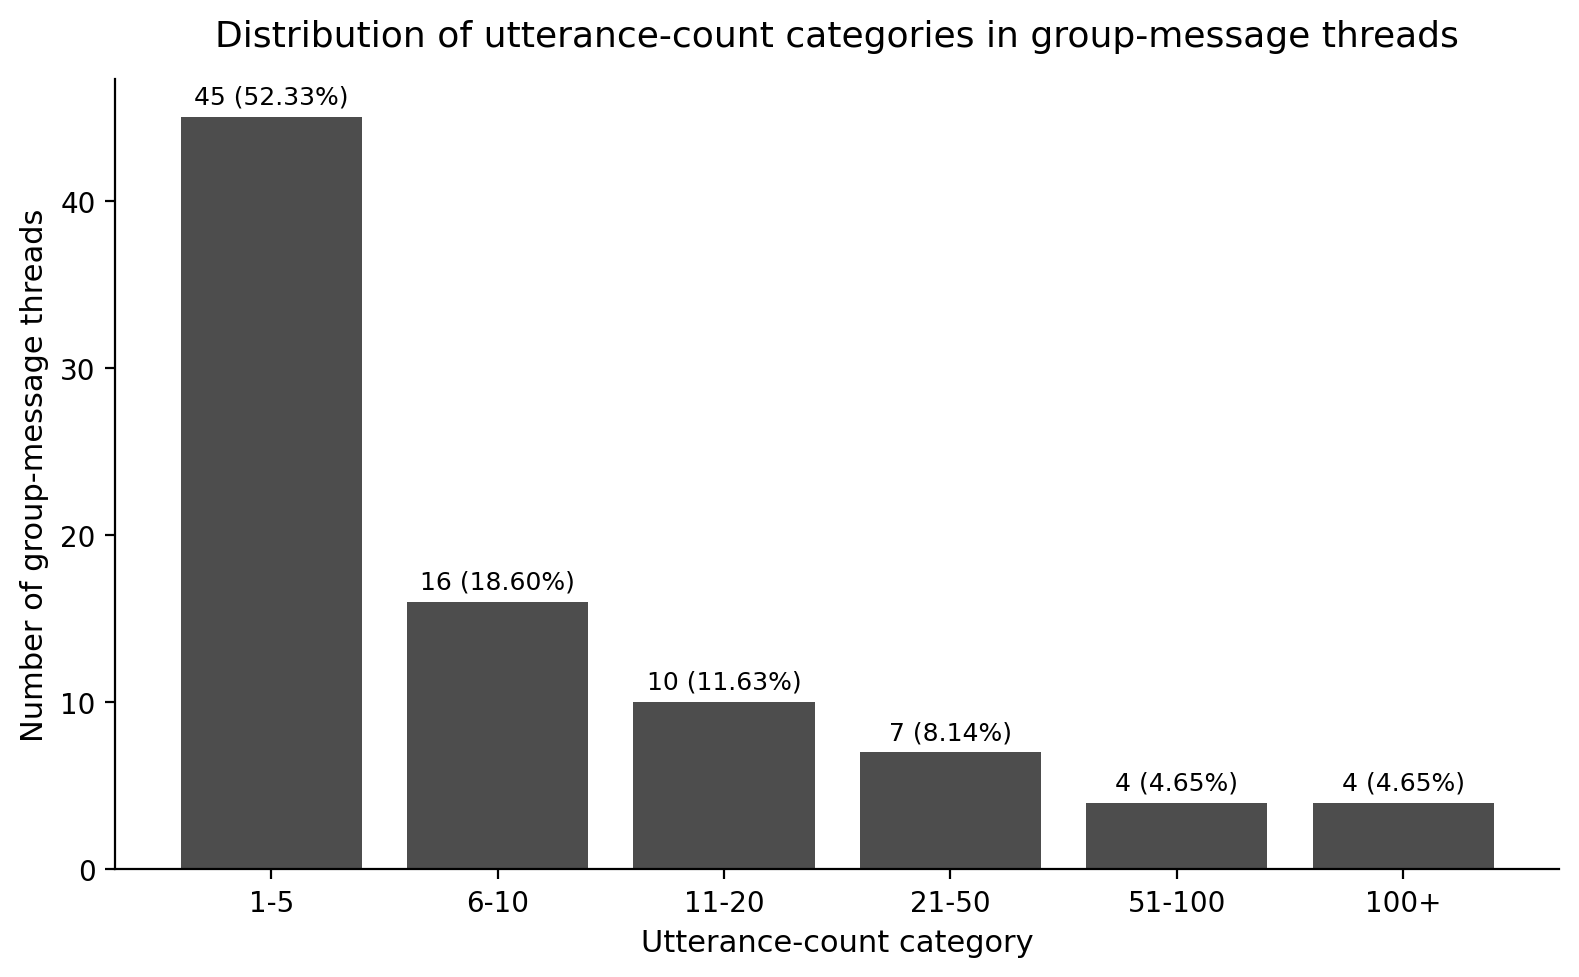

Saved PNG figure to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/figures/G_utterance_count_category_distribution_darkgrey.png

Saved SVG figure to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/figures/G_utterance_count_category_distribution_darkgrey.svg


In [131]:
# =========================
# Visualization: thread-size category distribution
# JMIR-ready dark grey version
# =========================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Dark grey bars
bar_color = "#4D4D4D"

bars = ax.bar(
    G_utterance_count_category_df["utterance_count_category"],
    G_utterance_count_category_df["number_of_group_message_threads"],
    color=bar_color
)

ax.set_title(
    "Distribution of utterance-count categories in group-message threads",
    fontsize=13,
    pad=12
)

ax.set_xlabel(
    "Utterance-count category",
    fontsize=11
)

ax.set_ylabel(
    "Number of group-message threads",
    fontsize=11
)

# Add values above bars
for bar, (_, row) in zip(bars, G_utterance_count_category_df.iterrows()):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{int(row['number_of_group_message_threads'])} "
        f"({row['percentage_of_group_message_threads']:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Cleaner scientific layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# Save figure
figure_file_png = (
    FIGURE_OUTPUT_DIR
    / "G_utterance_count_category_distribution_darkgrey.png"
)

figure_file_svg = (
    FIGURE_OUTPUT_DIR
    / "G_utterance_count_category_distribution_darkgrey.svg"
)

plt.savefig(
    figure_file_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_file_svg,
    bbox_inches="tight"
)

plt.show()

print("Saved PNG figure to:")
print(figure_file_png)

print("\nSaved SVG figure to:")
print(figure_file_svg)

---

## Abb.: utterance-count categories by message type

In [133]:
# =========================
# Harmonize direct-message utterance-count categories
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If the direct-message grouped table is not available in memory, load it
if "D_utterance_grouped_df" not in globals():
    D_utterance_grouped_file = (
        RESULT_TABLE_DIR
        / "D_utterance_count_grouped_distribution.xlsx"
    )
    
    D_utterance_grouped_df = pd.read_excel(
        D_utterance_grouped_file,
        engine="openpyxl"
    )

# Define common category order
common_utterance_categories = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    ">100"
]

# Map the finer direct-message categories to common categories
direct_category_mapping = {
    "1": "1-5",
    "2": "1-5",
    "3-5": "1-5",
    "6-10": "6-10",
    "11-20": "11-20",
    "21-50": "21-50",
    "51-100": "51-100",
    ">100": ">100",
    "100+": ">100"
}

D_direct_common_df = D_utterance_grouped_df.copy()

D_direct_common_df["utterance_count_category"] = (
    D_direct_common_df["utterance_count_group"]
    .astype(str)
    .map(direct_category_mapping)
)

D_direct_common_df = (
    D_direct_common_df
    .groupby("utterance_count_category", as_index=False)
    .agg(
        number_of_threads=("number_of_conversations", "sum")
    )
)

D_direct_common_df["message_type"] = "Direct messages"

D_direct_common_df["percentage_of_threads"] = (
    D_direct_common_df["number_of_threads"]
    / D_direct_common_df["number_of_threads"].sum()
    * 100
)

D_direct_common_df = (
    D_direct_common_df
    .set_index("utterance_count_category")
    .reindex(common_utterance_categories, fill_value=0)
    .reset_index()
)

display(D_direct_common_df)

,utterance_count_category,number_of_threads,message_type,percentage_of_threads
0,1-5,153,Direct messages,52.218430
1,6-10,49,Direct messages,16.723549
2,11-20,32,Direct messages,10.921502
3,21-50,36,Direct messages,12.286689
4,51-100,15,Direct messages,5.119454
5,>100,8,Direct messages,2.730375


In [134]:
# =========================
# Harmonize group-message utterance-count categories
# =========================

G_group_common_df = G_utterance_count_category_df.copy()

# Standardize category label: 100+ -> >100
G_group_common_df["utterance_count_category"] = (
    G_group_common_df["utterance_count_category"]
    .astype(str)
    .replace({"100+": ">100"})
)

G_group_common_df = G_group_common_df.rename(
    columns={
        "number_of_group_message_threads": "number_of_threads"
    }
)

G_group_common_df = G_group_common_df[
    [
        "utterance_count_category",
        "number_of_threads"
    ]
].copy()

G_group_common_df["message_type"] = "Group messages"

G_group_common_df["percentage_of_threads"] = (
    G_group_common_df["number_of_threads"]
    / G_group_common_df["number_of_threads"].sum()
    * 100
)

G_group_common_df = (
    G_group_common_df
    .set_index("utterance_count_category")
    .reindex(common_utterance_categories, fill_value=0)
    .reset_index()
)

display(G_group_common_df)

,utterance_count_category,number_of_threads,message_type,percentage_of_threads
0,1-5,45,Group messages,52.325581
1,6-10,16,Group messages,18.604651
2,11-20,10,Group messages,11.627907
3,21-50,7,Group messages,8.139535
4,51-100,4,Group messages,4.651163
5,>100,4,Group messages,4.651163


In [135]:
# =========================
# Create combined direct/group utterance-count distribution table
# =========================

combined_utterance_category_distribution_df = pd.concat(
    [
        D_direct_common_df,
        G_group_common_df
    ],
    ignore_index=True
)

combined_utterance_category_distribution_df["percentage_of_threads"] = (
    combined_utterance_category_distribution_df["percentage_of_threads"]
    .round(2)
)

display(combined_utterance_category_distribution_df)

# Save combined table
combined_distribution_file = (
    RESULT_TABLE_DIR
    / "combined_direct_group_utterance_count_category_distribution.xlsx"
)

combined_utterance_category_distribution_df.to_excel(
    combined_distribution_file,
    index=False,
    engine="openpyxl"
)

print("Saved combined distribution table to:")
print(combined_distribution_file)

,utterance_count_category,number_of_threads,message_type,percentage_of_threads
0,1-5,153,Direct messages,52.22
1,6-10,49,Direct messages,16.72
2,11-20,32,Direct messages,10.92
3,21-50,36,Direct messages,12.29
4,51-100,15,Direct messages,5.12
5,>100,8,Direct messages,2.73
6,1-5,45,Group messages,52.33
7,6-10,16,Group messages,18.60
8,11-20,10,Group messages,11.63
9,21-50,7,Group messages,8.14


Saved combined distribution table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/combined_direct_group_utterance_count_category_distribution.xlsx


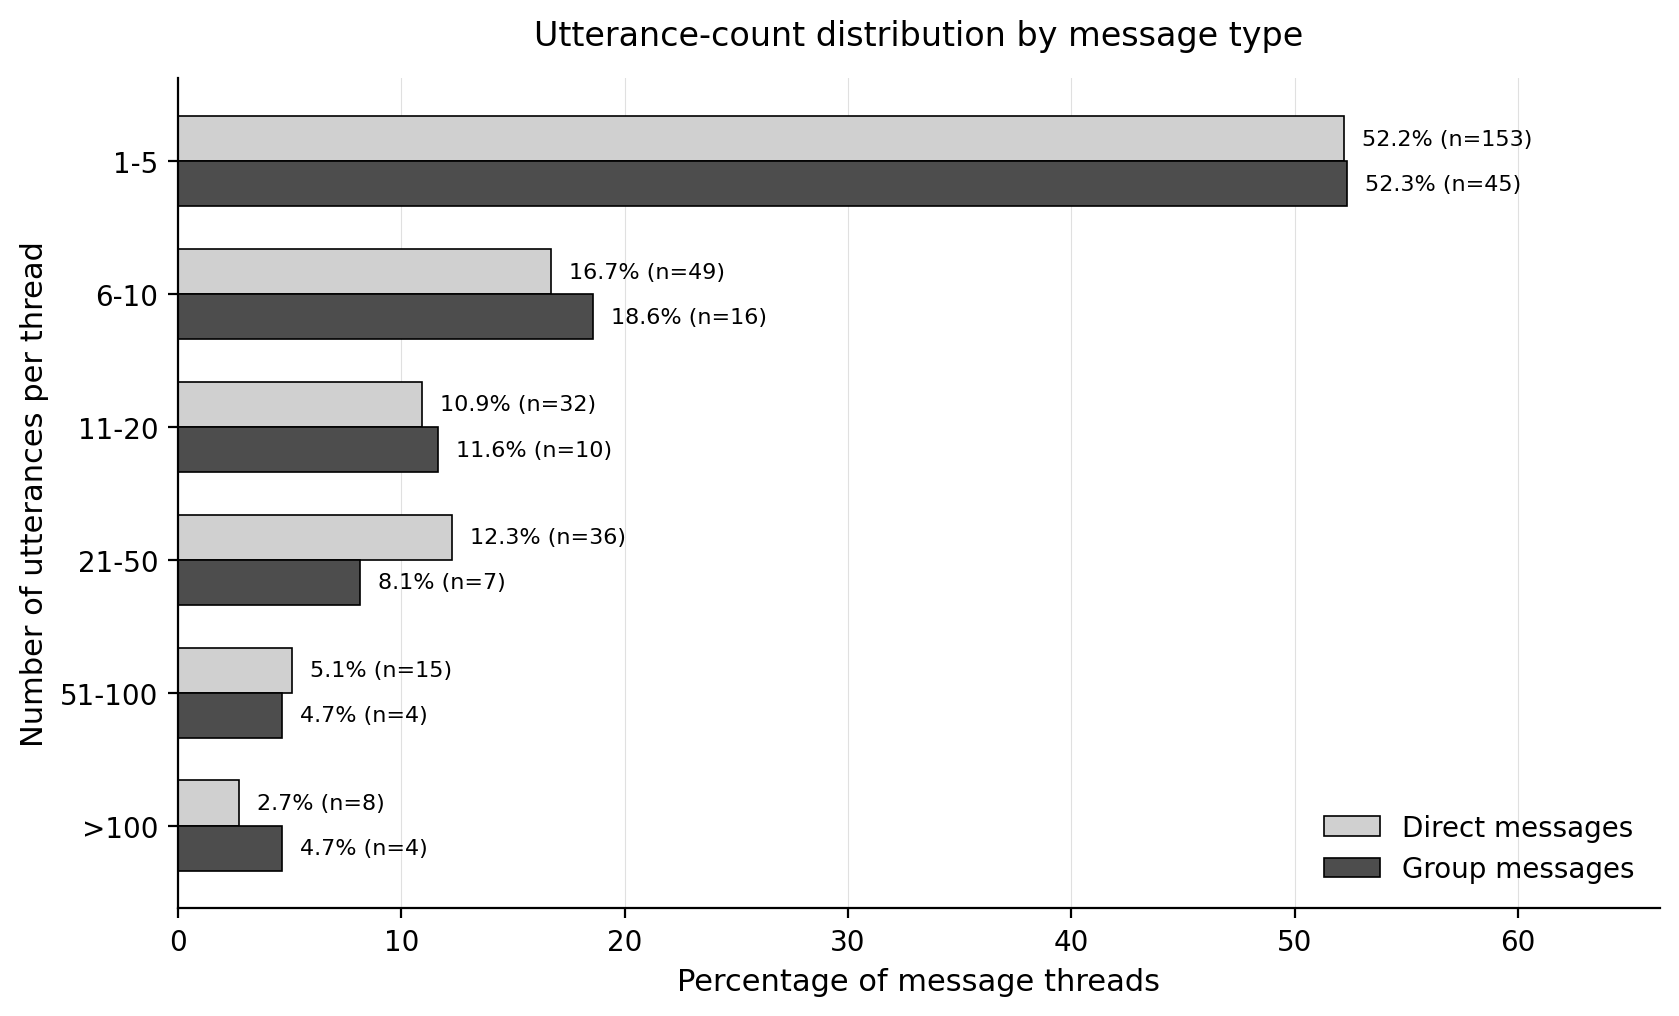

Saved PNG figure to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/figures/combined_direct_group_utterance_count_categories_horizontal_jmir.png

Saved SVG figure to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/figures/combined_direct_group_utterance_count_categories_horizontal_jmir.svg


In [138]:
# =========================
# JMIR-ready horizontal combined figure:
# utterance-count categories by message type
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Define order of categories
common_utterance_categories = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    ">100"
]

# Pivot for plotting percentages
plot_percentage_df = (
    combined_utterance_category_distribution_df
    .pivot(
        index="utterance_count_category",
        columns="message_type",
        values="percentage_of_threads"
    )
    .reindex(common_utterance_categories)
)

# Pivot for count labels
plot_count_df = (
    combined_utterance_category_distribution_df
    .pivot(
        index="utterance_count_category",
        columns="message_type",
        values="number_of_threads"
    )
    .reindex(common_utterance_categories)
)

# Figure
fig, ax = plt.subplots(figsize=(8.5, 5.2))

y = np.arange(len(common_utterance_categories))
bar_height = 0.34

# JMIR-friendly grayscale colors
direct_color = "#D0D0D0"
group_color = "#4D4D4D"

bars_direct = ax.barh(
    y - bar_height / 2,
    plot_percentage_df["Direct messages"],
    height=bar_height,
    label="Direct messages",
    color=direct_color,
    edgecolor="black",
    linewidth=0.6
)

bars_group = ax.barh(
    y + bar_height / 2,
    plot_percentage_df["Group messages"],
    height=bar_height,
    label="Group messages",
    color=group_color,
    edgecolor="black",
    linewidth=0.6
)

# Add labels to the right of bars
for i, bar in enumerate(bars_direct):
    percentage = plot_percentage_df["Direct messages"].iloc[i]
    count = int(plot_count_df["Direct messages"].iloc[i])

    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}% (n={count})",
        ha="left",
        va="center",
        fontsize=8
    )

for i, bar in enumerate(bars_group):
    percentage = plot_percentage_df["Group messages"].iloc[i]
    count = int(plot_count_df["Group messages"].iloc[i])

    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}% (n={count})",
        ha="left",
        va="center",
        fontsize=8
    )

# Axis labels
ax.set_xlabel(
    "Percentage of message threads",
    fontsize=11
)

ax.set_ylabel(
    "Number of utterances per thread",
    fontsize=11
)

# Optional concise title for notebook version
ax.set_title(
    "Utterance-count distribution by message type",
    fontsize=12,
    pad=12
)

ax.set_yticks(y)
ax.set_yticklabels(common_utterance_categories, fontsize=10)

# Put smallest category at the top
ax.invert_yaxis()

# Grid lines
ax.xaxis.grid(
    True,
    linestyle="-",
    linewidth=0.4,
    color="#E0E0E0"
)

ax.set_axisbelow(True)

# Cleaner layout
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=10)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right"
)

# Give enough horizontal space for labels
ax.set_xlim(
    0,
    max(plot_percentage_df.max()) + 14
)

plt.tight_layout()

# Save figure
combined_figure_png = (
    FIGURE_OUTPUT_DIR
    / "combined_direct_group_utterance_count_categories_horizontal_jmir.png"
)

combined_figure_svg = (
    FIGURE_OUTPUT_DIR
    / "combined_direct_group_utterance_count_categories_horizontal_jmir.svg"
)

plt.savefig(
    combined_figure_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    combined_figure_svg,
    bbox_inches="tight"
)

plt.show()

print("Saved PNG figure to:")
print(combined_figure_png)

print("\nSaved SVG figure to:")
print(combined_figure_svg)

The distribution of utterance-count categories was highly similar for direct-message and group-message threads. In both corpora, slightly more than half of all threads contained only 1–5 utterances (direct messages: 52.2%, n = 153; group messages: 52.3%, n = 45). When including threads with up to 10 utterances, this proportion increased to 68.9% for direct messages and 70.9% for group messages.

This pattern suggests that a substantial proportion of users may have engaged with the platform only briefly or experimentally, without developing sustained communication activity over time. Longer threads were less frequent in both message types. Threads with 21–50 utterances were somewhat more common in the direct-message corpus (12.3%, n = 36) than in the group-message corpus (8.1%, n = 7). Conversely, very long threads with more than 100 utterances were slightly more frequent among group messages (4.7%, n = 4) than among direct messages (2.7%, n = 8).

Overall, both direct-message and group-message communication showed a strongly right-skewed distribution. Most threads contained only a small number of utterances, whereas sustained communication activity was concentrated in a comparatively small subset of threads. This may indicate that the platform was used intensively by a limited group of users, while many users tested the system only briefly or did not transition into regular use.


---

## Word and sentence counts per utterance

This section calculates word and sentence counts for each utterance in the group-message corpus. The utterance-level statistics are then summarized by utterance-count category of the corresponding group-message thread.

Sentence counts should be interpreted cautiously, because chat messages are often short, elliptical, and may not follow standard punctuation conventions.


In [ ]:
# =========================
# Word and sentence counts per utterance
# =========================

import pandas as pd
import spacy

# Load German spaCy model
nlp = spacy.load("de_core_news_sm")

# Define utterance-count categories
utterance_count_bins = [0, 5, 10, 20, 50, 100, float("inf")]

utterance_count_labels = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

# Ensure that each group-message thread has an utterance-count category
G_frequency_df["utterance_count_category"] = pd.cut(
    G_frequency_df["number_of_utterances"],
    bins=utterance_count_bins,
    labels=utterance_count_labels,
    right=True
)

# Create lookup: conversation_id -> utterance-count category
conversation_category_lookup = dict(
    zip(
        G_frequency_df["conversation_id"],
        G_frequency_df["utterance_count_category"]
    )
)

# Initialize list for utterance-level statistics
utterance_stat_records = []

# Iterate over all conversations in the group-message corpus
for conversation in G_corpus.iter_conversations():

    conversation_id = conversation.id
    utterance_count_category = conversation_category_lookup.get(conversation_id)

    # Iterate over all utterances in the conversation
    for utterance in conversation.iter_utterances():

        doc = nlp(utterance.text)

        # Count words excluding punctuation and whitespace
        number_of_words = sum(
            1 for token in doc
            if not token.is_punct and not token.is_space
        )

        # Count sentences detected by spaCy
        number_of_sentences = len(list(doc.sents))

        # Calculate words per sentence
        words_per_sentence = (
            number_of_words / number_of_sentences
            if number_of_sentences > 0
            else 0
        )

        utterance_stat_records.append({
            "conversation_id": conversation_id,
            "utterance_id": utterance.id,
            "utterance_count_category": utterance_count_category,
            "number_of_words": number_of_words,
            "number_of_sentences": number_of_sentences,
            "words_per_sentence": words_per_sentence
        })

# Create utterance-level statistics DataFrame
G_utterance_stats_df = pd.DataFrame(utterance_stat_records)

display(G_utterance_stats_df.head())

print("Number of utterances with calculated statistics:")
print(G_utterance_stats_df.shape[0])



### Summarize word and sentence statistics by thread-size category

In [139]:
# =========================
# Summarize word and sentence statistics by category
# =========================

G_utterance_stats_by_category_df = (
    G_utterance_stats_df
    .groupby("utterance_count_category", observed=False)
    .agg(
        number_of_utterances=("utterance_id", "count"),
        mean_words_per_utterance=("number_of_words", "mean"),
        median_words_per_utterance=("number_of_words", "median"),
        mean_sentences_per_utterance=("number_of_sentences", "mean"),
        median_sentences_per_utterance=("number_of_sentences", "median"),
        mean_words_per_sentence=("words_per_sentence", "mean"),
        median_words_per_sentence=("words_per_sentence", "median")
    )
    .reset_index()
)

# Round numeric columns for reporting
numeric_columns = [
    "mean_words_per_utterance",
    "median_words_per_utterance",
    "mean_sentences_per_utterance",
    "median_sentences_per_utterance",
    "mean_words_per_sentence",
    "median_words_per_sentence"
]

G_utterance_stats_by_category_df[numeric_columns] = (
    G_utterance_stats_by_category_df[numeric_columns]
    .round(2)
)

display(G_utterance_stats_by_category_df)



,utterance_count_category,number_of_utterances,mean_words_per_utterance,median_words_per_utterance,mean_sentences_per_utterance,median_sentences_per_utterance,mean_words_per_sentence,median_words_per_sentence
0,1-5,123,30.27,17.0,3.68,3.0,7.28,6.00
1,100+,1621,50.02,27.0,5.34,3.0,9.74,8.25
2,11-20,151,28.50,18.0,6.18,3.0,7.61,6.00
3,21-50,234,20.94,10.5,2.90,2.0,6.84,5.76
4,51-100,298,32.33,21.0,5.35,3.0,7.33,6.17
5,6-10,120,32.41,17.5,3.90,3.0,7.55,6.40


In [142]:
# =========================
# Reorder category-level word and sentence statistics
# =========================

category_order = [
    "1-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

G_utterance_stats_by_category_df["utterance_count_category"] = pd.Categorical(
    G_utterance_stats_by_category_df["utterance_count_category"],
    categories=category_order,
    ordered=True
)

G_utterance_stats_by_category_df = (
    G_utterance_stats_by_category_df
    .sort_values("utterance_count_category")
    .reset_index(drop=True)
)

display(G_utterance_stats_by_category_df)

# Save reordered table
G_utterance_stats_by_category_df.to_excel(
    RESULT_TABLE_DIR / "G_utterance_word_sentence_statistics_by_category.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved reordered category-level word and sentence statistics to:")
print(RESULT_TABLE_DIR / "G_utterance_word_sentence_statistics_by_category.xlsx")

,utterance_count_category,number_of_utterances,mean_words_per_utterance,median_words_per_utterance,mean_sentences_per_utterance,median_sentences_per_utterance,mean_words_per_sentence,median_words_per_sentence
0,1-5,123,30.27,17.0,3.68,3.0,7.28,6.00
1,6-10,120,32.41,17.5,3.90,3.0,7.55,6.40
2,11-20,151,28.50,18.0,6.18,3.0,7.61,6.00
3,21-50,234,20.94,10.5,2.90,2.0,6.84,5.76
4,51-100,298,32.33,21.0,5.35,3.0,7.33,6.17
5,100+,1621,50.02,27.0,5.34,3.0,9.74,8.25


Saved reordered category-level word and sentence statistics to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_word_sentence_statistics_by_category.xlsx


### Print readable summary

In [143]:
# =========================
# Print readable summary
# =========================

for _, row in G_utterance_stats_by_category_df.iterrows():
    print(
        f"Category {row['utterance_count_category']}: "
        f"mean words per utterance = {row['mean_words_per_utterance']:.2f}, "
        f"mean sentences per utterance = {row['mean_sentences_per_utterance']:.2f}, "
        f"mean words per sentence = {row['mean_words_per_sentence']:.2f}"
    )


Category 1-5: mean words per utterance = 30.27, mean sentences per utterance = 3.68, mean words per sentence = 7.28
Category 6-10: mean words per utterance = 32.41, mean sentences per utterance = 3.90, mean words per sentence = 7.55
Category 11-20: mean words per utterance = 28.50, mean sentences per utterance = 6.18, mean words per sentence = 7.61
Category 21-50: mean words per utterance = 20.94, mean sentences per utterance = 2.90, mean words per sentence = 6.84
Category 51-100: mean words per utterance = 32.33, mean sentences per utterance = 5.35, mean words per sentence = 7.33
Category 100+: mean words per utterance = 50.02, mean sentences per utterance = 5.34, mean words per sentence = 9.74


### Save word and sentence statistics

In [144]:
# =========================
# Save word and sentence statistics
# =========================

G_utterance_stats_file = (
    RESULT_TABLE_DIR
    / "G_utterance_level_word_sentence_statistics.xlsx"
)

G_utterance_stats_by_category_file = (
    RESULT_TABLE_DIR
    / "G_utterance_word_sentence_statistics_by_category.xlsx"
)

G_utterance_stats_df.to_excel(
    G_utterance_stats_file,
    index=False,
    engine="openpyxl"
)

G_utterance_stats_by_category_df.to_excel(
    G_utterance_stats_by_category_file,
    index=False,
    engine="openpyxl"
)

print("Saved utterance-level word and sentence statistics to:")
print(G_utterance_stats_file)

print("\nSaved category-level word and sentence statistics to:")
print(G_utterance_stats_by_category_file)


Saved utterance-level word and sentence statistics to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_level_word_sentence_statistics.xlsx

Saved category-level word and sentence statistics to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/G_utterance_word_sentence_statistics_by_category.xlsx


**Utterance-level word and sentence statistics** varied across group-message thread-size categories. The longest threads (`100+` utterances) accounted for the largest share of utterances (n = 1,621) and showed the highest mean number of words per utterance (50.02) and words per sentence (9.74). However, the median number of words per utterance in this category was substantially lower (27), indicating a skewed distribution with some particularly long utterances.

Across the remaining categories, no strictly linear pattern was observed. Mean words per utterance ranged from 20.94 in threads with 21–50 utterances to 32.41 in threads with 6–10 utterances. Sentence-based measures should be interpreted cautiously, as chat messages are often fragmented, elliptical, and may not follow standard punctuation conventions.


---

## Zeitliche Analyse

In [ ]:
import convokit
from convokit import Corpus, download
import pandas as pd

# Laden des ConvoKit Corpus
# corpus_path = arbeitsverzeichnisG
corpus = G_corpus

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
# unit='s' für Unix Zeitstempel in Sekunden
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion von Wochentag und Uhrzeit
df['weekday'] = df['timestamp'].dt.weekday
df['hour'] = df['timestamp'].dt.hour

# Gruppierung und Zählung der Nachrichten nach Wochentag und Stunde
weekday_hour_count = df.groupby(
    ['weekday', 'hour']).size().reset_index(name='count')

# Sortieren der Daten nach Häufigkeit
sorted_data = weekday_hour_count.sort_values(by='count', ascending=False)

print(sorted_data)

### Häufigkeit der Nachrichten über die Stunden des Tages

In [ ]:
import numpy as np
import convokit
from convokit import Corpus, download
import pandas as pd
import matplotlib.pyplot as plt

# Laden des ConvoKit Corpus
# Bitte stellen Sie sicher, dass 'arbeitsverzeichnisG' korrekt definiert ist.
corpus_path = arbeitsverzeichnisG
corpus = G_corpus

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion der Stunde
df['hour'] = df['timestamp'].dt.hour

# Gruppierung und Zählung der Nachrichten nach Stunde
hour_count = df.groupby('hour').size().reset_index(name='count')

# Berechnung der relativen Häufigkeiten
total_messages = hour_count['count'].sum()
hour_count['relative_frequency'] = (
    hour_count['count'] / total_messages) * 100  # in Prozent

# Visualisierung der Daten als horizontales Balkendiagramm
plt.figure(figsize=(14, 8))
# Pastellfarbene Anpassung der Balkenfarbe
pastel_salmon = ['#fba69a']  # Werte für eine pastellere Lachsfarbe
bars = plt.barh(hour_count['hour'], hour_count['count'], color=pastel_salmon)

# Hinzufügen der Datenwertbeschriftungen zu jedem Balken
for bar in bars:
    xval = bar.get_width()
    rel_freq = hour_count.loc[hour_count['hour'] == bar.get_y(
    ) + bar.get_height()/2, 'relative_frequency'].values[0]
    # Begrenzung der x-Koordinate des Textes, um innerhalb der Grenzen der Grafik zu bleiben
    max_x = max(hour_count['count']) * 1.05  # 5% größer als der größte Balken
    if xval > max_x:
        plt.text(max_x, bar.get_y() + bar.get_height()/2,
                 f'{int(xval)} ({rel_freq:.2f}%)', va='center', fontsize=8, ha='left')
    else:
        plt.text(xval, bar.get_y() + bar.get_height()/2,
                 f'{int(xval)} ({rel_freq:.2f}%)', va='center', fontsize=8, ha='left')

plt.title('Nachrichtenhäufigkeit (Gruppennachrichten) nach Stunde des Tages')
plt.ylabel('Stunde des Tages')
plt.xlabel('Anzahl der Nachrichten')

# Anpassung der Y-Achsen-Labels auf das gewünschte Zeitformat
hour_labels = [f"{hour} - {hour+1} Uhr" for hour in range(24)]
plt.yticks(range(24), hour_labels, fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Y-Achse umdrehen
plt.gca().invert_yaxis()

# Setzen der Grenzen der X-Achse auf 450 Nachrichten
plt.xlim(0, 450)


# Speichert das Bild in hoher Auflösung
plt.savefig("Abb/Gr_HäuStd.png", dpi=300)

plt.show()

In [ ]:
import numpy as np
import convokit
from convokit import Corpus, download
import pandas as pd

# Laden des ConvoKit Corpus
# Bitte stellen Sie sicher, dass 'arbeitsverzeichnisG' korrekt definiert ist.
corpus_path = arbeitsverzeichnisG
corpus = Corpus(filename=corpus_path)

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
# unit='s' für Unix Zeitstempel in Sekunden
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion des Wochentags
df['weekday'] = df['timestamp'].dt.dayofweek  # Montag=0, Sonntag=6

# Gruppierung und Zählung der Nachrichten nach Wochentag
weekday_count = df.groupby('weekday').size().reset_index(name='count')

# Prüfung auf Daten in allen Wochentagen
if weekday_count['weekday'].nunique() != 7:
    missing_days = set(range(7)) - set(weekday_count['weekday'])
    for day in missing_days:
        # Füge fehlende Tage mit 0 Nachrichten hinzu
        weekday_count = weekday_count.append(
            {'weekday': day, 'count': 0}, ignore_index=True)

# Sortieren des DataFrames nach Wochentagen
weekday_count = weekday_count.sort_values('weekday')

# Zuordnung der Wochentage zu den Nummern
weekday_labels = ['Montag', 'Dienstag', 'Mittwoch',
                  'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']
weekday_count['weekday'] = weekday_count['weekday'].map(
    lambda x: weekday_labels[x])

# Ausgabe des fertigen DataFrames
print(weekday_count)

### Visualisierung Anzahl der Nachrichten pro Wochentag

In [ ]:
import matplotlib.pyplot as plt

# Angenommen, 'weekday_count' ist der DataFrame, der bereits die Nachrichtenzahlen pro Wochentag enthält
weekday_labels = ['Montag', 'Dienstag', 'Mittwoch',
                  'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

pastel_salmon = ['#fba69a']  # Werte für eine pastellere Lachsfarbe


# Visualisierung der Daten
plt.figure(figsize=(10, 6))
bars = plt.bar(weekday_count['weekday'],
               weekday_count['count'], color= pastel_salmon)

plt.xlabel('Wochentag')
plt.ylabel('Anzahl der Nachrichten')
plt.title('Anzahl der Nachrichten pro Wochentag (Gruppennachrichten)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7
         )

# Berechnung der Gesamtanzahl der Nachrichten zur Bestimmung der relativen Häufigkeiten
total_messages = weekday_count['count'].sum()

# Bestimmen der maximalen Höhe eines Balkens, um die y-Achsen-Grenzen festzulegen
max_height = max(weekday_count['count'])
# Erweitern des y-Achsen-Limits um 15%
plt.ylim(0, max_height + 0.15 * max_height)

# Hinzufügen der Datenwerte und relativen Häufigkeiten über die Balken
for bar in bars:
    yval = bar.get_height()  # Höhe des Balkens (Anzahl der Nachrichten)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001 * total_messages,
             f'{yval}\n({yval/total_messages:.2%})', ha='center', va='bottom')

plt.tight_layout()  # Optimiert den Layout der Darstellung

# Speichert das Bild in hoher Auflösung
plt.savefig("Abb/Dir_NachTagesp.png", dpi=300)


plt.show()

### Ausgabe des kompletten Nachrichtentextes in Rohform und schreiben in die Datei: *G_corpus.txt*

In [ ]:
# Iterieren  über alle Utterance-Objekte im Corpus und Texte ausgeben
for utt in G_corpus.iter_utterances():
    print(utt.text)

In [62]:
# Ergebnis in  Datei schreiben
# Öffnen der Datei im Schreibmodus
with open("G_corpus_roh.txt", "w", encoding="utf-8") as file:
    # Iterieren über alle Utterance-Objekte im Corpus und schreiben der Text in die Datei
    for utt in G_corpus.iter_utterances():
        file.write(utt.text + "\n")

In [ ]:
%pip install plotly --upgrade
%pip install emoji --upgrade

## Emoji Analyse

In [ ]:
from convokit import Corpus, download
import re
from collections import Counter
import matplotlib.pyplot as plt

corpus_path = arbeitsverzeichnisG

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

# Regex zum Finden der Emoji-Patterns
emoji_pattern = re.compile(r":\w+:")

# Funktion, um Emojis aus Text zu extrahieren


def extract_emojis(text):
    return emoji_pattern.findall(text)


# Extraktion der Emojis aus jeder Äußerung im Corpus
all_emojis = []
for utterance in corpus.iter_utterances():
    utterance_emojis = extract_emojis(utterance.text)
    all_emojis.extend(utterance_emojis)

# Zählen der Häufigkeiten der Emojis
emoji_counts = Counter(all_emojis)

# Anzeigen der am häufigsten vorkommenden Emojis
print(emoji_counts.most_common(200))

In [ ]:
import pandas as pd
import emoji
from collections import Counter
import re
from convokit import Corpus

corpus_path = arbeitsverzeichnisG

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

# Regex zum Finden der Emoji-Patterns
emoji_pattern = re.compile(r":\w+:")

# Funktion, um Emojis aus Text zu extrahieren


def extract_emojis(text):
    return emoji_pattern.findall(text)


# Extraktion der Emojis aus jeder Äußerung im Corpus und Berechnung der Frequenz pro Äußerung
all_emojis = []
utterance_frequencies = []

for utterance in corpus.iter_utterances():
    # Emojis extrahieren und zählen
    utterance_emojis = extract_emojis(utterance.text)
    all_emojis.extend(utterance_emojis)

    # Emoji-Frequenz pro Äußerung berechnen
    word_count = len(utterance.text.split())
    emoji_count = len(utterance_emojis)
    emoji_frequency = emoji_count / word_count if word_count > 0 else 0
    utterance_frequencies.append({
        'utterance_id': utterance.id,
        'emoji_count': emoji_count,
        'word_count': word_count,
        'emoji_frequency': emoji_frequency
    })

# Erstellen eines DataFrames für die Frequenz pro Äußerung
df_utterance_freq = pd.DataFrame(utterance_frequencies)

# Zählen der Häufigkeiten der Emojis im gesamten Korpus
emoji_counts = Counter(all_emojis)

# Umwandeln der Emoji-Codes in Unicode Emojis (mit dem neuen Parameter)
emoji_unicode = [emoji.emojize(e, language='alias')
                 for e in emoji_counts.keys()]

# Erstellen eines DataFrames mit Unicode, Symbol und deren Häufigkeit
df_emoji_counts = pd.DataFrame({
    'Unicode': list(emoji_counts.keys()),  # Emoji Codes (z.B. :joy:)
    'Symbol': emoji_unicode,               # Entsprechende Unicode-Emojis
    'Häufigkeit': list(emoji_counts.values())  # Häufigkeiten der Emojis
})

# Sortieren des Emoji-DataFrames nach der Häufigkeit
df_emoji_counts_sorted = df_emoji_counts.sort_values(
    by='Häufigkeit', ascending=False)

# Berechnung der durchschnittlichen Emoji-Frequenz im gesamten Korpus
total_word_count = sum(df_utterance_freq['word_count'])
total_emoji_count = sum(df_utterance_freq['emoji_count'])
average_emoji_frequency = total_emoji_count / \
    total_word_count if total_word_count > 0 else 0

# Anzeigen der Ergebnisse
print("Emoji-Häufigkeit pro Äußerung:\n", df_utterance_freq)
print("\nEmoji-Gesamthäufigkeiten im Korpus:\n", df_emoji_counts_sorted)
print(
    f"\nDurchschnittliche Emoji-Frequenz im Korpus: {average_emoji_frequency:.4f}")

In [ ]:
import emoji
from IPython.display import HTML

# Definiere ein erweitertes manuelles Mapping für problematische Emojis


def fix_emoji(emoji_code):
    # Manuelles Mapping für bekannte problematische Emojis
    emoji_mapping = {
        ":relaxed:": "😊",   # Alternativer Unicode für ":relaxed:"
        ":1:": "🥇",         # Alternativer Unicode für ":1:" (1st place medal)
        # Weitere problematische Emojis können hier hinzugefügt werden
    }
    # Überprüfen, ob das Emoji im Mapping existiert, andernfalls normal emojize
    return emoji_mapping.get(emoji_code, emoji.emojize(emoji_code, language='alias'))


# Filtern des DataFrames für Emojis mit einer Häufigkeit von mindestens 2
df_filtered = df_sorted[df_sorted['Häufigkeit'] >= 2].copy()

# Anwenden der Funktion auf die Spalte "Emoji-Darstellung" und Multiplizieren mit der Häufigkeit
df_filtered['Emoji-Darstellung'] = df_filtered.apply(
    lambda row: fix_emoji(row['Unicode']) * row['Häufigkeit'], axis=1
)

# Erstellen einer neuen Anzeige der Tabelle
df_display = df_filtered[['Häufigkeit', 'Emoji-Darstellung']].rename(columns={
    'Häufigkeit': 'Häufigkeit',
    'Emoji-Darstellung': 'Visuelle Darstellung'
})

# Zeige die Tabelle im HTML-Format (funktioniert in Notebook-Umgebungen wie Jupyter)
display(HTML(f"""
    <div style="display: flex; flex-direction: column; align-items: center; color: black; background-color: white; padding: 20px; border-radius: 10px; box-shadow: 0px 0px 10px rgba(0, 0, 0, 0.1);">
        <h3 style="color: black;">Häufigkeiten von Emojis in Gruppennachrichten (mindestens 2 Vorkommen)</h3>
        {df_display.to_html(index=False, escape=False).replace(
    '<td>', '<td style="text-align: left; color: black;">').replace('<th>', '<th style="color: black;">')}
    </div>
"""))

#### ________________________________________________

# Cleaning corpusspezifisch
1. entfernen von "< enter >"

In [63]:
corpus_path = arbeitsverzeichnisG

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

replacements1 = {
    "<enter>": "",
    "< enter>": "",
    "< enter >": "",
    "<enter > ": "",
    "enter>": "",
    " <enter> ": ""}

# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen
for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts
    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)
    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_V")

In [64]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_V"
corpus = Corpus(filename=corpus_path)


replacements1 = {
    "#": "",
    ",": "",
    ":": "",
    ";": "",
    "*": "",
    "(": "",
    ")": "",
    ".": "",
    "-": ""
}

replacements2 = {

    "to do": " Platzhalter ",
    "to do's ": " Platzhalter ",
    "to dos": " Platzhalter ",
    "todos": " Platzhalter ",
    "To Dos": " Platzhalter ",
    "To Do": " Platzhalter ",
    "To do's": " Platzhalter ",
    "To do ' s": " Platzhalter ",
    "to do's": " Platzhalter ",
    "To-Do's": " Platzhalter ",
    "Todo's": " Platzhalter ",
    "To dos": " Platzhalter ",
    " to Dos ": " Platzhalter "
}

replacements3 = {
    "keine aktiven  Platzhalter 's": "kein_Todo",
    "kein  Platzhalter": "kein_Todo",
    "keine aktiven  Platzhalter": "kein_Todo",
    "kein aktives  Platzhalter": "kein_Todo",
    "keine  Platzhalter s": "kein_Todo",
    "aktiven ToDo'skann": "kein_Todo",
    "keine akuten  Platzhalter": "kein_Todo",
    "kein aktives  Platzhalter": "kein_Todo"
}

replacements4 = {
    " Platzhalter": " Todo ",
    " Platzhalter 's ": " Todo "
}

replacements5 = {
    "Frau ": " ",
    "Fr ": " ",
    " Fr ": " ",
    "Hr ": " ",
    "Herr": " ",
    "Herrn": " "
}

replacements6 = {
    "<Nachname>": " Ersatz ",
    "<Nachname> ": " Ersatz ",
    "<Name_Abkürzung>": " Ersatz ",
    "Patient": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Pat.": " Ersatz ",
    "Pat. ": " Ersatz ",
    "Pat": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Herr < Name_Abkürzung >": " Ersatz "
}

replacements7 = {
    " Ersatz ": " PatName ",
    " Gesprächsgruppe ": " GT ",
    " kt ": "KT",
    " mt ": "MT",
}

replacements8 = {
    " > ": " ",
    "> ": " ",
    " >": " ",
    ">": " ",
    "<": " ",
    " < ": " ",
    "< ": " ",
    " <": " ",
    "@": " "
}


# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen

for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts

    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1, replacements2, replacements3, replacements4,
                         replacements5, replacements6, replacements7, replacements8]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)

    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean")

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Iterieren  über alle Utterance-Objekte im Corpus und Texte ausgeben
for utt in corpus.iter_utterances():
    print(utt.text)

In [ ]:
# Pfad zur Ausgabedatei
output_text_file = f"{arbeitsverzeichnisG}/G_corpus_clean_text.txt"

# Schreiben des Texts in die Ausgabedatei
with open(output_text_file, 'w', encoding='utf-8') as f:
    for utterance in corpus.iter_utterances():
        f.write(utterance.text + '\n')

print(f"Der Text des gereinigten Corpus wurde in '{output_text_file}' gespeichert.")

# Iterieren über alle Utterance-Objekte im Corpus und Texte mit Utterance ID ausgeben
for utt in corpus.iter_utterances():
    # print(f"Utterance ID: {utt.id}")
    print(utt.text)

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Iterieren über alle Utterance-Objekte im Corpus und Texte mit Utterance ID ausgeben
for utt in corpus.iter_utterances():
    print(f"Utterance ID: {utt.id}")
    print(f"Text: {utt.text}\n")

#### Gruppieren der Utteranes und Ausgabe von Texte de Gruppe

In [ ]:
import pandas as pd
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)


def analyze_and_export_utterances_transposed(corpus, output_file="utterances_transposed.csv"):
    # Define categories with counters and storage for utterances
    categories = {
        '1-5': {'count': 0, 'utterances': []},
        '6-10': {'count': 0, 'utterances': []},
        '11-20': {'count': 0, 'utterances': []},
        '21-50': {'count': 0, 'utterances': []},
        '51-100': {'count': 0, 'utterances': []},
        '100+': {'count': 0, 'utterances': []},
    }

    for conversation in corpus.iter_conversations():
        utterances = conversation.get_utterance_ids()
        num_utterances = len(utterances)

        # Determine category
        if num_utterances <= 5:
            category = '1-5'
        elif num_utterances <= 10:
            category = '6-10'
        elif num_utterances <= 20:
            category = '11-20'
        elif num_utterances <= 50:
            category = '21-50'
        elif num_utterances <= 100:
            category = '51-100'
        else:
            category = '100+'

        # Increment count and collect utterances
        categories[category]['count'] += 1
        if len(categories[category]['utterances']) < 10:
            texts = [corpus.get_utterance(u_id).text for u_id in utterances]
            categories[category]['utterances'].extend(
                texts[:10 - len(categories[category]['utterances'])])

    # Prepare transposed data for export
    table_data = {}
    for category, data in categories.items():
        header = f"{category}: {data['count']} Gespräche ({(
            data['count'] / sum(cat['count'] for cat in categories.values())) * 100:.2f}%)"
        table_data[header] = data['utterances']

    # Ensure all columns have the same number of rows by filling with empty strings
    max_rows = max(len(texts) for texts in table_data.values())
    for key in table_data:
        table_data[key].extend([""] * (max_rows - len(table_data[key])))

    # Convert to DataFrame and export
    df = pd.DataFrame(table_data)
    df.to_csv(output_file, index=False)
    print(f"Utterances exported to {output_file}")


# Example Usage
analyze_and_export_utterances_transposed(corpus)

In [ ]:
import pandas as pd
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

def analyze_and_export_utterances_transposed(corpus, output_file="utterances_transposed.csv"):
    # Define categories with counters and storage for utterances
    categories = {
        '1-5': {'count': 0, 'utterances': []},
        '6-10': {'count': 0, 'utterances': []},
        '11-20': {'count': 0, 'utterances': []},
        '21-50': {'count': 0, 'utterances': []},
        '51-100': {'count': 0, 'utterances': []},
        '100+': {'count': 0, 'utterances': []},
    }

    for conversation in corpus.iter_conversations():
        utterances = conversation.get_utterance_ids()
        num_utterances = len(utterances)

        # Determine category
        if num_utterances <= 5:
            category = '1-5'
        elif num_utterances <= 10:
            category = '6-10'
        elif num_utterances <= 20:
            category = '11-20'
        elif num_utterances <= 50:
            category = '21-50'
        elif num_utterances <= 100:
            category = '51-100'
        else:
            category = '100+'

        # Increment count and collect utterances
        categories[category]['count'] += 1
        if len(categories[category]['utterances']) < 10:
            texts = [corpus.get_utterance(u_id).text for u_id in utterances]
            categories[category]['utterances'].extend(
                texts[:10 - len(categories[category]['utterances'])])

    # Prepare transposed data for export
    table_data = {}
    for category, data in categories.items():
        header = f"{category}: {data['count']} Gespräche ({(data['count'] / sum(cat['count'] for cat in categories.values())) * 100:.2f}%)"
        table_data[header] = data['utterances']

    # Ensure all columns have the same number of rows by filling with empty strings
    max_rows = max(len(texts) for texts in table_data.values())
    for key in table_data:
        table_data[key].extend([""] * (max_rows - len(table_data[key])))

    # Convert to DataFrame and export
    df = pd.DataFrame(table_data)
    df.to_csv(output_file, index=False)
    print(f"Utterances exported to {output_file}")


# Example Usage
analyze_and_export_utterances_transposed(corpus)



## Sentimentanalysis für Texte in deutscher Sprache

VADER basiert rein auf Wortgewichtung , ignoriert  mögliche Tonalitäts- oder Kontextunterschiede.

### Vader

In [ ]:
!pip install vaderSentiment

In [ ]:
from convokit import Corpus
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

def analyze_sentiment_distribution_vader(corpus, output_file="sentiment_analysis_german_vader.csv"):
    # Initialize VADER sentiment analyzer
    analyzer = SentimentIntensityAnalyzer()

    # Load German lexicon for better results
    analyzer.lexicon.update({
        "gut": 2.0, "schlecht": -2.0, "fantastisch": 3.0, "furchtbar": -3.0, "traurig": -2.0, "glücklich": 2.0
    })

    # Define sentiment categories
    sentiment_categories = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
    utterance_sentiments = []

    for conversation in corpus.iter_conversations():
        for utterance_id in conversation.get_utterance_ids():
            utterance = corpus.get_utterance(utterance_id)
            text = utterance.text

            # Compute sentiment scores
            sentiment_scores = analyzer.polarity_scores(text)
            compound = sentiment_scores['compound']

            # Categorize sentiment
            if compound > 0.05:
                sentiment_category = 'Positive'
                sentiment_categories['Positive'] += 1
            elif compound < -0.05:
                sentiment_category = 'Negative'
                sentiment_categories['Negative'] += 1
            else:
                sentiment_category = 'Neutral'
                sentiment_categories['Neutral'] += 1

            # Store sentiment and text for export
            utterance_sentiments.append({
                'Conversation ID': conversation.id,
                'Utterance ID': utterance_id,
                'Text': text,
                'Compound': compound,
                'Sentiment': sentiment_category
            })

    # Display sentiment distribution
    total_utterances = sum(sentiment_categories.values())
    print("\nSentiment Distribution:")
    for category, count in sentiment_categories.items():
        percent = (count / total_utterances) * \
            100 if total_utterances > 0 else 0
        print(f"{category}: {count} utterances ({percent:.2f}%)")

    # Export utterances with sentiment analysis to a CSV file
    df = pd.DataFrame(utterance_sentiments)
    df.to_csv(output_file, index=False)
    print(f"Sentiment analysis results exported to {output_file}")


# Example usage
analyze_sentiment_distribution_vader(corpus)

#### Visualisierung Sentement (Vader)

Sentiment mit Transformers

In [ ]:
!pip install transformers

In [ ]:
from convokit import Corpus
from transformers import pipeline
import pandas as pd

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)


def analyze_sentiment_distribution_transformers(corpus, output_file="sentiment_analysis_transformers.csv"):
    # Load sentiment analysis pipeline
    sentiment_pipeline = pipeline(
        "sentiment-analysis", model="oliverguhr/german-sentiment-bert")

    # Define sentiment categories
    sentiment_categories = {'positive': 0, 'neutral': 0, 'negative': 0}
    utterance_sentiments = []

    for conversation in corpus.iter_conversations():
        for utterance_id in conversation.get_utterance_ids():
            utterance = corpus.get_utterance(utterance_id)
            text = utterance.text

            # Get sentiment prediction
            # Limit input to 512 tokens
            result = sentiment_pipeline(text[:512])
            # Convert to lowercase for matching
            sentiment_category = result[0]['label'].lower()

            # Check if sentiment_category is valid
            if sentiment_category in sentiment_categories:
                sentiment_categories[sentiment_category] += 1
            else:
                print(f"Warning: Unexpected sentiment label '{sentiment_category}'")

            # Store sentiment and text for export
            utterance_sentiments.append({
                'Conversation ID': conversation.id,
                'Utterance ID': utterance_id,
                'Text': text,
                'Sentiment': sentiment_category
            })

    # Display sentiment distribution
    total_utterances = sum(sentiment_categories.values())
    print("\nSentiment Distribution:")
    for category, count in sentiment_categories.items():
        percent = (count / total_utterances) * \
            100 if total_utterances > 0 else 0
        print(f"{category.capitalize()}: {count} utterances ({percent:.2f}%)")

    # Export utterances with sentiment analysis to a CSV file
    df = pd.DataFrame(utterance_sentiments)
    df.to_csv(output_file, index=False)
    print(f"Sentiment analysis results exported to {output_file}")


# Example usage
analyze_sentiment_distribution_transformers(corpus)

Visualtisieung Transformer Sentiment

In [ ]:
import matplotlib.pyplot as plt


def visualize_transformer_sentiment(sentiment_counts):
    """
    Visualize sentiment distribution for Transformer-based analysis using a bar chart.

    Args:
        sentiment_counts (dict): A dictionary with sentiment categories as keys and counts as values.
    """
    # Categories and values for the bar chart
    categories = list(sentiment_counts.keys())
    values = list(sentiment_counts.values())

    # Plotting the bar chart
    plt.figure(figsize=(8, 5))
    plt.bar(categories, values, color=['green', 'grey', 'red'])
    plt.title("Sentiment Distribution (Transformer)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


# Example usage with Transformer sentiment results
sentiment_counts = {'positive': 373, 'neutral': 1151, 'negative': 1151}
visualize_transformer_sentiment(sentiment_counts)

In [ ]:
def compare_sentiment_distributions(sentiment_counts_vader, sentiment_counts_transformer):
    categories = list(sentiment_counts_vader.keys())
    values_vader = list(sentiment_counts_vader.values())
    values_transformer = list(sentiment_counts_transformer.values())

    x = range(len(categories))  # Positions for bars

    plt.figure(figsize=(10, 6))
    plt.bar(x, values_vader, width=0.4, label='VADER',
            color='blue', align='center')
    plt.bar([p + 0.4 for p in x], values_transformer, width=0.4,
            label='Transformer', color='orange', align='center')
    plt.xticks([p + 0.2 for p in x], categories)
    plt.title("Sentiment Distribution Comparison")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# Example counts
sentiment_counts_vader = {'Positive': 244, 'Neutral': 1421, 'Negative': 918}
sentiment_counts_transformer = {'Positive': 373, 'Neutral': 1059, 'Negative': 1151}
compare_sentiment_distributions(
    sentiment_counts_vader, sentiment_counts_transformer)

### Analyse mit Roberta Model für Twitter auf Deutsch optimiert "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned"

In [ ]:
from convokit import Corpus
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
import matplotlib.pyplot as plt

# Laden des Transformers-Modells
tokenizer = AutoTokenizer.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")
model = AutoModelForSequenceClassification.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")


def extract_texts_from_corpus(corpus):
    """
    Extrahiert Texte aus einem Convokit Corpus.

    Args:
        corpus (Corpus): Der Convokit Corpus.

    Returns:
        list: Eine Liste mit den Texten aller Utterances im Corpus.
    """
    texts = []
    for utterance in corpus.iter_utterances():
        texts.append(utterance.text)
    return texts


def analyze_sentiment_with_roberta_and_export(texts, output_file="sentiment_analysis.csv"):
    """
    Analysiert Sentiments mit Roberta und exportiert Ergebnisse als CSV.

    Args:
        texts (list): Eine Liste von Texten.
        output_file (str): Der Dateiname für die CSV-Ausgabe.

    Returns:
        dict: Sentiment counts für positive, neutrale und negative Texte.
    """
    # Sentiment-Analyse initialisieren
    sentiment_pipeline = pipeline(
        "sentiment-analysis", model=model, tokenizer=tokenizer)

    # Kategorien und Zähler
    sentiment_counts = {"positive": 0, "neutral": 0, "negative": 0}
    results = []

    for text in texts:
        result = sentiment_pipeline(text[:512])  # Token-Limit beachten
        label = result[0]["label"].lower()
        score = result[0]["score"]

        # Sentiment-Ergebnisse speichern
        results.append({
            "Text": text,
            "Sentiment": label,
            "Score": score
        })

        # Sentiment-Zähler aktualisieren
        if label in sentiment_counts:
            sentiment_counts[label] += 1

    # Ergebnisse in CSV exportieren
    df = pd.DataFrame(results)
    # Kodierung hier angegeben
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"Sentiment analysis results exported to {output_file}")

    return sentiment_counts


def visualize_sentiment(sentiment_counts):
    """
    Visualisiert die Sentiment-Verteilung mit einem Balkendiagramm.

    Args:
        sentiment_counts (dict): Sentiment counts für positive, neutrale und negative Texte.
    """
    categories = list(sentiment_counts.keys())
    counts = list(sentiment_counts.values())

    # Balkendiagramm erstellen
    plt.figure(figsize=(8, 5))
    plt.bar(categories, counts, color=["green", "grey", "red"])
    plt.title("Sentiment Distribution (Roberta)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    
    # Diagramm abspeichern

    
    
    plt.show()

# Statistik berechnen
    total_texts = len(texts)
    statistics = []
    for sentiment, count in sentiment_counts.items():
        relative_frequency = (count / total_texts) * \
            100 if total_texts > 0 else 0
        statistics.append({
            "Sentiment": sentiment,
            "Absolute Frequency": count,
            "Relative Frequency (%)": relative_frequency
        })

    stats_df = pd.DataFrame(statistics)
    print("\nSentiment Statistics:\n", stats_df)

    return sentiment_counts, stats_df



# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Texte aus dem Corpus extrahieren
texts = extract_texts_from_corpus(corpus)

# Sentimentanalyse durchführen und Ergebnisse exportieren
sentiment_counts = analyze_sentiment_with_roberta_and_export(
    texts, output_file="utterances_sentiment.csv"
)

# Ergebnisse visualisieren
visualize_sentiment(sentiment_counts)

In [ ]:
from convokit import Corpus
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
import matplotlib.pyplot as plt

# Laden des Transformers-Modells
tokenizer = AutoTokenizer.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")
model = AutoModelForSequenceClassification.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")


def extract_texts_from_corpus(corpus):
    """
    Extrahiert Texte aus einem Convokit Corpus.

    Args:
        corpus (Corpus): Der Convokit Corpus.

    Returns:
        list: Eine Liste mit den Texten aller Utterances im Corpus.
    """
    texts = []
    for utterance in corpus.iter_utterances():
        texts.append(utterance.text)
    return texts


def analyze_sentiment_with_statistics_and_export(texts, output_file="sentiment_analysis.csv"):
    """
    Analysiert Sentiments mit Roberta, erstellt Statistiken und exportiert Ergebnisse als CSV.

    Args:
        texts (list): Eine Liste von Texten.
        output_file (str): Der Dateiname für die CSV-Ausgabe.

    Returns:
        tuple: Sentiment counts und Statistik als DataFrame.
    """
    # Sentiment-Analyse initialisieren
    sentiment_pipeline = pipeline(
        "sentiment-analysis", model=model, tokenizer=tokenizer)

    # Kategorien und Zähler
    sentiment_counts = {"positive": 0, "neutral": 0, "negative": 0}
    results = []

    for text in texts:
        result = sentiment_pipeline(text[:512])  # Token-Limit beachten
        label = result[0]["label"].lower()
        score = result[0]["score"]

        # Sentiment-Ergebnisse speichern
        results.append({
            "Text": text,
            "Sentiment": label,
            "Score": score
        })

        # Sentiment-Zähler aktualisieren
        if label in sentiment_counts:
            sentiment_counts[label] += 1

    # Ergebnisse in CSV exportieren
    df = pd.DataFrame(results)
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"Sentiment analysis results exported to {output_file}")

    # Statistik berechnen
    total_texts = len(texts)
    statistics = []
    for sentiment, count in sentiment_counts.items():
        relative_frequency = (count / total_texts) * \
            100 if total_texts > 0 else 0
        statistics.append({
            "Sentiment": sentiment,
            "Absolute Frequency": count,
            "Relative Frequency (%)": relative_frequency
        })

    stats_df = pd.DataFrame(statistics)
    print("\nSentiment Statistics:\n", stats_df)

    return sentiment_counts, stats_df


def visualize_and_save_sentiment(sentiment_counts, output_file="sentiment_distribution.png"):
    """
    Visualisiert die Sentiment-Verteilung mit einem Balkendiagramm und speichert es als hochauflösendes Bild.

    Args:
        sentiment_counts (dict): Sentiment counts für positive, neutrale und negative Texte.
        output_file (str): Der Dateiname für die gespeicherte Grafik.
    """
    categories = list(sentiment_counts.keys())
    counts = list(sentiment_counts.values())

    # Balkendiagramm erstellen
    plt.figure(figsize=(8, 5))
    plt.bar(categories, counts, color=["green", "grey", "red"])
    plt.title("Sentiment Distribution (Roberta)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Diagramm abspeichern
    # Hohe Auflösung mit 300 DPI
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    print(f"Sentiment distribution chart saved to {output_file}")

    # Diagramm anzeigen
    plt.show()


# Beispiel: Corpus laden
corpus = Corpus(filename="path_to_corpus")  # Pfad zum Convokit Corpus

# Texte aus dem Corpus extrahieren
texts = extract_texts_from_corpus(corpus)

# Sentimentanalyse durchführen, Ergebnisse exportieren und Statistiken erstellen
sentiment_counts, stats_df = analyze_sentiment_with_statistics_and_export(
    texts, output_file="utterances_sentiment.csv"
)

# Ergebnisse visualisieren und als Bild speichern
visualize_and_save_sentiment(
    sentiment_counts, output_file="sentiment_distribution_high_res.png")

#### Schreibe den Messagetext in eine csv Datei für Bertopic

Der Corpus wird nur um die Wichtigsten Dinge gereinigt und normalisiert, Satzzeichen bleiben erhalten

In [68]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_V"
corpus = Corpus(filename=corpus_path)


replacements1 = {
    "#": "",
    "*": ""
}


replacements5 = {
    "Frau ": " ",
    "Fr ": " ",
    " Fr ": " ",
    "Hr ": " ",
    "Herr": " ",
    "Herrn": " "
}

replacements6 = {
    "<Nachname>": " Ersatz ",
    "<Nachname> ": " Ersatz ",
    "<Name_Abkürzung>": " Ersatz ",
    "Patient": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Pat.": " Ersatz ",
    "Pat. ": " Ersatz ",
    "Pat": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Herr < Name_Abkürzung >": " Ersatz "
}

replacements7 = {
    " Ersatz ": " PatName ",
    " Gesprächsgruppe ": " GT ",
    " kt ": "KT",
    " mt ": "MT",
}

replacements8 = {
    " > ": " ",
    "> ": " ",
    " >": " ",
    ">": " ",
    "<": " ",
    " < ": " ",
    "< ": " ",
    " <": " ",
    "@": " "
}


# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen

for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts

    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1, replacements2, replacements3, replacements4,
                         replacements5, replacements6, replacements7, replacements8]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)

    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_V2")

In [ ]:
import pandas as pd
import convokit

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_V2"
corpus = Corpus(filename=corpus_path)

# Extrahiere nur die Nachrichtentexte aus dem Corpus
message = [utt.text for utt in corpus.iter_utterances()]

# Erstelle einen DataFrame mit einer Spalte für den Nachrichtentext
df = pd.DataFrame(message, columns=['message_text'])

# Speichere die Nachrichtentexte in einer CSV-Datei
output_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_texts.csv"
df.to_csv(output_path, index=False)
print("Nachrichtentexte wurden erfolgreich in eine CSV-Datei **G_Corpus_clean_texts.csv** exportiert.")

Text in Datei des gereinigten Corpus *UG_corpus_cleaned.txt* 

In [126]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Ergebnis in eine Datei schreiben
# Öffnen der Datei im Schreibmodus
with open("UG_corpus_cleaned.txt", "w", encoding="utf-8") as file:
    # Iterieren über alle Utterance-Objekte im Corpus und schreiben der Text in die Datei
    for utt in corpus.iter_utterances():
        file.write(utt.text + "\n")

Wortliste erstellen und in Datei speichern

In [127]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Wortliste erstellen und in Datei speichern
# Extrahieren der Wortliste aus dem Corpus
word_list = []
for utterance in corpus.iter_utterances():
    tokens = utterance.text.split()
    word_list.extend(tokens)

# Speichern der Wortliste in einer Datei
with open("word_list_voll.txt", "w", encoding="utf-8") as file:
    for word in word_list:
        file.write(word + "\n")

## Am häufigsten verwendete Wörter vor Stopwortentfernung:

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter
most_common_words = word_counts.most_common(100)
print("Die 200 am häufigsten verwendeten Wörter:", most_common_words)

# Speichern der 100 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words.txt", "w", encoding="utf-8") as file:
    for word, count in most_common_words:
        file.write(f"{word}: {count}\n")

print("Die 100 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

Wortzahlen pro Utterance vor Stopwortentfernung

In [ ]:
from convokit import Corpus

# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    text = utterance.text
    word_count = count_words(text)
    print(f"Utterance ID: {utterance.id}, Wortanzahl: {word_count}")

Gesamtzahl der Wörter im Corpus vor Entfernung der Stopwörter

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    words = text.split()
    return len(words)


# Initialisieren einer Variablen für die Gesamtzahl der Wörter
total_word_count = 0

# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    total_word_count += count_words(utterance.text)

print(
    f"Gesamtzahl der Wörter im G_Corpus vor Entfernung der Stopwörter: {total_word_count}")

Durchschnittliche Anzahl von Wörtern pro Utterance vor Entfernung der Stopwörter

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Berechnung der durchschnittlichen Wortanzahl
word_count = [count_words(utterance.text)
              for utterance in corpus.iter_utterances()]
durchschnittliche_wortanzahl = sum(word_count) / len(word_count)

# Ausgabe der durchschnittlichen Wortanzahl
print("Durchschnittliche Wortanzahl pro Äußerung vor Entfernung der Stopwörter: " +
      str(round(durchschnittliche_wortanzahl, 2)))

In [ ]:
import numpy as np
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus und Zählen der Wortzahlen
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Erstellen von Intervallen (Bins) für die Gruppierung
bins = [0, 10, 20, 30, 40, 50, np.inf]

# Zählen der Wortzahlen in den Intervallen
word_count_groups = np.histogram(word_counts, bins=bins)

# Ausgabe der Anzahl der Wörter in den Intervallen
for i, count in enumerate(word_count_groups[0]):
    if i < len(bins) - 1:
        print(f"{bins[i]}-{bins[i+1]-1} Wörter: {count} Äußerungen")
    else:
        print(f"{bins[i]} und mehr Wörter: {count} Äußerungen")

In [ ]:
import matplotlib.pyplot as plt
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Listen zur Speicherung der Wortzahlen
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)

    word_counts.append(word_count)
    # additional_feature_values.append(additional_feature)

# Erstellen des Scatterplots
plt.scatter(range(len(word_counts)), word_counts, marker='o', c='#6080c0')
plt.xlabel('Äußerungen')
plt.ylabel('Wortanzahl pro Äußerung vor Entfernung der Stopwörter')
plt.title('Scatterplot der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

In [ ]:

import numpy as np
# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Sortieren der Wortzahlen
sorted_word_counts = sorted(word_counts)

# Berechnung der CDF
cdf = np.arange(1, len(sorted_word_counts) + 1) / len(sorted_word_counts)

# Erstellen des CDF-Diagramms
plt.plot(sorted_word_counts, cdf, marker='.', linestyle='none', c='#6080c0')
plt.xlabel('Wortanzahl pro Äußerung vor Entfernung der Stopwörter')
plt.ylabel('Kumulative Wahrscheinlichkeit')
plt.title('Kumulative Verteilung der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

Wordcloud erstellen des Corpus vor Bearbeitung

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Erstellen der Word Cloud
wordcloud = WordCloud(width=800, height=400, margin=5, background_color='white',
                      scale=3).generate_from_frequencies(word_counts)

# Anzeigen der Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud der häufigsten Wörter vor Entfernung der Stopwörter")
plt.show()

In [130]:
# Bibliotheken importieren
from convokit import Corpus
from convokit import TextParser


In [ ]:
%pip install --upgrade convokit gensim
from gensim.models.ldamodel import LdaModel


_________________________________________________________________________________________________

## Entfernen von Stoppwörtern
stopwords von nltk verwenden, um deutsche Stoppwörter aus dem Texten zu entfernen

In [ ]:
import nltk
from nltk.corpus import stopwords

# Laden Sie die deutschen Stoppwörter
nltk.download('stopwords')
stop_words = set(stopwords.words('german'))

In [71]:
stop_words = set(stopwords.words('german'))

# Speichern der Stoppwörter in einer Datei
with open("german_stopwords.txt", "w", encoding="utf-8") as file:
    for word in stop_words:
        file.write(word + "\n")

In [72]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion um Stoppwörter zu entfernen
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)


# Schleife über die Utterances im Corpus und Anwenden der Stoppwortentfernung
for utt in corpus.iter_utterances():
    utt.text = remove_stopwords(utt.text)

# Pfad zur neuen Datei für den angepassten Corpus
new_corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"

# Speichern des angepassten Corpus in der neuen Datei
corpus.dump(new_corpus_path)

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

for utterance in corpus.iter_utterances():
    print(utterance.text)

In [74]:
# Pfad zur Textdatei, in der die Utterance-Texte gespeichert werden
text_file_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop_text.txt"

# Öffnen der Textdatei im Schreibmodus
with open(text_file_path, 'w', encoding='utf-8') as text_file:
    # Schleife über die Utterances und Schreiben der Texte in die Datei
    for utt in corpus.iter_utterances():
        text_file.write(utt.text + '\n')

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    words = text.split()
    return len(words)


# Initialisieren einer Variablen für die Gesamtzahl der Wörter
total_word_count = 0

# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    total_word_count += count_words(utterance.text)

print(f"Gesamtzahl der Wörter im G-Corpus nach Entfernung der Stopwörter: {total_word_count}")

Durchschnittliche Anzahl von Wörtern / Utterance nach Stopwort Entfernung

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Berechnung der durchschnittlichen Wortanzahl
word_count = [count_words(utterance.text)
              for utterance in corpus.iter_utterances()]
durchschnittliche_wortanzahl = sum(word_count) / len(word_count)

# Ausgabe der durchschnittlichen Wortanzahl
print("Durchschnittliche Wortanzahl pro Äußerung ohne Stopwörter: " +
      str(round(durchschnittliche_wortanzahl, 2)))

Scatterplot

In [ ]:
import matplotlib.pyplot as plt
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Listen zur Speicherung der Wortzahlen und der Konversations-IDs
word_counts = []
conversation_ids = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)

    word_counts.append(word_count)
    conversation_ids.append(utterance.conversation_id)

# Festlegen der Farben für jede Konversation
unique_conversation_ids = list(set(conversation_ids))
colors = plt.cm.Blues_r([i / len(unique_conversation_ids)
                        for i in range(len(unique_conversation_ids))])
conversation_colors = dict(zip(unique_conversation_ids, colors))

# Sortieren der Konversationen nach der Reihenfolge der eindeutigen Konversations-IDs
sorted_unique_conversation_ids = sorted(unique_conversation_ids)

# Erstellen des Scatterplots mit festen Farben für Konversationen in der sortierten Reihenfolge
plt.figure(figsize=(10, 6))
for conversation_id in sorted_unique_conversation_ids:
    indices = [i for i, cid in enumerate(
        conversation_ids) if cid == conversation_id]
    plt.scatter(indices, [word_counts[i] for i in indices],
                marker='o', c=[conversation_colors[conversation_id]], label=f'Konversation {conversation_id}')

plt.xlabel('Äußerungen')
plt.ylabel('Wortanzahl pro Äußerung')
plt.title('Scatterplot der Wortzahlen pro Äußerung nach Konversationen (sortierte Reihenfolge)')
plt.grid(True)

# Legende neben dem Scatterplot platzieren
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter
most_common_words = word_counts.most_common(20)
print("Die 20 am häufigsten verwendeten Wörter:", most_common_words)

# Speichern der 20 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words_nostop.txt", "w", encoding="utf-8") as file:
    for word, count in most_common_words:
        file.write(f"{word}: {count}\n")

print("Die 20 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter nach der Größe der Anzahl absteigend sortiert
most_common_words = word_counts.most_common(20)

# Aufteilen der Wörter und ihrer Häufigkeiten in Gruppen zu je drei Elementen
num_columns = 3
grouped_words = [most_common_words[i:i + num_columns]
                 for i in range(0, len(most_common_words), num_columns)]

# Ausgabe in drei Spalten
for group in grouped_words:
    for word, count in group:
        print(f"{word}: {count}".ljust(25), end="")
    print()  # Zeilenumbruch zwischen den Gruppen

# Speichern der 20 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words_nostop.txt", "w", encoding="utf-8") as file:
    for group in grouped_words:
        for word, count in group:
            file.write(f"{word}: {count}\n")
        file.write("\n")

print("Die 20 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

Kummulative Verteilungen der Wortzahlen pro Äußerung

In [ ]:
import numpy as np
# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Sortieren der Wortzahlen
sorted_word_counts = sorted(word_counts)

# Berechnung der CDF
cdf = np.arange(1, len(sorted_word_counts) + 1) / len(sorted_word_counts)

# Erstellen des CDF-Diagramms
plt.plot(sorted_word_counts, cdf, marker='.', linestyle='none', c='#6080c0')
plt.xlabel('Wortanzahl pro Äußerung')
plt.ylabel('Kumulative Wahrscheinlichkeit')
plt.title('Kumulative Verteilung der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

### Wordcloud nach Entfernung deutscher Stopwörter

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Erstellen der Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis',
                      scale=5).generate_from_frequencies(word_counts)

# Anzeigen der Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
### Wortwolke der Hauptwörter

### DF mit Häufigkeiten anlegen

In [ ]:
from convokit import Corpus
import pandas as pd
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)


# Initialisieren einer Liste, um die Daten für den DataFrame zu sammeln
data = []

# Durchgehen aller Konversationen im Corpus
for conversation in corpus.iter_conversations():
    conversation_id = conversation.id
    # Extrahiert den Team Name oder gibt 'Unbekannt' zurück
    team_name = conversation.meta.get('Team Name', 'Unbekannt')
    num_utterances = len(conversation.get_utterance_ids())
    speaker_ids = set()
    num_words = 0
    num_tokens = 0
    word_counts = Counter()

    # Durchgehen aller Äußerungen in der Konversation
    for utterance_id in conversation.get_utterance_ids():
        utterance = corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)
        doc = nlp(utterance.text)

        # Zählt Wörter ohne Satzzeichen und Leerzeichen
        num_words += sum(1 for token in doc if not token.is_punct and not token.is_space)
        # Zählt alle Token außer Leerzeichen
        num_tokens += len([token for token in doc if not token.is_space])

        # Wörter in den Zähler aufnehmen (ohne Satzzeichen und Leerzeichen)
        word_counts.update(token.text.lower()
                           for token in doc if not token.is_punct and not token.is_space)

    num_speakers = len(speaker_ids)

    # Die 20 häufigsten Wörter extrahieren
    top_20_words = ', '.join([word for word, _ in word_counts.most_common(20)])

    # Hinzufügen der gesammelten Daten zur Liste
    data.append([
        conversation_id,
        team_name,
        num_speakers,
        num_utterances,
        num_words,
        num_tokens,
        top_20_words
    ])

# Erstellen eines DataFrame aus den gesammelten Daten
G_df_Haeuf_nostop = pd.DataFrame(data, columns=[
    'ID', 'Team Name', 'Anzahl der Sprecher', 'Anzahl der Äußerungen', 'Anzahl der Wörter', 'Anzahl der Token_spacy_sm', 'Top 20 Wörter'])

# Anzeigen des DataFrames
print(G_df_Haeuf_nostop)

In [ ]:
# Sicherstellen, dass G_Conver_result_df keine Duplikate in conversation_id enthält
G_Conver_result_df_unique = G_Conver_result_df[[
    'conversation_id', 'Team Name']].drop_duplicates(subset=['conversation_id'])

# Zusammenführen der DataFrames
G_df_Haeuf_nostop_Team = G_df_Haeuf_nostop.merge(
    G_Conver_result_df_unique,  # Den deduplizierten DataFrame verwenden
    left_on='ID',               # Spalte in G_df_Haeuf_nostop
    right_on='conversation_id',  # Spalte in G_Conver_result_df
    how='left'                  # Left Join, um alle Zeilen aus G_df_Haeuf_nostop zu behalten
)

# Entfernen der zusätzlichen Conversation_id-Spalte, falls sie nicht benötigt wird
G_df_Haeuf_nostop_Team.drop(columns=['conversation_id', 'Team Name_x'], inplace=True)

# Anzeigen des aktualisierten DataFrames
print(G_df_Haeuf_nostop_Team)

#### Ausgabe als Datei für qualitative Themenanalyse

In [ ]:
# DataFrame in eine Excel-Datei speichern
# index=False, um die DataFrame-Indexspalte nicht zu speichern
G_df_Haeuf_nostop_Team.to_excel("G_df_Haeuf_nostop_Team.xlsx", index=False)

print("Der DataFrame wurde erfolgreich in die Datei 'G_df_Haeuf_nostop_Team.xlsx' gespeichert.")

#### ________________________________

## Tokenisieren der Nachrichten

In [79]:
import spacy
from convokit import Utterance

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Laden des deutschen spaCy-Modells
nlp = spacy.load("de_core_news_sm")

# Funktion zur Tokenisierung und Lemmatisierung


def tokenize_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(tokens)


# Iterieren über alle Utterance-Objekte im Corpus und aktualisieren des Texts
for utt in corpus.iter_utterances():
    utt.text = tokenize_and_lemmatize(utt.text)

# speichern des Corpus
corpus.dump(r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok")

In [ ]:
import spacy
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Laden des deutschen spaCy-Modells
nlp = spacy.load("de_core_news_sm")

# Funktion zur Tokenisierung und Lemmatisierung


def tokenize_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(tokens)


# Zählvariable für die Token
total_tokens = 0

# Iterieren über alle Utterance-Objekte im Corpus, aktualisieren des Texts und Zählen der Token
for utt in corpus.iter_utterances():
    utt.text = tokenize_and_lemmatize(utt.text)
    tokens = utt.text.split()
    total_tokens += len(tokens)

# Ausgabe der Anzahl der Token
print("Die Gesamtanzahl der Token im Corpus ohne Stopwörter beträgt:", total_tokens)

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Iterieren  über alle Utterance-Objekte im Corpus und geben Sie die tokenisierten Texte aus
for utt in corpus.iter_utterances():
    print(utt.text)

#### Bestimmung der Hauptwörter

In [ ]:
import spacy

# Lade das deutsche Sprachmodell
nlp = spacy.load("de_core_news_sm")

# Liste zur Speicherung der Hauptwörter
nouns = []

# Beispiel für die Verarbeitung des Korpus
for utterance in corpus.iter_utterances():
    doc = nlp(utterance.text)
    # Filter nur auf Nomen
    for token in doc:
        if token.pos_ == "NOUN":
            nouns.append(token.text)

# Ausgabe der gefundenen Hauptwörter
print("Liste der Hauptwörter:", nouns)

In [ ]:
from collections import Counter

# Zähle die Nomen und sortiere sie nach Häufigkeit
noun_counts = Counter(nouns)
sorted_noun_counts = sorted(
    noun_counts.items(), key=lambda x: x[1], reverse=True)


# Erstelle einen DataFrame mit den Nomen, ihrer Häufigkeit und dem Rang
df_G_nouns = pd.DataFrame(sorted_noun_counts, columns=["Noun", "Frequency"])
df_G_nouns["Rank"] = df_G_nouns["Frequency"].rank(
    method="dense", ascending=False).astype(int)

print(df_G_nouns)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtere die Nomen mit einer Häufigkeit von maximal 20
filtered_df = df_G_nouns[df_G_nouns["Frequency"] >= 20]

# Erstelle ein Wörterbuch aus den gefilterten Daten für die Wortwolke
word_freq = dict(zip(filtered_df["Noun"], filtered_df["Frequency"]))

# Generiere die Wortwolke mit rot-gelben Farbtönen
wordcloud = WordCloud(width=800, height=400, max_words=100,
                      background_color='white', colormap='inferno').generate_from_frequencies(word_freq)

# Zeige die Wortwolke an
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")


plt.show()

Nomen Verben Paare

In [ ]:
import spacy
from collections import Counter
import pandas as pd

# Lade das deutsche Sprachmodell
nlp = spacy.load("de_core_news_sm")

# Liste zur Speicherung von Nomen-Verb-Paaren
noun_verb_pairs = []

# Analysiere jede Äußerung im Korpus
for utterance in corpus.iter_utterances():
    doc = nlp(utterance.text)
    for sentence in doc.sents:
        for token in sentence:
            # Suche Nomen und das zugehörige Verb (Head)
            if token.pos_ == "NOUN":
                head_verb = token.head
                if head_verb.pos_ == "VERB":
                    # Speichere das Nomen-Verb-Paar
                    noun_verb_pairs.append((token.text, head_verb.text))

# Zähle die Häufigkeit der Nomen-Verb-Paare
pair_counts = Counter(noun_verb_pairs)

# Erstelle einen DataFrame mit den Nomen-Verb-Paaren und ihrer Häufigkeit
df_pairs = pd.DataFrame(pair_counts.items(), columns=[
                        "Noun-Verb Pair", "Frequency"])
df_pairs[['Noun', 'Verb']] = pd.DataFrame(
    df_pairs['Noun-Verb Pair'].tolist(), index=df_pairs.index)
df_pairs.drop(columns=["Noun-Verb Pair"], inplace=True)
df_pairs = df_pairs[['Noun', 'Verb', "Frequency"]]

print(df_pairs)

In [85]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok"
corpus = Corpus(filename=corpus_path)


def tokenize_and_lemmatize_and_save(text, output_file):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    tokenized_and_lemmatized_text = " ".join(tokens)

    # Öffnen Sie die Ausgabedatei im Schreibmodus (wenn die Datei nicht existiert, wird sie erstellt)
    with open(output_file, "w", encoding="utf-8") as file:
        # Schreiben Sie den bearbeiteten Text in die Datei
        file.write(tokenized_and_lemmatized_text)

# Themenmodulation

Die Themenmodellierung ist ein Verfahren, um verborgene Themen oder Muster in Textdaten zu identifizieren. In Convokit können Themenmodellierung auf Chat-Daten durchführt werden. Ein beliebter Ansatz für die Themenmodellierung ist das **Latent Dirichlet Allocation (LDA)-Verfahren**.

gensim für Latent Dirichlet allocation (LDA) 

In [ ]:
%pip install --upgrade gensim

In [ ]:
from convokit import Corpus
from gensim import corpora
from gensim.models import LdaModel, TfidfModel
from gensim.corpora import Dictionary


# Pfad zur Datei des Corpus

corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok"

corpus = Corpus(filename=corpus_path)


# Sammeln des tokenisierten und lemmatisierten Textes aus dem Corpus
tokenized_and_lemmatized_texts = [
    utterance.text.split() for utterance in corpus.iter_utterances()]

# 1. Erstellen eines Wörterbuchs aus dem Corpus
dictionary = Dictionary(tokenized_and_lemmatized_texts)

# 2. Bag-of-Words-Korpus erstellen
bow_corpus = [dictionary.doc2bow(text)
              for text in tokenized_and_lemmatized_texts]

# 3. TF-IDF-Modell erstellen und auf den Bag-of-Words-Korpus anwenden
tfidf_model = TfidfModel(bow_corpus)
tfidf_corpus = [tfidf_model[doc] for doc in bow_corpus]

# 4. LDA-Modell auf Basis des TF-IDF-gewogenen Korpus erstellen
num_topics = 10  # Anzahl der gewünschten Themen
lda_model = LdaModel(tfidf_corpus, num_topics=num_topics,
                     id2word=dictionary, random_state=42)

# Ausgabe der wichtigsten Wörter pro Thema
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")

Berechnung der Perplexität und des Kohärenzscore als Gütekriterium

In [ ]:
from gensim.models import CoherenceModel
from gensim.models.coherencemodel import CoherenceModel

# Berechnen der Perplexität

log_perplexity = lda_model.log_perplexity(bow_corpus)

perplexity = np.exp(-log_perplexity)

print("Perplexität: ", perplexity)


# Berechnen des Kohärenzscore

coherence_model_lda = CoherenceModel(

    model=lda_model, texts=tokenized_and_lemmatized_texts, dictionary=dictionary, coherence='c_v')

coherence_lda = coherence_model_lda.get_coherence()

print('Kohärenzscore: ', coherence_lda)

In [ ]:
# Überprüfen, ob das Wort "Agoraphobie" im Wörterbuch ist, unabhängig von der Groß-/Kleinschreibung
word_variants = ['Agoraphobie', 'agoraphobie']
word_id = None

for word in word_variants:
    if word in dictionary.token2id:
        word_id = dictionary.token2id[word]
        break

if word_id is None:
    print("Das Wort 'Agoraphobie' ist nicht im Wörterbuch enthalten.")
else:
    # Extrahieren der Themenverteilung des Wortes
    word_topics = lda_model.get_term_topics(word_id)

    # Ausgeben der Thema-ID und der Wahrscheinlichkeit (Relevanz) für das Wort
    print("Thema-Zuordnungen und Relevanz für 'Agoraphobie':")
    for topic_id, prob in word_topics:
        print(f"Thema {topic_id}: Relevanz = {prob}")

Schreiben der modulierten Themen und zugeordneten Wörter in einen DF

In [ ]:
import pandas as pd

# Erstellen einer leeren DataFrame
topic_terms_df = pd.DataFrame()

# Iterieren Sie durch die Themen
for topic_id, topic_words in lda_model.show_topics(formatted=False, num_words=15):
    # Erstellen Sie eine Liste der Wörter und ihrer Gewichtungen
    words = [word for word, weight in topic_words]
    weights = [weight for word, weight in topic_words]

    # Fügen Sie die Wörter und Gewichtungen in die DataFrame hinzu
    topic_terms_df[f"Topic {topic_id}"] = words
    topic_terms_df[f"Weight {topic_id}"] = weights

# Zeigen Sie die Topic-Terms-Matrix an
print(topic_terms_df)

Das PyLDAvis-Paket in Python ist eine leistungsstarke Bibliothek zur Visualisierung von LDA-Modellen. Es bietet eine interaktive Visualisierung, die es ermöglicht, Themen und deren Wörter in einer 2D-Projektion darzustellen. Dies ist besonders nützlich, um die Themen ähnlich wie in einem Scatterplot anzuzeigen.

In [ ]:
%pip install pyLDAvis

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Erstellen der PyLDAvis-Daten aus Ihrem LDA-Modell
vis_data = gensimvis.prepare(lda_model, corpus_bow, dictionary)


# Visualisieren der Themen
pyLDAvis.display(vis_data)

In [162]:
# Speichern der Visualisierung in eine HTML-Datei
pyLDAvis.save_html(vis_data, 'lda_visualization.html')

In [ ]:
# Überprüfen, ob das Wort "Agoraphobie" im Wörterbuch ist, unabhängig von der Groß-/Kleinschreibung
word_variants = ['Agoraphobie', 'agoraphobie']
word_id = None

for word in word_variants:
    if word in dictionary.token2id:
        word_id = dictionary.token2id[word]
        break

if word_id is None:
    print("Das Wort 'Agoraphobie' ist nicht im Wörterbuch enthalten.")
else:
    # Extrahieren der Themenverteilung des Wortes
    word_topics = lda_model.get_term_topics(word_id)

    # Ausgeben der Thema-ID und der Wahrscheinlichkeit (Relevanz) für das Wort
    print("Thema-Zuordnungen und Relevanz für 'Agoraphobie':")
    for topic_id, prob in word_topics:
        print(f"Thema {topic_id}: Relevanz = {prob}")

# Konkretisierung der Themenmodulation anhand von Schlüsselwörtern

gefundenen Schlüsselwörter werden in den Äußerungen verwenden, um Themenmodellierung oder Themenanalyse durchzuführen. <br>
Die identifizierten Schlüsselwörter werden als Anker oder Hinweiswörter verwendet werden, um die Themen und Inhalte in den Texten besser zu verstehen oder zu extrahieren.

Schlüsselwörter werden als metadaten in den corpus geschrieben

In [ ]:
import spacy
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Initialisierung von spaCy mit dem gewünschten Sprachmodell (z.B. Deutsch)
nlp = spacy.load("de_core_news_sm")

# Liste von Schlüsselwörtern, die du markieren möchtest
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Extrahiert die Schlüsselwörter aus dem Text
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]

    # Fügt die gefundenen Schlüsselwörter in die Metadaten der Äußerung hinzu
    utterance.meta['gefundene_schluesselwoerter'] = gefunden_schluesselwoerter

# Speichert den aktualisierten Corpus mit den Schlüsselwörtern in den Metadaten
corpus.dump(
    r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus")

Validieren

In [ ]:
# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Extrahiere die Schlüsselwörter aus dem Text
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]

    # Ausgabe der Äußerung und der gefundenen Schlüsselwörter
    if gefunden_schluesselwoerter:
        print(f"Äußerung ID: {utterance.id}")
        print(f"Text: {utterance.text}")
        print(f"Gefundene Schlüsselwörter: {gefunden_schluesselwoerter}\n")

Anzahl der Utterances je Schlüsselwort

In [ ]:
# Initialisierung eines Zählers für die Schlüsselwörter
schluesselwort_zaehler = {
    schluesselwort: 0 for schluesselwort in schluesselwoerter}

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Zähle die Anzahl der gefundenen Schlüsselwörter
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]
    for wort in gefunden_schluesselwoerter:
        schluesselwort_zaehler[wort] += 1

# Ausgabe der Anzahl der gefundenen Schlüsselwörter
for schluesselwort, anzahl in schluesselwort_zaehler.items():
    print(f"Schlüsselwort '{schluesselwort}' wurde {anzahl} Mal erkannt.")

Visualisierung

In [ ]:
import matplotlib.pyplot as plt

# Initialisierung eines Zählers für die Schlüsselwörter
schluesselwort_zaehler = {
    schluesselwort: 0 for schluesselwort in schluesselwoerter}

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Zähle die Anzahl der gefundenen Schlüsselwörter
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]
    for wort in gefunden_schluesselwoerter:
        schluesselwort_zaehler[wort] += 1

# Visualisierung der Ergebnisse als Balkendiagramm
schluesselwoerter = list(schluesselwort_zaehler.keys())
anzahl_erkennungen = list(schluesselwort_zaehler.values())

plt.barh(schluesselwoerter, anzahl_erkennungen, color='#6080c0')
plt.xlabel('Anzahl der Erkennungen')
plt.ylabel('Schlüsselwörter')
plt.title('Anzahl der erkannten Äusserungen pro Schlüsselwort')

# Hinzufügen der exakten Zahlen am Ende der Balken
for i, anzahl in enumerate(anzahl_erkennungen):
    plt.text(anzahl, i, str(anzahl), va='center', fontsize=10, color='black')

plt.gca().invert_yaxis()  # Um die Schlüsselwörter von oben nach unten anzuzeigen
plt.show()

20 wichtigsten Wörter für Utterances mit jeweiligem Schlüsselwort

In [ ]:
from collections import Counter

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Zählen Sie die häufigsten Wörter
    word_counts = Counter(words)

    # Die 20 häufigsten Wörter
    top_20_words = word_counts.most_common(30)

    print(f"Häufigste Wörter für Schlüsselwort '{schluesselwort}':")
    for word, count in top_20_words:
        print(f"{word}: {count}")
    print("\n")

In [ ]:
pip install --upgrade wordcloud

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Zählen Sie die häufigsten Wörter
    word_counts = Counter(words)

    # Die 25 häufigsten Wörter
    top_20_words = word_counts.most_common(25)

    # Erstellen eines WordCloud-Objekts, nur wenn top_20_words nicht leer ist
    if top_20_words:
        wordcloud = WordCloud(
            width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(dict(top_20_words))

        # Anzeigen der WordCloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'WordCloud für Schlüsselwort "{schluesselwort}"')
        plt.show()

Themenmodulation je Schlüsselwort

In [ ]:
import gensim
from gensim import corpora
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den relevanten Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Vorbereiten der Textdaten für die LDA
    dictionary = corpora.Dictionary([words])
    corpus_lda_2 = [dictionary.doc2bow(words)]

    # Durchführen der LDA für das Schlüsselwort
    lda_model_2 = gensim.models.LdaModel(
        corpus_lda_2, num_topics=5, id2word=dictionary, passes=30)

    # Anzeigen der Themen für das Schlüsselwort
    print(f"Themen für Schlüsselwort '{schluesselwort}':")
    for idx, topic in lda_model_2.print_topics(-1):
        print(f'Thema #{idx}: {topic}\n')

Visualisierung 

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # ... (Ihr vorhandener Code zum Durchführen der LDA)

    # Erstellen Sie die pyLDAvis-Darstellung
    vis_data_2 = gensimvis.prepare(lda_model_2, corpus_lda_2, dictionary)

    # Speichern Sie die Darstellung als HTML-Datei (optional)
    pyLDAvis.save_html(vis_data_2, f"lda_vis_{schluesselwort}.html")

    # Anzeigen der Darstellung (öffnet in Ihrem Webbrowser)
    pyLDAvis.display(vis_data_2)

# Bertopic

In [ ]:
!pip install bertopic sentence_transformers

In [6]:
import pandas as pd
import numpy as np

# Set display option for pandas
pd.set_option('display.max_colwidth', None)

# Define the path to the CSV file
path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten"

# Read the CSV file into a DataFrame
train = pd.read_csv(path + r"\G_Corpus_clean_texts.csv",
                    sep=';', encoding='utf-8')

## Model trainieren

Kategorie 1-5 Utterances: <br>Durchschnittliche Wörter: 26.21, Durchschnittliche Sätze: 2.24, Durchschnittliche Wörter pro Satz: 9.93 <br>
Kategorie 6-10 Utterances: <br>Durchschnittliche Wörter: 26.32, Durchschnittliche Sätze: 2.11, Durchschnittliche Wörter pro Satz: 10.07<br>
Kategorie 11-20 Utterances: <br>Durchschnittliche Wörter: 23.89, Durchschnittliche Sätze: 1.84, Durchschnittliche Wörter pro Satz: 12.62<br>
Kategorie 21-50 Utterances: <br>Durchschnittliche Wörter: 18.00, Durchschnittliche Sätze: 1.70, Durchschnittliche Wörter pro Satz: 8.75<br>
Kategorie 51-100 Utterances: <br>Durchschnittliche Wörter: 24.90, Durchschnittliche Sätze: 2.38, Durchschnittliche Wörter pro Satz: 11.13<br>
Kategorie 100+ Utterances: <br>Durchschnittliche Wörter: 41.48, Durchschnittliche Sätze: 3.00, Durchschnittliche Wörter pro Satz: 14.97<br>

In [45]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Lade ein vortrainiertes deutsches BERT-Modell
german_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Konvertiere alle Elemente in der Spalte 'message_text' zu Zeichenketten
train['message_text'] = train['message_text'].astype(str)

# Extrahiere die Dokumente
docs = train['message_text']

# Initialisiere und trainiere das BERTopic-Modell
model = BERTopic(language="multilingual",
                 embedding_model=german_model,
                 nr_topics="auto",
                 top_n_words=15,
                 min_topic_size=15)
topics, probs = model.fit_transform(docs)

In [ ]:
model.save(path + "/G_Chat_bertopic")

## Erste Übersicht

## Stats

In [ ]:
model.get_topic_freq()

## Topic Info

In [ ]:
model.get_topic_info()[0:20]

In [ ]:
# Analyse der Keywords eines bestimmten Topics
model.get_topic(0)

### Keywords in einen Dataframe schreiben

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Keywords für jedes Thema zu speichern
topic_keywords = {}

# Schleife über alle Themen und extrahiere die Keywords
for topic_num in range(len(model.get_topics())):
    keywords = model.get_topic(topic_num)
    if keywords:  # Überprüfe, ob das Thema nicht leer ist
        # Speichere nur die Keywords (ohne Relevance Score) für das aktuelle Thema
        topic_keywords[f"Topic_{topic_num}"] = [
            word for word, score in keywords]

# Erstelle einen DataFrame aus dem Dictionary und transponiere ihn, um die gewünschte Struktur zu erhalten
df_topics = pd.DataFrame.from_dict(topic_keywords, orient="index").transpose()

# DataFrame anzeigen
print(df_topics)

#### repräsentative documente in Df schreiben

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Dokumente für jedes Thema zu speichern
topic_docs = {}

# Schleife über eine festgelegte Anzahl von Themen und sammle die repräsentativen Dokumente
num_topics = 5  # Anzahl der Themen, die du analysieren möchtest
for topic_num in range(num_topics):
    docs = model.get_representative_docs(topic_num)
    # Speichere die Dokumente für das aktuelle Thema
    topic_docs[f"Topic_{topic_num}"] = docs

# Erstelle einen DataFrame aus dem Dictionary, transponiere es für die gewünschte Struktur
df_representative_docs = pd.DataFrame.from_dict(
    topic_docs, orient="index").transpose()

# DataFrame anzeigen
print(df_representative_docs)

# Visualisierung

In [50]:
fig = model.visualize_topics()
fig.write_html("G_topics_visualization.html")

In [31]:
custom_labels = {
    0: "Infomation über Patient:innen",
    1: "Dankbare Rückmeldungen",
    2: "Übergabe keine ToDos",
    3: "Weitergabe von Ressourcen (Links)",
    4: "Übergabe WE"
}
fig = model.visualize_hierarchy(custom_labels=custom_labels)


fig = model.visualize_hierarchy(
    top_n_topics=18,          # Anzahl der anzuzeigenden Topics
    width=1000,               # Breite der Visualisierung
    height=600,               # Höhe der Visualisierung
    orientation="left",       # Orientierung: "left", "right", "top", oder "bottom"
    custom_labels=True,       # Eigene Labels für die Topics
    title="Topic Hierarchy",  # Titel der Visualisierung
    color_threshold=1         # Schwellenwert für Farbänderungen im Dendrogramm
)
fig.write_html("hierarchy_visualization.html")

### Visualisierung der Top Word of topics

In [51]:
# Visualisierung als HTML speichern
fig = model.visualize_barchart(top_n_topics=7)
fig.write_html("barchart_visualization.html")
fig = model.visualize_barchart(
    top_n_topics=5,
    n_words=10,
    width=400,
    height=400
)
fig.write_html("barchart_visualization.html")

### Heatmap

In [186]:
fig = model.visualize_heatmap()
fig.write_html("heatmap_visualization.html")

In [52]:
# Labels direkt über Plotly anpassen
# Custom Labels definieren
topic_labels = [
    "Infomation über Patient:innen",
    "Dankbare Rückmeldung",
    "Übergabe keine ToDos",
    "Link zum WIKI",
    "Übergabe Wochenende"  
]

# Basis-Heatmap erstellen
fig = model.visualize_heatmap(
    width=800,
    height=800
)

# Verschiedene Optionen für Farbschemata:
fig.update_traces(
    # colorscale="RdBu",     # Rot zu Blau
    # ODER
    # colorscale="YlOrRd",   # Gelb über Orange zu Rot
    # colorscale="Blues",    # Verschiedene Blautöne
    # colorscale="Purples",  # Verschiedene Lilatöne
    # colorscale="BuPu",     # Blau zu Lila
    colorscale="RdYlBu",   # Rot-Gelb-Blau
    # colorscale="Spectral", # Regenbogenfarben
    # colorscale="YlGnBu",   # Gelb-Grün-Blau
    showscale=True
)

# Labels direkt in der Figur anpassen
fig.update_layout(
    xaxis=dict(
        # Anpassen auf die tatsächliche Anzahl der Topics
        ticktext=topic_labels[:9],
        tickvals=list(range(9))
    ),
    yaxis=dict(
        # Anpassen auf die tatsächliche Anzahl der Topics
        ticktext=topic_labels[:9],
        tickvals=list(range(9))
    ),
    title=dict(
        text="Gruppennachrichten: Thematische Ähnlichkeiten zwischen Nachrichtenthemen",
        font=dict(size=18, family="Arial"),
        x=0.5,
        y=0.95
    ),
    margin=dict(
        l=200,  # Mehr Platz für Labels
        r=50,
        t=70,
        b=200
    )
)

# Achsenbeschriftungen rotieren für bessere Lesbarkeit
fig.update_xaxes(tickangle=45)

# Als HTML speichern
fig.write_html("heatmap_visualization.html")